# Jupyter Notebook Datamining - WiSe2022/23 - Alexander Mittauer

# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as scn
import warnings
# Verbessert Übersichtlichkeit der Ausgabe
warnings.simplefilter(action="ignore", category=FutureWarning)
from sklearn.tree import *
from sklearn.metrics import *
from sklearn import tree
from sklearn.model_selection import *
from sklearn.preprocessing import *
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, CategoricalNB, ComplementNB, MultinomialNB, BernoulliNB
from mlxtend.frequent_patterns import apriori, association_rules
from dtreeviz import dtreeviz
from math import *
from matplotlib.colors import *
from pylab import rcParams
from IPython.display import display
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.metrics import binary_accuracy
scn.set()

# Einlesen und Information über den Datensatz

In [3]:
# Einlesen der Daten
data = pd.read_csv("ks-projects-201801.csv")

# Ausgabe der Datensatzinformation
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  object 
 2   category          378661 non-null  object 
 3   main_category     378661 non-null  object 
 4   currency          378661 non-null  object 
 5   deadline          378661 non-null  object 
 6   goal              378661 non-null  float64
 7   launched          378661 non-null  object 
 8   pledged           378661 non-null  float64
 9   state             378661 non-null  object 
 10  backers           378661 non-null  int64  
 11  country           378661 non-null  object 
 12  usd pledged       374864 non-null  float64
 13  usd_pledged_real  378661 non-null  float64
 14  usd_goal_real     378661 non-null  float64
dtypes: float64(5), int64(2), object(8)
memory usage: 43.3+ MB


ID                     0
name                   4
category               0
main_category          0
currency               0
deadline               0
goal                   0
launched               0
pledged                0
state                  0
backers                0
country                0
usd pledged         3797
usd_pledged_real       0
usd_goal_real          0
dtype: int64

# Datenmanipulation - Generell

In [5]:
# Sortieren der Daten nach Launchzeitpunkt
data = data.sort_values("launched")
# Umwandeln des Datentyps zur einfacheren Weiterverarbeitung
data["launched"] = pd.to_datetime(data["launched"])
data["deadline"] = pd.to_datetime(data["deadline"])
# Aufsplitten der Datumsvariablen
data["launched_year"] = data["launched"].dt.year
data["launched_month"] = data["launched"].dt.month
data["launched_day"] = data["launched"].dt.day
data["deadline_year"] = data["deadline"].dt.year
data["deadline_month"] = data["deadline"].dt.month
data["deadline_day"] = data["deadline"].dt.day
# Hinzufügen eines neuen Features (Dauer des Projekts)
data["duration"] = (data["deadline"] - data["launched"]).dt.components["days"]
# DataFrame wird reduziert auf echte Projekte, sodass Platzhalterprojekte verschwinden
data = data.loc[data["launched_year"] > 1970]
display(data)
data.info()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,...,usd pledged,usd_pledged_real,usd_goal_real,launched_year,launched_month,launched_day,deadline_year,deadline_month,deadline_day,duration
169268,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,USD,2009-05-31,1000.0,2009-04-21 21:02:48,625.0,failed,...,625.00,625.00,1000.00,2009,4,21,2009,5,31,39
322000,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Shorts,Film & Video,USD,2009-07-20,80000.0,2009-04-23 00:07:53,22.0,failed,...,22.00,22.00,80000.00,2009,4,23,2009,7,20,87
138572,1703704063,drawing for dollars,Illustration,Art,USD,2009-05-03,20.0,2009-04-24 21:52:03,35.0,successful,...,35.00,35.00,20.00,2009,4,24,2009,5,3,8
325391,727286,Offline Wikipedia iPhone app,Software,Technology,USD,2009-07-14,99.0,2009-04-25 17:36:21,145.0,successful,...,145.00,145.00,99.00,2009,4,25,2009,7,14,79
122662,1622952265,Pantshirts,Fashion,Fashion,USD,2009-05-26,1900.0,2009-04-27 14:10:39,387.0,failed,...,387.00,387.00,1900.00,2009,4,27,2009,5,26,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95778,1486845240,Americas Got Talent - Serious MAK,Hip-Hop,Music,USD,2018-01-16,500.0,2018-01-02 14:13:09,0.0,live,...,0.00,0.00,500.00,2018,1,2,2018,1,16,13
373787,974738310,EVO Planner: The World's First Personalized Fl...,Product Design,Design,USD,2018-02-09,15000.0,2018-01-02 14:15:38,269.0,live,...,269.00,269.00,15000.00,2018,1,2,2018,2,9,37
217150,2106246194,"Help save La Gattara, Arizona's first Cat Cafe!",Food,Food,USD,2018-01-16,10000.0,2018-01-02 14:17:46,165.0,live,...,165.00,165.00,10000.00,2018,1,2,2018,1,16,13
163161,1830173355,Digital Dagger Coin,Art,Art,USD,2018-02-01,650.0,2018-01-02 14:38:17,7.0,live,...,7.00,7.00,650.00,2018,1,2,2018,2,1,29


<class 'pandas.core.frame.DataFrame'>
Int64Index: 378654 entries, 169268 to 66683
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ID                378654 non-null  int64         
 1   name              378650 non-null  object        
 2   category          378654 non-null  object        
 3   main_category     378654 non-null  object        
 4   currency          378654 non-null  object        
 5   deadline          378654 non-null  datetime64[ns]
 6   goal              378654 non-null  float64       
 7   launched          378654 non-null  datetime64[ns]
 8   pledged           378654 non-null  float64       
 9   state             378654 non-null  object        
 10  backers           378654 non-null  int64         
 11  country           378654 non-null  object        
 12  usd pledged       374857 non-null  float64       
 13  usd_pledged_real  378654 non-null  float64       
 14  

In [67]:
# Reduzieren der Daten auf Einträge ab 2017
new = data.loc[data["launched"] >= "2017-01-01 00:00:00"]

# Löschen von unwichtigen Spalten (u.a. werden nicht-Dollarwerte aus Vergleichsgründen nicht mehr betrachtet)
cut = new.drop(["ID", "name", "goal", "pledged", "usd pledged"], axis=1)

# Überprüfen ob noch Nullwerte vorhanden sind
cut.info()
cut.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52324 entries, 168349 to 66683
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   category          52324 non-null  object        
 1   main_category     52324 non-null  object        
 2   currency          52324 non-null  object        
 3   deadline          52324 non-null  datetime64[ns]
 4   launched          52324 non-null  datetime64[ns]
 5   state             52324 non-null  object        
 6   backers           52324 non-null  int64         
 7   country           52324 non-null  object        
 8   usd_pledged_real  52324 non-null  float64       
 9   usd_goal_real     52324 non-null  float64       
 10  launched_year     52324 non-null  int64         
 11  launched_month    52324 non-null  int64         
 12  launched_day      52324 non-null  int64         
 13  deadline_year     52324 non-null  int64         
 14  deadline_month   

category            0
main_category       0
currency            0
deadline            0
launched            0
state               0
backers             0
country             0
usd_pledged_real    0
usd_goal_real       0
launched_year       0
launched_month      0
launched_day        0
deadline_year       0
deadline_month      0
deadline_day        0
duration            0
dtype: int64

# Analyse von MinMax-Werten

In [68]:
# Minimum und Maximum stetiger Werte
min_max_cut = cut[["backers", "usd_pledged_real", "usd_goal_real", "duration"]].agg(["min", "max"])
display(min_max_cut)

,backers,usd_pledged_real,usd_goal_real,duration
min,0,0.0,5.500000e-01,0
max,43733,7072757.0,1.073699e+08,60


# Analyse von Featureverteilung

dict_keys(['canceled', 'failed', 'live', 'successful', 'suspended'])

,status,number
state,,
canceled,canceled,5768
failed,failed,24957
live,live,2797
successful,successful,18462
suspended,suspended,340


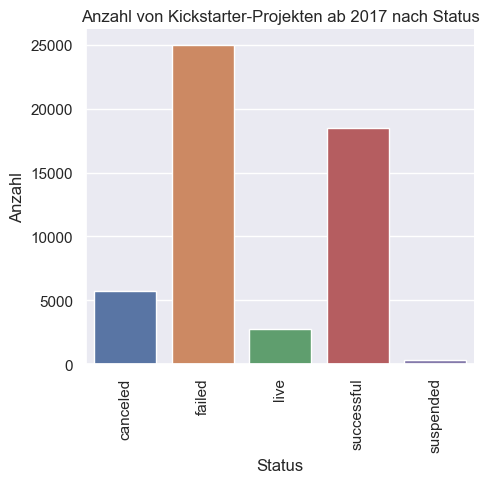

dict_keys(['AUD', 'CAD', 'CHF', 'DKK', 'EUR', 'GBP', 'HKD', 'JPY', 'MXN', 'NOK', 'NZD', 'SEK', 'SGD', 'USD'])

,currency_symbol,number
currency,,
AUD,AUD,1510
CAD,CAD,2594
CHF,CHF,275
DKK,DKK,272
EUR,EUR,5512
GBP,GBP,5873
HKD,HKD,488
JPY,JPY,40
MXN,MXN,1462


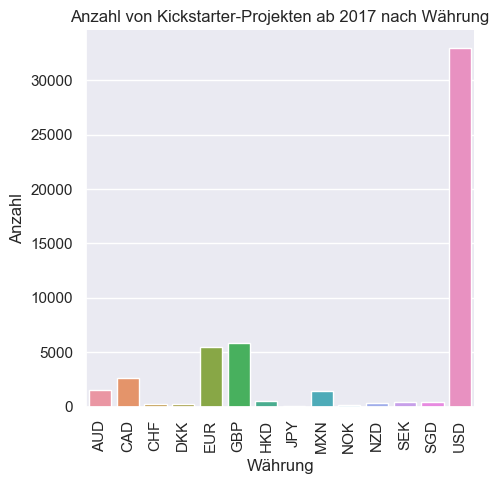

dict_keys(['AT', 'AU', 'BE', 'CA', 'CH', 'DE', 'DK', 'ES', 'FR', 'GB', 'HK', 'IE', 'IT', 'JP', 'LU', 'MX', 'NL', 'NO', 'NZ', 'SE', 'SG', 'US'])

,country_symbol,number
country,,
AT,AT,205
AU,AU,1510
BE,BE,207
CA,CA,2594
CH,CH,275
DE,DE,1400
DK,DK,272
ES,ES,841
FR,FR,980


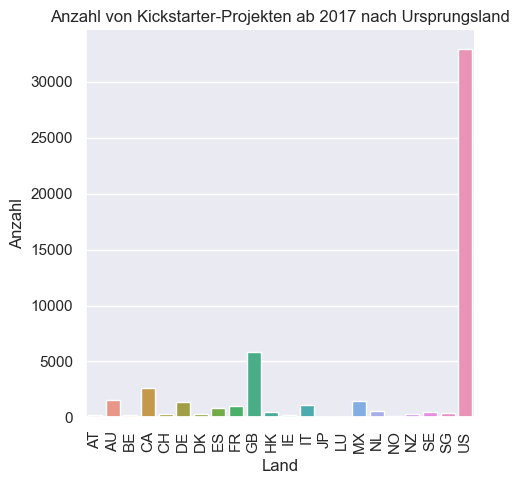

dict_keys(['Art', 'Comics', 'Crafts', 'Dance', 'Design', 'Fashion', 'Film & Video', 'Food', 'Games', 'Journalism', 'Music', 'Photography', 'Publishing', 'Technology', 'Theater'])

,main_category_desc,number
main_category,,
Art,Art,3968
Comics,Comics,2005
Crafts,Crafts,1545
Dance,Dance,370
Design,Design,5875
Fashion,Fashion,4216
Film & Video,Film & Video,5523
Food,Food,3197
Games,Games,6910


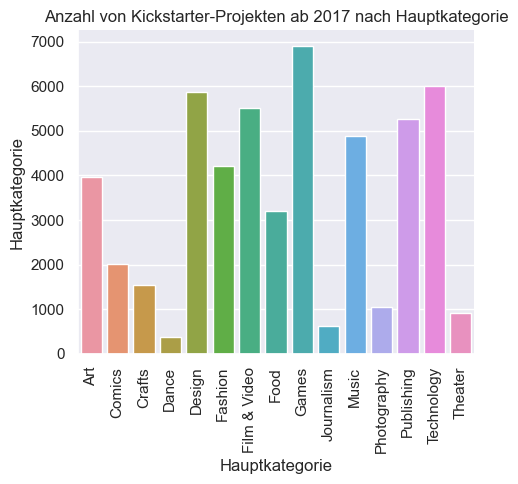

dict_keys(['3D Printing', 'Academic', 'Accessories', 'Action', 'Animals', 'Animation', 'Anthologies', 'Apparel', 'Apps', 'Architecture', 'Art', 'Art Books', 'Audio', 'Bacon', 'Blues', 'Calendars', 'Camera Equipment', 'Candles', 'Ceramics', "Children's Books", 'Childrenswear', 'Chiptune', 'Civic Design', 'Classical Music', 'Comedy', 'Comic Books', 'Comics', 'Community Gardens', 'Conceptual Art', 'Cookbooks', 'Country & Folk', 'Couture', 'Crafts', 'Crochet', 'DIY', 'DIY Electronics', 'Dance', 'Design', 'Digital Art', 'Documentary', 'Drama', 'Drinks', 'Electronic Music', 'Embroidery', 'Events', 'Experimental', 'Fabrication Tools', 'Faith', 'Family', 'Fantasy', "Farmer's Markets", 'Farms', 'Fashion', 'Festivals', 'Fiction', 'Film & Video', 'Fine Art', 'Flight', 'Food', 'Food Trucks', 'Footwear', 'Gadgets', 'Games', 'Gaming Hardware', 'Glass', 'Graphic Design', 'Graphic Novels', 'Hardware', 'Hip-Hop', 'Horror', 'Illustration', 'Immersive', 'Indie Rock', 'Installations', 'Interactive Design'

,category_desc,number
category,,
3D Printing,3D Printing,117
Academic,Academic,199
Accessories,Accessories,1079
Action,Action,120
Animals,Animals,36
...,...,...
Woodworking,Woodworking,216
Workshops,Workshops,31
World Music,World Music,238


dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

,launched_month_desc,number
launched_month,,
1,1,4575
2,2,4027
3,3,5250
4,4,4381
5,5,4804
6,6,4504
7,7,4219
8,8,4355
9,9,4100


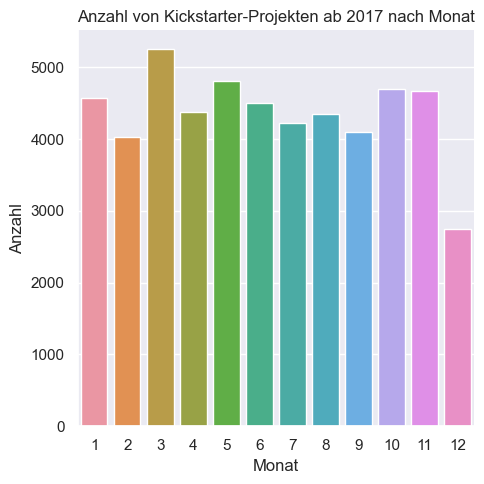

In [69]:
# Gruppieren nach Status der Einträge
keys_state = cut.groupby(["state"]).groups.keys()
display(keys_state)

# Ausgben von Status mit der Anzahl an zugehörigen Projekten
var_gb_state = cut.groupby("state").count()

var_gb_state["status"] = var_gb_state.index
var_gb_state["number"] = var_gb_state["category"]
var_gb_state = var_gb_state.loc[:, var_gb_state.columns.intersection(["status","number"])]
display(var_gb_state)

# Ausgabe als Plot
plt_gb_state = scn.catplot(data=var_gb_state, x="status", y="number", kind="bar")
plt_gb_state.set_axis_labels("Status","Anzahl")
plt_gb_state.set(title="Anzahl von Kickstarter-Projekten ab 2017 nach Status")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt_gb_state.savefig("Dist_Status")


# Gruppieren nach Währung der Einträge
keys_currency = cut.groupby(["currency"]).groups.keys()
display(keys_currency)

# Ausgeben der Währung mit der Anzahl an zugehörigen Projekten
var_gb_currency = cut.groupby("currency").count()

var_gb_currency["currency_symbol"] = var_gb_currency.index
var_gb_currency["number"] = var_gb_currency["category"]
var_gb_currency = var_gb_currency.loc[:, var_gb_currency.columns.intersection(["currency_symbol","number"])]
display(var_gb_currency)

# Ausgabe als Plot
plt_gb_currency = scn.catplot(data=var_gb_currency, x="currency_symbol", y="number", kind="bar")
plt_gb_currency.set_axis_labels("Währung","Anzahl")
plt_gb_currency.set(title="Anzahl von Kickstarter-Projekten ab 2017 nach Währung")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt_gb_currency.savefig("Dist_Currency")


# Gruppieren nach Ursprungsland der Einträge
keys_country = cut.groupby(["country"]).groups.keys()
display(keys_country)

# Ausgeben des Ursprungslands mit der Anzahl an zugehörigen Projekten
var_gb_country = cut.groupby("country").count()

var_gb_country["country_symbol"] = var_gb_country.index
var_gb_country["number"] = var_gb_country["category"]
var_gb_country = var_gb_country.loc[:, var_gb_country.columns.intersection(["country_symbol","number"])]
display(var_gb_country)

# Ausgabe als Plot
plt_gb_country = scn.catplot(data=var_gb_country, x="country_symbol", y="number", kind="bar")
plt_gb_country.set_axis_labels("Land","Anzahl")
plt_gb_country.set(title="Anzahl von Kickstarter-Projekten ab 2017 nach Ursprungsland")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt_gb_country.savefig("Dist_Country")


# Gruppieren nach Hauptkategorie der Einträge
keys_mcat = cut.groupby(["main_category"]).groups.keys()
display(keys_mcat)

# Ausgeben der Hauptkategorie mit der Anzahl an zugehörigen Projekten
var_gb_mcat = cut.groupby("main_category").count()

var_gb_mcat["main_category_desc"] = var_gb_mcat.index
var_gb_mcat["number"] = var_gb_mcat["state"]
var_gb_mcat = var_gb_mcat.loc[:, var_gb_mcat.columns.intersection(["main_category_desc","number"])]
display(var_gb_mcat)

# Ausgabe als Plot
plt_gb_mcat = scn.catplot(data=var_gb_mcat, x="main_category_desc", y="number", kind="bar")
plt_gb_mcat.set_axis_labels("Hauptkategorie","Hauptkategorie")
plt_gb_mcat.set(title="Anzahl von Kickstarter-Projekten ab 2017 nach Hauptkategorie")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt_gb_mcat.savefig("Dist_Category")


# Gruppieren nach Unterkategorie der Einträge
keys_cat = cut.groupby(["category"]).groups.keys()
display(keys_cat)

# Ausgeben der Unterkategorie mit der Anzahl an zugehörigen Projekten
var_gb_cat = cut.groupby("category").count()

var_gb_cat["category_desc"] = var_gb_cat.index
var_gb_cat["number"] = var_gb_cat["state"]
var_gb_cat = var_gb_cat.loc[:, var_gb_cat.columns.intersection(["category_desc", "number"])]
display(var_gb_cat)


# Gruppieren nach Status der Einträge
keys_lm = cut.groupby(["launched_month"]).groups.keys()
display(keys_lm)

# Ausgben des Launch-Monats mit der Anzahl an zugehörigen Projekten
var_gb_lm = cut.groupby("launched_month").count()

var_gb_lm["launched_month_desc"] = var_gb_lm.index
var_gb_lm["number"] = var_gb_lm["category"]
var_gb_lm = var_gb_lm.loc[:, var_gb_lm.columns.intersection(["launched_month_desc","number"])]
display(var_gb_lm)

#Ausgbe als Plot
plt_gb_lm = scn.catplot(data=var_gb_lm, x="launched_month_desc", y="number", kind="bar")
plt_gb_lm.set_axis_labels("Monat","Anzahl")
plt_gb_lm.set(title="Anzahl von Kickstarter-Projekten ab 2017 nach Monat")
plt.tight_layout()
plt.show()
# plt_gb_lm.savefig("Dist_Launched_Month")

# Datenmanipulation - Relevante Projekte

In [70]:
# Löschen der zum Aufnahmezeitpunkt aktiven Projekte
relevant = cut[cut.state != 'live']

# Assoziationsanalyse

In [71]:
# Daten für Assoziationsanalyse vorbereiten
var_aa_mcat = relevant[['state', 'main_category']]
var_aa_mcat['count'] = 1
var_aa_mcat = var_aa_mcat.reset_index()

pivot_state_mcat = pd.pivot(var_aa_mcat, index='index', columns=['main_category','state'], values='count').fillna(0)
haeufig_state_mcat = apriori(pivot_state_mcat, min_support=0.005, use_colnames=True)
haeufig_state_mcat.sort_values("support", ascending=False, inplace=True)
print("Support für Main Category:")
print(haeufig_state_mcat)


var_aa_cat = relevant[['state', 'category']]
var_aa_cat['count'] = 1
var_aa_cat = var_aa_cat.reset_index()

pivot_state_cat = pd.pivot(var_aa_cat, index='index', columns=['category', 'state'], values='count').fillna(0)
haeufig_state_cat = apriori(pivot_state_cat, min_support=0.005, use_colnames=True)
haeufig_state_cat.sort_values("support", ascending=False, inplace=True)
print("Support für Category:")
print(haeufig_state_cat)


var_aa_currency = relevant[['state', 'currency']]
var_aa_currency['count'] = 1
var_aa_currency = var_aa_currency.reset_index()

pivot_state_currency = pd.pivot(var_aa_currency, index='index', columns=['currency', 'state'], values='count').fillna(0)
haeufig_state_currency = apriori(pivot_state_currency, min_support=0.005, use_colnames=True)
haeufig_state_currency.sort_values("support", ascending=False, inplace=True)
print("Support für Currency:")
print(haeufig_state_currency)


var_aa_country = relevant[['state', 'country']]
var_aa_country['count'] = 1
var_aa_country = var_aa_country.reset_index()

pivot_state_country = pd.pivot(var_aa_country, index='index', columns=['country', 'state'], values='count').fillna(0)
haeufig_state_country= apriori(pivot_state_country, min_support=0.005, use_colnames=True)
haeufig_state_country.sort_values("support", ascending=False, inplace=True)
print("Support für Country:")
print(haeufig_state_country)


var_aa_lm = relevant[['state', 'launched_month']]
var_aa_lm['count'] = 1
var_aa_lm = var_aa_lm.reset_index()

pivot_state_lm = pd.pivot(var_aa_lm, index='index', columns=['launched_month', 'state'], values='count').fillna(0)
haeufig_state_lm= apriori(pivot_state_lm, min_support=0.005, use_colnames=True)
haeufig_state_lm.sort_values("support", ascending=False, inplace=True)
print("Support für Veröffentlichungsmonat:")
print(haeufig_state_lm)

C:\Users\alexa\AppData\Local\Temp\ipykernel_15248\735924142.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
c:\Users\alexa\AppData\Local\Programs\Python\Python39\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:111: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type


Support für Main Category:
     support                      itemsets
9   0.071214        ((Technology, failed))
6   0.057968         ((Games, successful))
17  0.055283      ((Film & Video, failed))
4   0.054617        ((Publishing, failed))
15  0.051891             ((Games, failed))
11  0.047146            ((Design, failed))
8   0.046823           ((Fashion, failed))
29  0.045652        ((Design, successful))
12  0.043370             ((Music, failed))
2   0.042623         ((Music, successful))
31  0.040745              ((Food, failed))
3   0.038444  ((Film & Video, successful))
7   0.036364    ((Publishing, successful))
5   0.035476               ((Art, failed))
10  0.033981           ((Art, successful))
0   0.025037        ((Comics, successful))
22  0.023462    ((Technology, successful))
19  0.023240       ((Fashion, successful))
28  0.023058           ((Games, canceled))
14  0.018717          ((Design, canceled))
13  0.018313            ((Crafts, failed))
25  0.016960      ((Technol

C:\Users\alexa\AppData\Local\Temp\ipykernel_15248\735924142.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
c:\Users\alexa\AppData\Local\Programs\Python\Python39\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:111: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type


Support für Category:
     support                          itemsets
3   0.039958    ((Tabletop Games, successful))
7   0.036021        ((Product Design, failed))
29  0.035940    ((Product Design, successful))
16  0.020837                  ((Apps, failed))
37  0.019404               ((Apparel, failed))
11  0.018980           ((Video Games, failed))
15  0.015325             ((Music, successful))
19  0.015083                 ((Music, failed))
9   0.015062      ((Product Design, canceled))
10  0.013952        ((Tabletop Games, failed))
25  0.012619                   ((Web, failed))
12  0.012135           ((Documentary, failed))
5   0.012115            ((Technology, failed))
33  0.011933                  ((Food, failed))
24  0.011610                   ((Art, failed))
27  0.011368      ((Tabletop Games, canceled))
0   0.011105       ((Comic Books, successful))
6   0.011065               ((Art, successful))
23  0.010419               ((Fiction, failed))
22  0.010217      ((Children's Books, 

C:\Users\alexa\AppData\Local\Temp\ipykernel_15248\735924142.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
c:\Users\alexa\AppData\Local\Programs\Python\Python39\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:111: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
C:\Users\alexa\AppData\Local\Temp\ipykernel_15248\735924142.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versu

Support für Country:
     support            itemsets
2   0.315222      ((US, failed))
0   0.241969  ((US, successful))
1   0.069195    ((US, canceled))
6   0.050578      ((GB, failed))
5   0.049730  ((GB, successful))
8   0.023684      ((CA, failed))
4   0.018939  ((CA, successful))
15  0.016940      ((MX, failed))
7   0.015587      ((DE, failed))
13  0.015143      ((AU, failed))
9   0.012942      ((IT, failed))
18  0.012014    ((GB, canceled))
3   0.009752  ((AU, successful))
12  0.009611      ((FR, failed))
14  0.008924      ((ES, failed))
10  0.007168  ((DE, successful))
17  0.006986  ((FR, successful))
16  0.006784    ((CA, canceled))
11  0.006502  ((MX, successful))
19  0.005613      ((NL, failed))


C:\Users\alexa\AppData\Local\Temp\ipykernel_15248\735924142.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
c:\Users\alexa\AppData\Local\Programs\Python\Python39\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:111: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type


Support für Veröffentlichungsmonat:
     support            itemsets
6   0.052981       ((3, failed))
12  0.051507       ((5, failed))
16  0.047752       ((6, failed))
2   0.046157       ((1, failed))
28  0.045753      ((10, failed))
21  0.044784       ((8, failed))
9   0.044703       ((4, failed))
18  0.044117       ((7, failed))
3   0.042098       ((2, failed))
7   0.041331   ((3, successful))
25  0.040463       ((9, failed))
30  0.039211      ((11, failed))
29  0.037151  ((10, successful))
13  0.035334   ((5, successful))
10  0.033032   ((4, successful))
31  0.032851  ((11, successful))
15  0.032750   ((6, successful))
0   0.032508   ((1, successful))
22  0.032306   ((8, successful))
24  0.031983   ((9, successful))
20  0.030024   ((7, successful))
4   0.029943   ((2, successful))
27  0.011327    ((10, canceled))
8   0.011004     ((3, canceled))
32  0.010762    ((11, canceled))
1   0.010661     ((1, canceled))
19  0.010277     ((7, canceled))
11  0.010257     ((4, canceled))
23  0.0

# Datenmanipulation - Modellvorbereitung

In [72]:
# Vorbereitung der Daten für Modellgenerierung
analysis = relevant
# Löschen von Einträgen mit State = Canceled oder Suspended
analysis = analysis[analysis.state != "canceled"]
analysis = analysis[analysis.state != "suspended"]
# Umwandeln von nicht stetigen Werten in Integer um sie in Analysen besser verwenden zu können
analysis.state = analysis.state.replace({"successful": 1, "failed": 0})
country_enc = LabelEncoder().fit(analysis["country"])
main_category_enc = LabelEncoder().fit(analysis["main_category"])
category_enc = LabelEncoder().fit(analysis["category"])
currency_enc = LabelEncoder().fit(analysis["currency"])
analysis["country"] = country_enc.transform(analysis["country"])
analysis["main_category"] = main_category_enc.transform(analysis["main_category"])
analysis["category"] = category_enc.transform(analysis["category"])
analysis["currency"] = currency_enc.transform(analysis["currency"])
analysis = analysis.drop(["launched", "deadline"], axis=1)
analysis.info()
print(analysis)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 43419 entries, 168349 to 339929
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   category          43419 non-null  int32  
 1   main_category     43419 non-null  int32  
 2   currency          43419 non-null  int32  
 3   state             43419 non-null  int64  
 4   backers           43419 non-null  int64  
 5   country           43419 non-null  int32  
 6   usd_pledged_real  43419 non-null  float64
 7   usd_goal_real     43419 non-null  float64
 8   launched_year     43419 non-null  int64  
 9   launched_month    43419 non-null  int64  
 10  launched_day      43419 non-null  int64  
 11  deadline_year     43419 non-null  int64  
 12  deadline_month    43419 non-null  int64  
 13  deadline_day      43419 non-null  int64  
 14  duration          43419 non-null  int64  
dtypes: float64(2), int32(4), int64(9)
memory usage: 4.6 MB
        category  main_cat

# Korrelationsmatrix und Pairplot

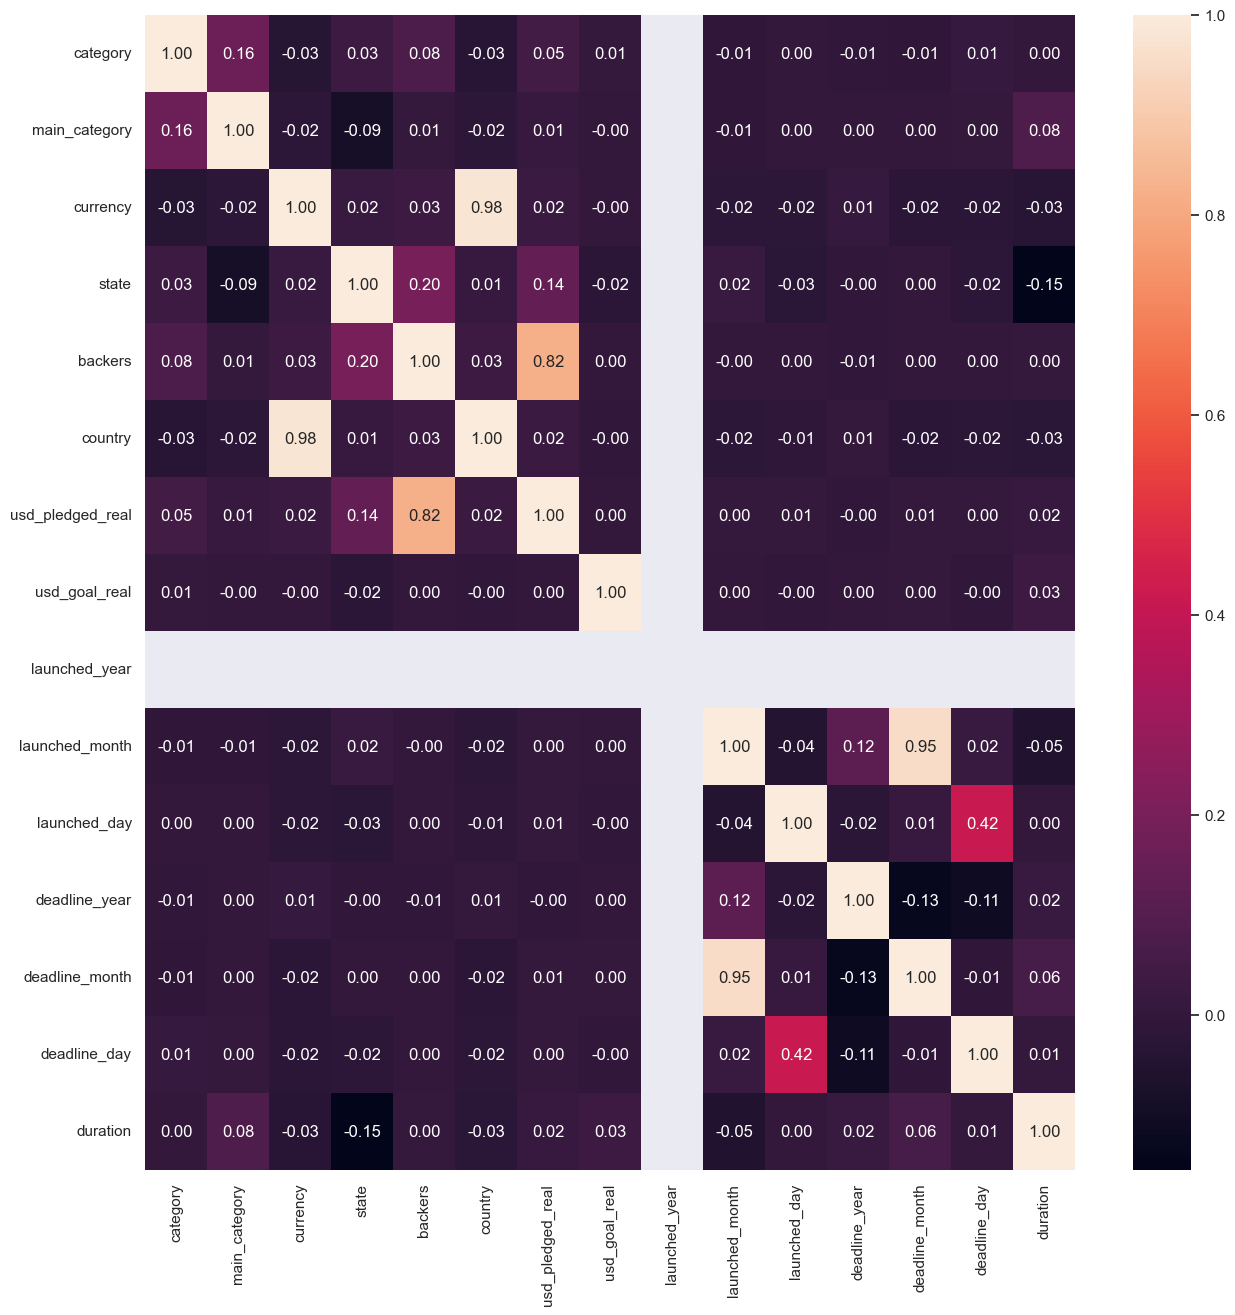

In [73]:
# Korrelationsmatrix erzeugen
rcParams["figure.figsize"] = 15,15
plt_heatmap = scn.heatmap( analysis.corr(), annot=True, fmt = ".2f")
fig_heatmap = plt_heatmap.get_figure()
fig_heatmap.savefig("CorelationMatrix")

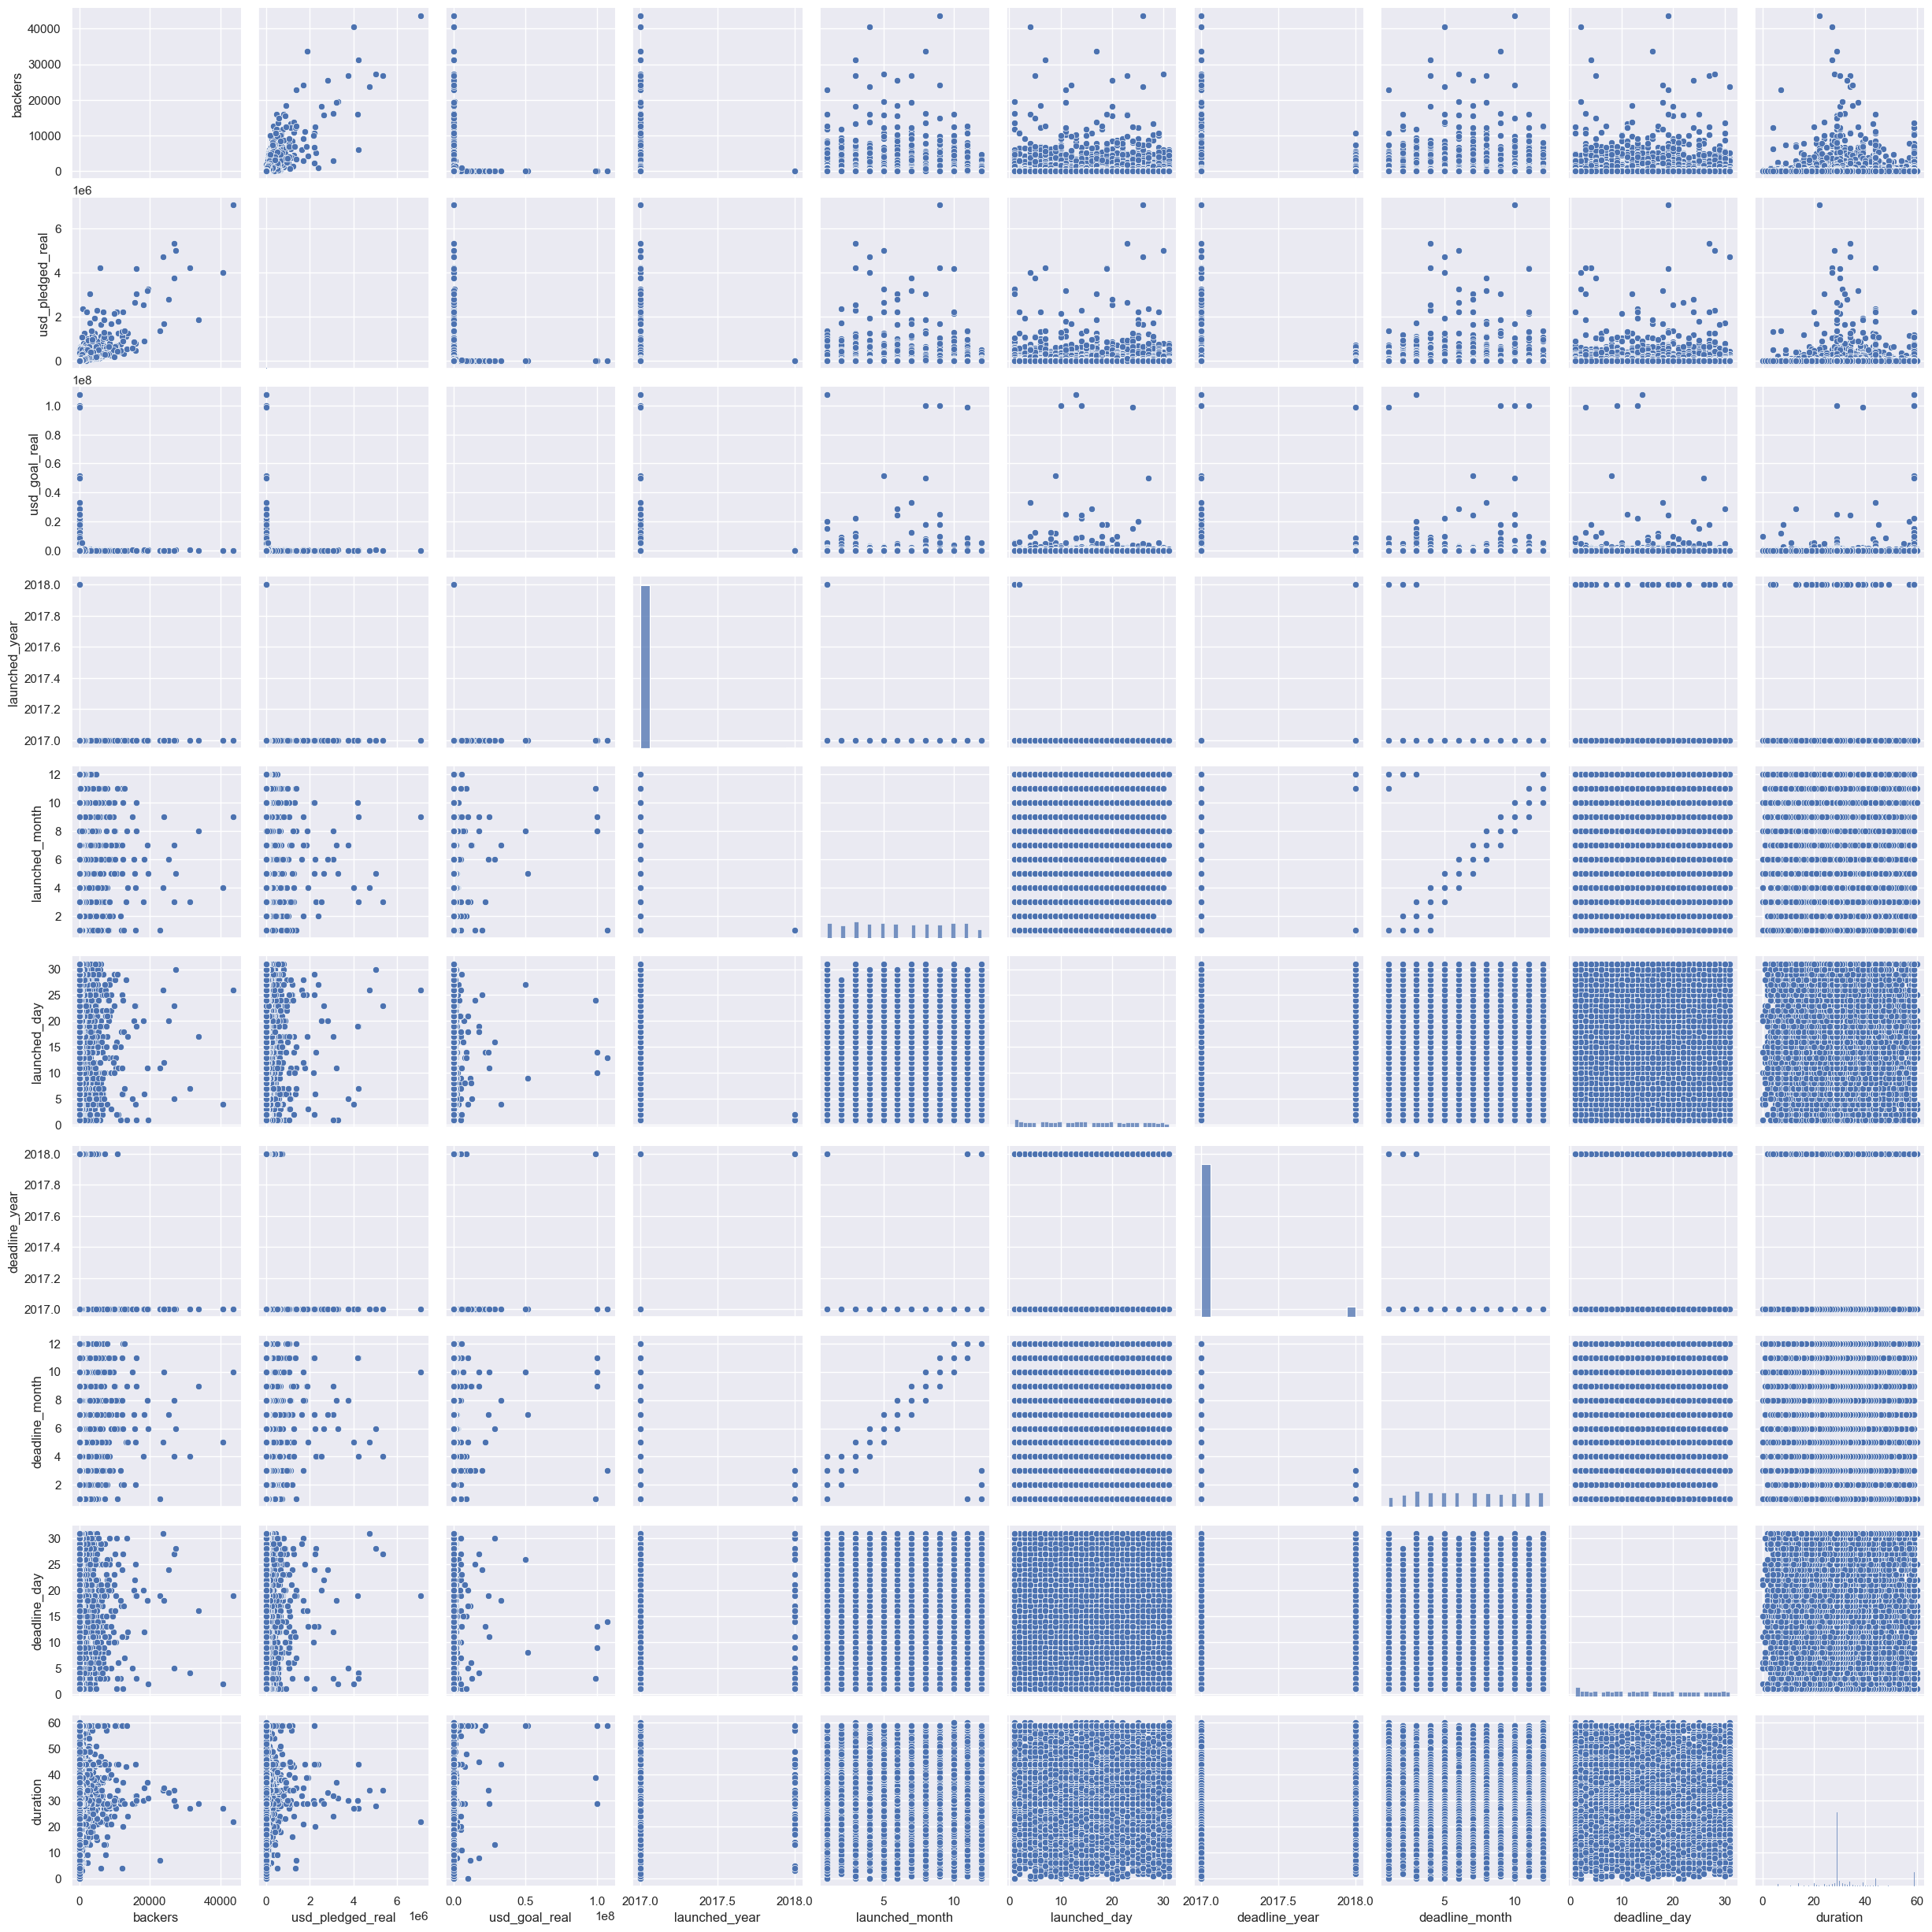

In [74]:
# Pairplot erzeugen und speichern
plt_pp = scn.pairplot(cut)
plt_pp.savefig("GeneralPairplot")

# Datenmanipulation - Modellvorbereitung 2

In [75]:
# Verkleinerung des Datensatzes
analysis = analysis.drop(["currency", "deadline_month"], axis=1)

# Train/Test-Split Vorbereitung
X = analysis.drop("state", axis=1)
y = analysis["state"]

# Train/Test-Split 80:20 (Mittelwert der drei Optionen)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X,y, test_size=0.2, random_state=0)
# Train/Test-Split 70:30 
X_train2, X_test2, y_train2, y_test2 = train_test_split(X,y, test_size=0.3, random_state=0)
# Train/Test-Split 90:10
X_train3, X_test3,y_train3, y_test3 = train_test_split(X,y, test_size=0.1, random_state=0)

# Verkleinerung des Datensatzes
analysis2 = analysis
analysis2 = analysis2.drop(["backers", "usd_pledged_real"], axis=1)

# Train/Test-Split Vorbereitung
X2 = analysis2.drop("state", axis=1)
y2 = analysis2["state"]

# Train/Test-Split 80:20 (Mittelwert der drei Optionen)
X_train4, X_test4, y_train4, y_test4 = train_test_split(X2,y2, test_size=0.2, random_state=0)
# Train/Test-Split 70:30 
X_train5, X_test5, y_train5, y_test5 = train_test_split(X2,y2, test_size=0.3, random_state=0)
# Train/Test-Split 90:10
X_train6, X_test6, y_train6, y_test6 = train_test_split(X2,y2, test_size=0.1, random_state=0)

# MinMaxScaler kreieren und Daten transformieren
scaler = MinMaxScaler()
X_train1_MSc = scaler.fit_transform(X_train1)
X_test1_MSc = scaler.transform(X_test1)
X_train2_MSc = scaler.fit_transform(X_train2)
X_test2_MSc = scaler.transform(X_test2)
X_train3_MSc = scaler.fit_transform(X_train3)
X_test3_MSc = scaler.transform(X_test3)
X_train4_MSc = scaler.fit_transform(X_train4)
X_test4_MSc = scaler.transform(X_test4)
X_train5_MSc = scaler.fit_transform(X_train5)
X_test5_MSc = scaler.transform(X_test5)
X_train6_MSc = scaler.fit_transform(X_train6)
X_test6_MSc = scaler.transform(X_test6)

# StandardScaler kreieren und Daten transformieren
scaler = StandardScaler()
X_train1_SSc = scaler.fit_transform(X_train1)
X_test1_SSc = scaler.transform(X_test1)
X_train2_SSc = scaler.fit_transform(X_train2)
X_test2_SSc = scaler.transform(X_test2)
X_train3_SSc = scaler.fit_transform(X_train3)
X_test3_SSc = scaler.transform(X_test3)
X_train4_SSc = scaler.fit_transform(X_train4)
X_test4_SSc = scaler.transform(X_test4)
X_train5_SSc = scaler.fit_transform(X_train5)
X_test5_SSc = scaler.transform(X_test5)
X_train6_SSc = scaler.fit_transform(X_train6)
X_test6_SSc = scaler.transform(X_test6)

In [76]:
# DataFrames zur Sammlung der besten Modelle für die finale Analyse
max_acc= pd.DataFrame(columns=["modell_name", "category", "accuracy"])
max_acc_red= pd.DataFrame(columns=["modell_name", "category", "accuracy"])

# Decision Tree (DT)

In [77]:
# DataFrames zur Sammlung der besten Baummodelle für eine Zwischenanalyse
max_trees= pd.DataFrame(columns=["modell_cat", "ratio", "depth", "leaf", "accuracy", "train_accuracy"])
max_trees_red= pd.DataFrame(columns=["modell_cat", "ratio", "depth", "leaf", "accuracy", "train_accuracy"])

# DT - Simpel

Ausgabe: Max_Depth: 3; Min_Samples_Leaf: 2; Verhältnis: 80:20
Genauigkeit der Trainingswerte:  0.9121347344177343
Genauigkeit der Testwerte:  0.9100644864117918


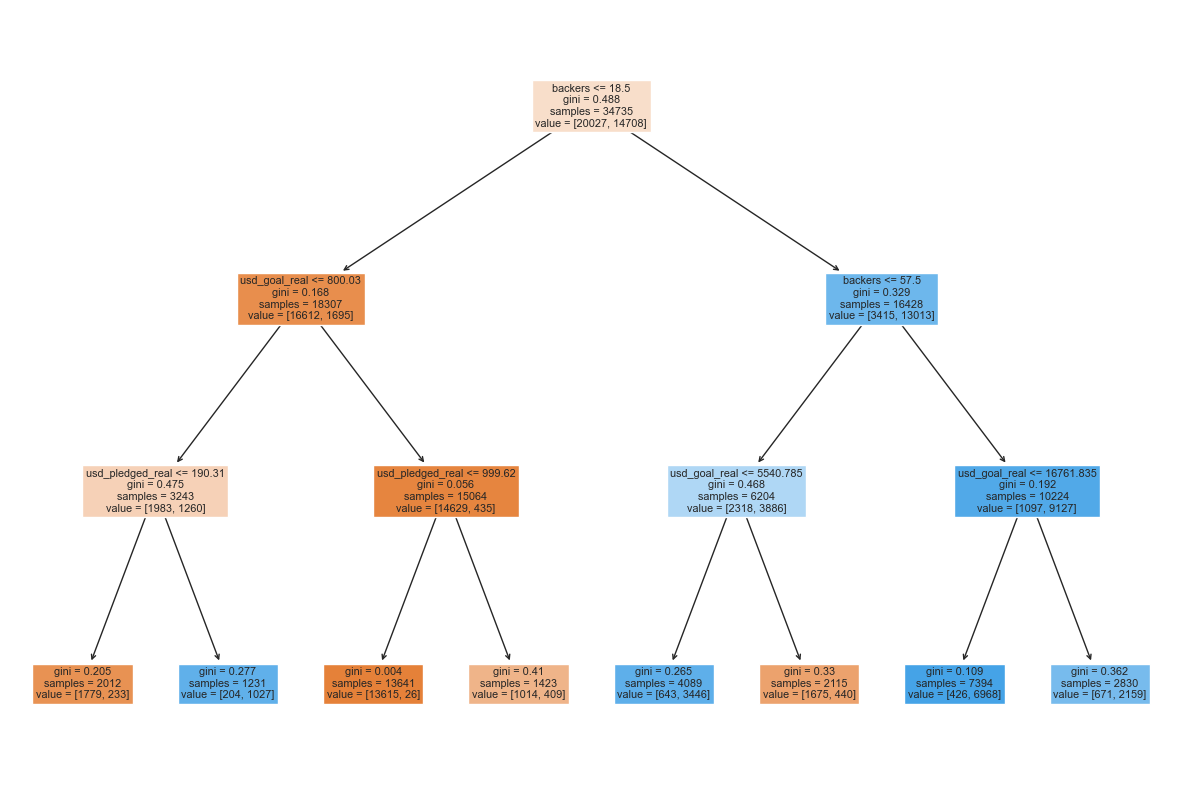

In [78]:
# Erstellung einer Liste mit Feature-Namen zur Verwendung in Entscheidungsbaumausgaben
tree_top = X.columns.values.tolist()
# Erstellung einer Liste mit Feature-Namen zur Verwendung in Entscheidungsbaumausgaben (reduziert)
tree_top_red = X2.columns.values.tolist()
# Modellerstellung Entscheidungsbaum
tree_model = DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 2)
tree_model.fit(X_train1, y_train1)
# Vorhersagen für Test- und Trainingswert
y_pred = tree_model.predict(X_test1)
y_train_pred = tree_model.predict(X_train1)

# Ausgabe der Genauigkeitswerte
print("Ausgabe: Max_Depth: 3; Min_Samples_Leaf: 2; Verhältnis: 80:20")
print("Genauigkeit der Trainingswerte: ", accuracy_score(y_train1, y_train_pred))
print("Genauigkeit der Testwerte: ", accuracy_score(y_test1, y_pred))

# Grafische Ausgabe
fig_tree = plt.figure(figsize=(15,10))
_=tree.plot_tree(tree_model, feature_names=tree_top ,filled=True)

fig_tree.savefig("Tree_Simple")

# DT - Simpel - Reduziert

Ausgabe: Max_Depth: 3; Min_Samples_Leaf: 2; Verhältnis: 80:20
Genauigkeit der Trainingswerte:  0.6074564560241831
Genauigkeit der Testwerte:  0.5992630124366651


C:\Users\alexa\AppData\Local\Temp\ipykernel_15248\2402275595.py:14: DeprecationWarning: dtreeviz() function is deprecated starting from version 2.0. 
 For the same functionality, please use this code instead: 
 m = dtreeviz.model(...) 
 m.view()
c:\Users\alexa\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


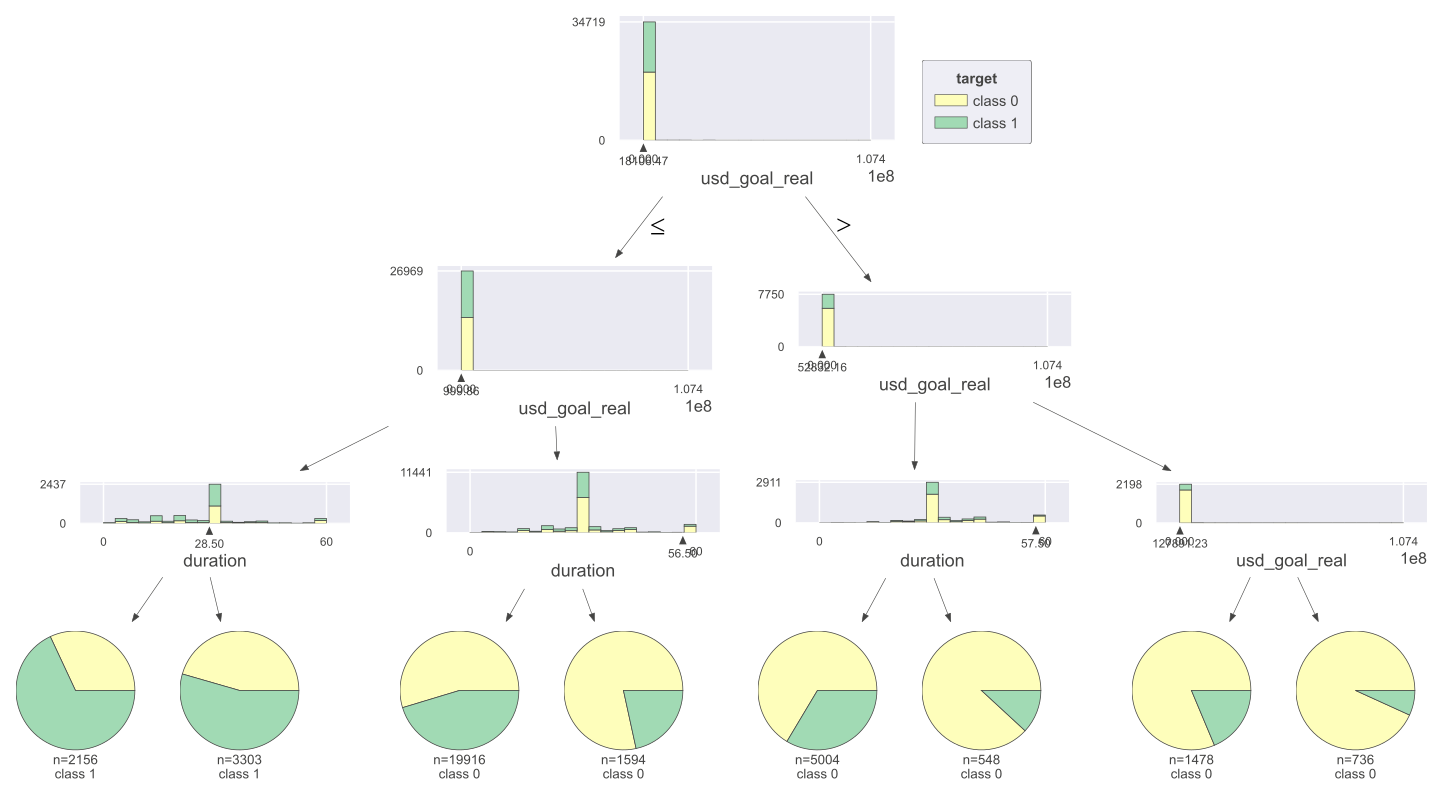

In [79]:
# Modellerstellung Entscheidungsbaum
tree_model = DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 2)
tree_model.fit(X_train4, y_train4)
# Vorhersagen für Test- und Trainingswert
y_pred = tree_model.predict(X_test4)
y_train_pred = tree_model.predict(X_train4)

# Ausgabe der Genauigkeitswerte
print("Ausgabe: Max_Depth: 3; Min_Samples_Leaf: 2; Verhältnis: 80:20")
print("Genauigkeit der Trainingswerte: ", accuracy_score(y_train4, y_train_pred))
print("Genauigkeit der Testwerte: ", accuracy_score(y_test4, y_pred))

# Grafische Ausgabe 
viz = dtreeviz(tree_model, X_train4, y_train4, target_name="target", feature_names = tree_top_red, scale=2)
viz


# DT - Iterativ

In [80]:
# Funktion um den Eintrag mit maximaler Test-Genauigkeit aus einem DataFrame (für Entscheidungsbäume) zu gewinnen
def get_max_acc_frame(frame, mode, ratio):
    erg = pd.DataFrame(columns=["modell_cat", "ratio", "depth", "leaf", "accuracy", "train_accuracy"])
    temp = frame
    temp["accuracy"] = pd.to_numeric(temp["accuracy"])
    temp_red = temp.loc[temp["category"] == "test"]
    max_acc_id = temp_red["accuracy"].idxmax() -1
    max_acc_id_train = max_acc_id - 1
    erg.loc[1] =  pd.Series({"modell_cat": mode, "ratio": ratio, "depth": temp.iloc[max_acc_id]["depth"], "leaf": temp.iloc[max_acc_id]["leaf"], "accuracy": temp.iloc[max_acc_id]["accuracy"], "train_accuracy": temp.iloc[max_acc_id_train]["accuracy"]})
    return erg

'8020'

,category,depth,leaf,accuracy
1,training,1,1,0.852886
2,test,1,1,0.854675
3,training,1,2,0.852886
4,test,1,2,0.854675
5,training,1,3,0.852886
...,...,...,...,...
96,test,10,3,0.994703
97,training,10,4,0.998186
98,test,10,4,0.993782
99,training,10,5,0.997870


'7030'

,category,depth,leaf,accuracy
1,training,1,1,0.852795
2,test,1,1,0.854291
3,training,1,2,0.852795
4,test,1,2,0.854291
5,training,1,3,0.852795
...,...,...,...,...
96,test,10,3,0.993782
97,training,10,4,0.997697
98,test,10,4,0.994166
99,training,10,5,0.997170


'9010'

,category,depth,leaf,accuracy
1,training,1,1,0.853059
2,test,1,1,0.854906
3,training,1,2,0.853059
4,test,1,2,0.854906
5,training,1,3,0.853059
...,...,...,...,...
96,test,10,3,0.995854
97,training,10,4,0.997799
98,test,10,4,0.993782
99,training,10,5,0.997620


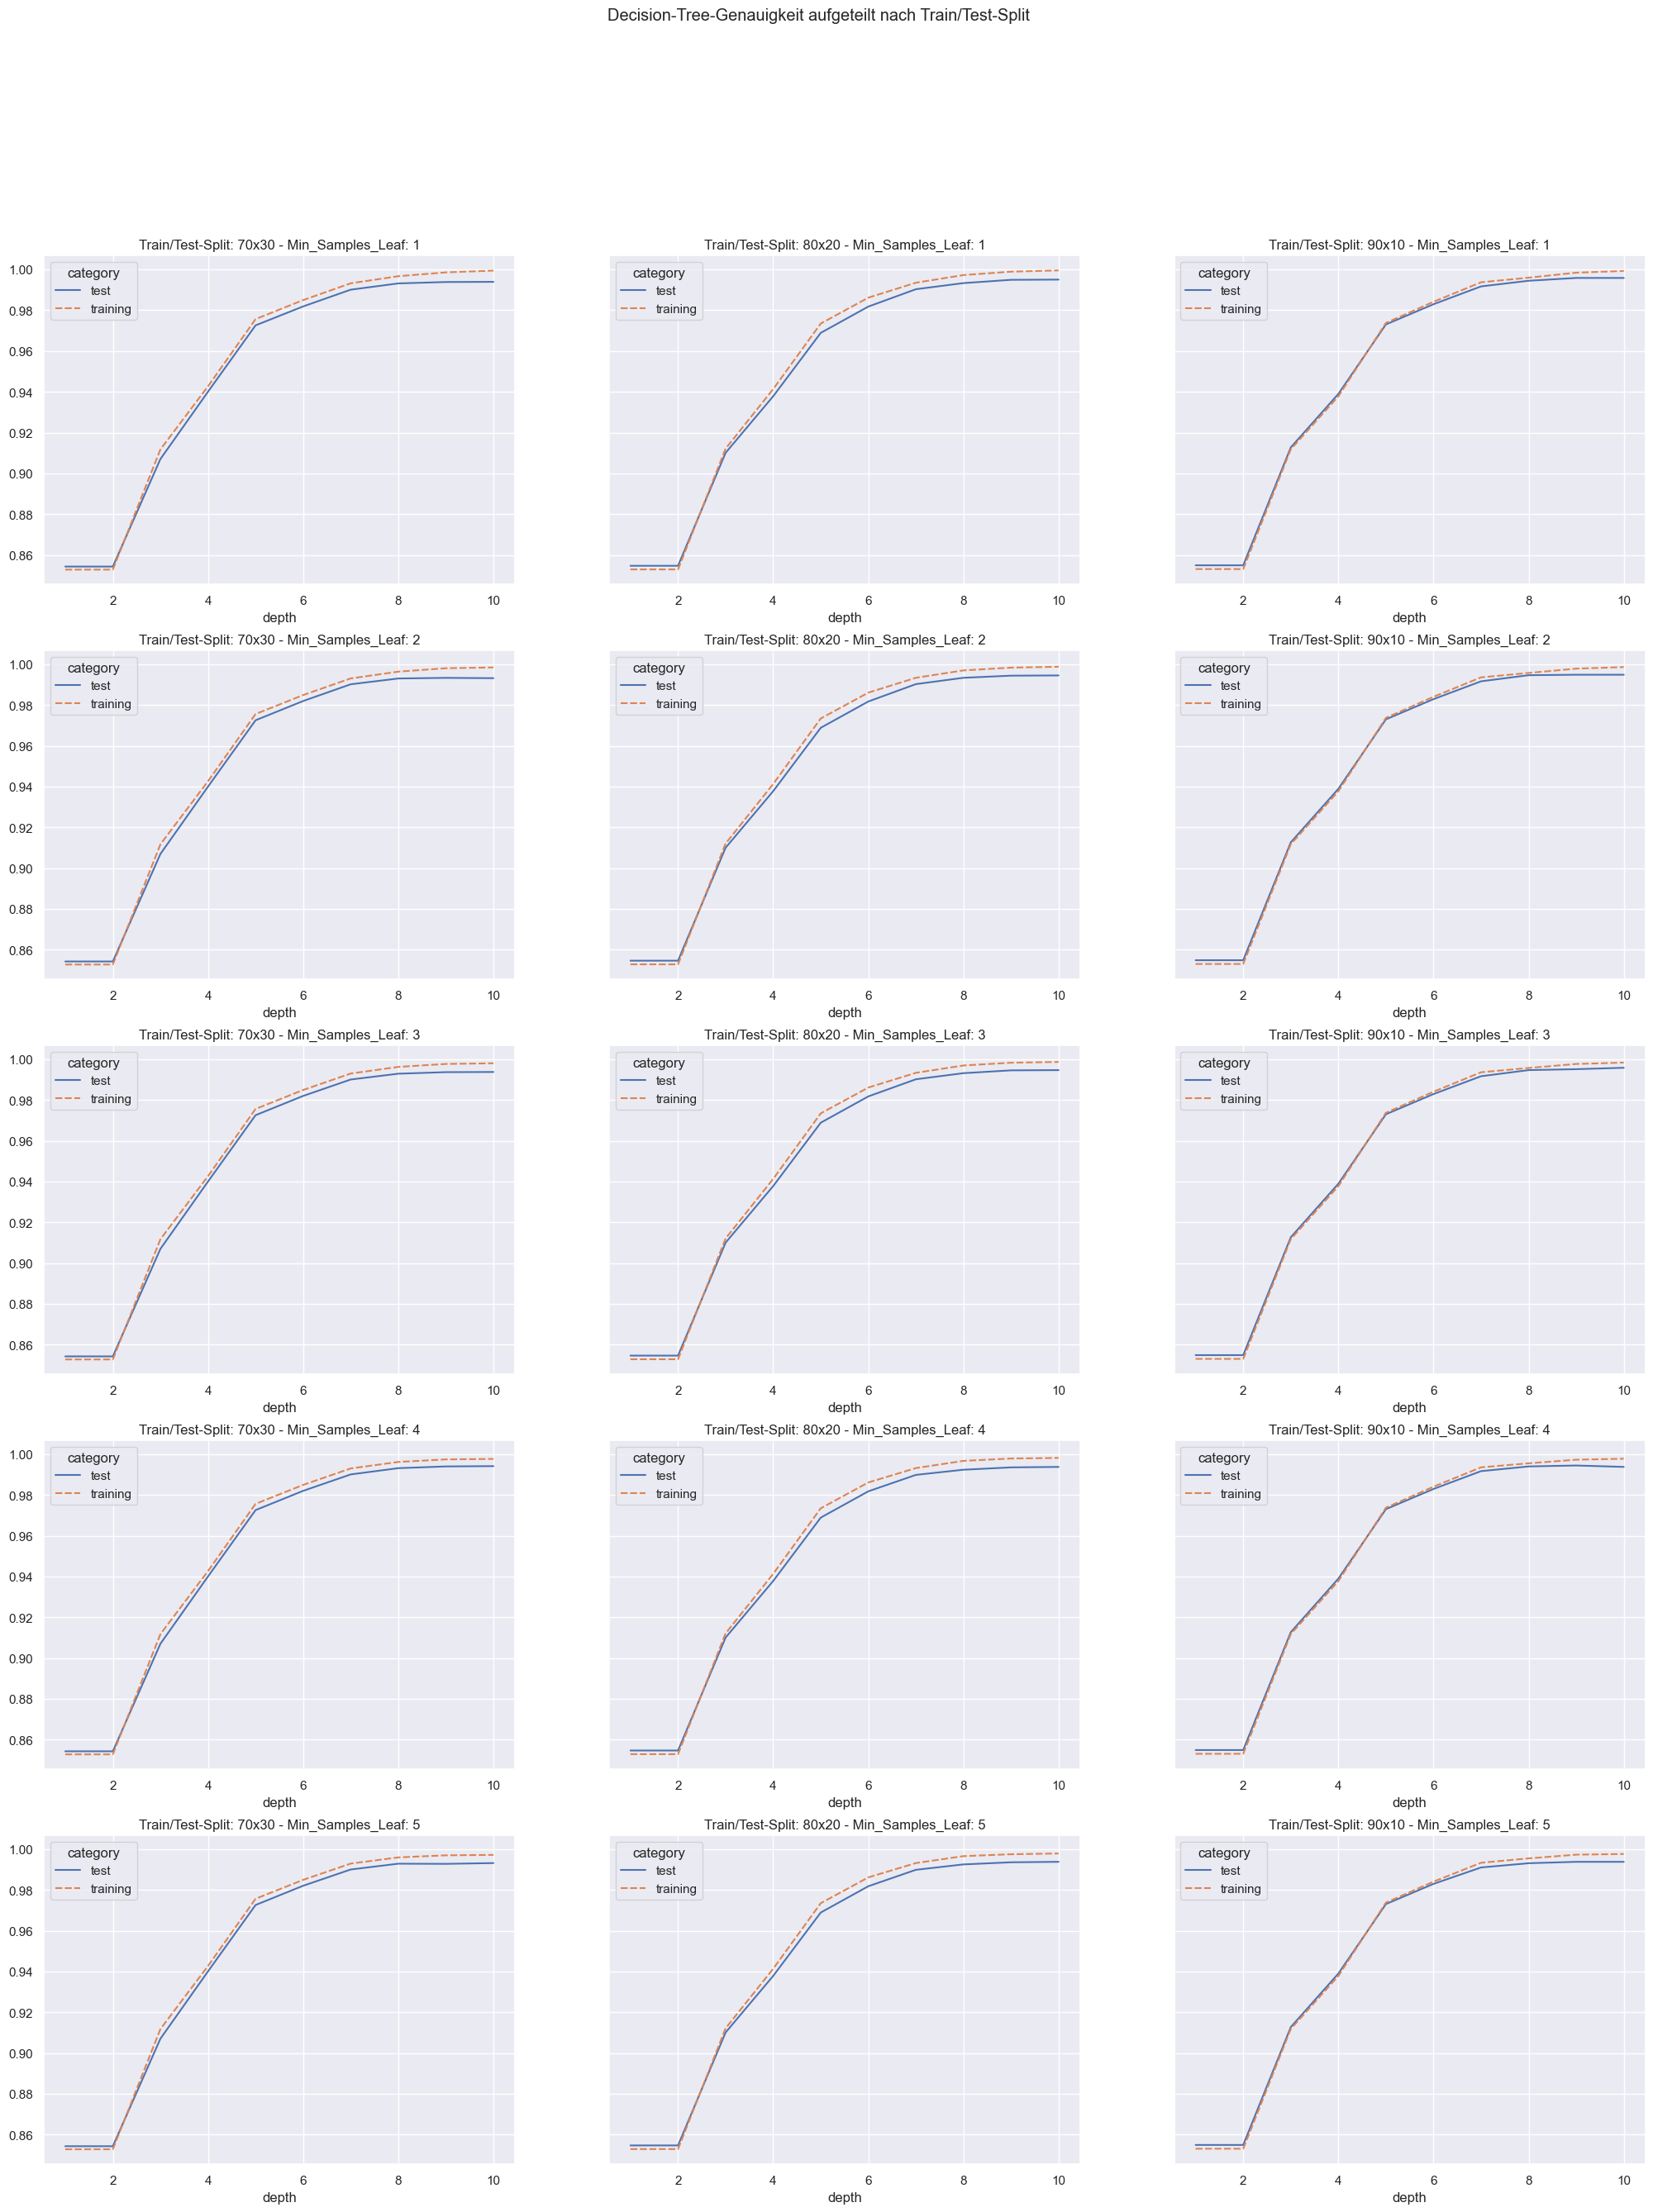

In [81]:
# Iterieren durch Entscheidungsbäume mit Max-Depth = 1-10, Min_Samples_Leaf = 1-5 und verschiedene Train/Test-Splits

fig_trees, axes_trees = plt.subplots(5,3,figsize=(25,30), sharey=True)
fig_trees.suptitle("Decision-Tree-Genauigkeit aufgeteilt nach Train/Test-Split")


treeframe_8020 = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train1, y_train1)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test1)
        y_train_pred = tree_model.predict(X_train1)
    
        # Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_8020.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train1, y_train_pred)})
        counter = counter + 1
        treeframe_8020.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test1, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_8020.depth.unique()
treeframes_dict_8020 = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_8020.keys():
    treeframes_dict_8020[key] = treeframe_8020[:][treeframe_8020.leaf == key]

# Grafische Ausgabe
treeframe_8020_1 = treeframes_dict_8020[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[0][1], data=treeframe_8020_1)
axes_trees[0][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 1")

treeframe_8020_2 = treeframes_dict_8020[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[1][1], data=treeframe_8020_2)
axes_trees[1][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 2")

treeframe_8020_3 = treeframes_dict_8020[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[2][1], data=treeframe_8020_3)
axes_trees[2][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 3")

treeframe_8020_4 = treeframes_dict_8020[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[3][1], data=treeframe_8020_4)
axes_trees[3][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 4")

treeframe_8020_5 = treeframes_dict_8020[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[4][1], data=treeframe_8020_5)
axes_trees[4][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 5")


treeframe_7030 = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train2, y_train2)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test2)
        y_train_pred = tree_model.predict(X_train2)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_7030.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train2, y_train_pred)})
        counter = counter + 1
        treeframe_7030.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test2, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_7030.depth.unique()
treeframes_dict_7030 = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_7030.keys():
    treeframes_dict_7030[key] = treeframe_7030[:][treeframe_7030.leaf == key]

# Grafische Ausgabe
treeframe_7030_1 = treeframes_dict_7030[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[0][0], data=treeframe_7030_1)
axes_trees[0][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 1")

treeframe_7030_2 = treeframes_dict_7030[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[1][0], data=treeframe_7030_2)
axes_trees[1][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 2")

treeframe_7030_3 = treeframes_dict_7030[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[2][0], data=treeframe_7030_3)
axes_trees[2][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 3")

treeframe_7030_4 = treeframes_dict_7030[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[3][0], data=treeframe_7030_4)
axes_trees[3][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 4")

treeframe_7030_5 = treeframes_dict_7030[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[4][0], data=treeframe_7030_5)
axes_trees[4][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 5")


treeframe_9010 = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train3, y_train3)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test3)
        y_train_pred = tree_model.predict(X_train3)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_9010.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train3, y_train_pred)})
        counter = counter + 1
        treeframe_9010.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test3, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_9010.depth.unique()
treeframes_dict_9010 = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_9010.keys():
    treeframes_dict_9010[key] = treeframe_9010[:][treeframe_9010.leaf == key]

# Grafische Ausgabe
treeframe_9010_1 = treeframes_dict_9010[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[0][2], data=treeframe_9010_1)
axes_trees[0][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 1")

treeframe_9010_2 = treeframes_dict_9010[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[1][2], data=treeframe_9010_2)
axes_trees[1][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 2")

treeframe_9010_3 = treeframes_dict_9010[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[2][2], data=treeframe_9010_3)
axes_trees[2][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 3")

treeframe_9010_4 = treeframes_dict_9010[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees[3][2], data=treeframe_9010_4)
axes_trees[3][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 4")

treeframe_9010_5 = treeframes_dict_9010[5].pivot("depth", "category", "accuracy")
plt_tree_acc = scn.lineplot(ax = axes_trees[4][2], data=treeframe_9010_5)
axes_trees[4][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 5")

fig_tree_acc = plt_tree_acc.get_figure()
fig_tree_acc.savefig("Tree_Acc")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_treeframe_8020 = get_max_acc_frame(treeframe_8020, "Standard", "8020")
max_treeframe_7030 = get_max_acc_frame(treeframe_7030, "Standard", "7030")
max_treeframe_9010 = get_max_acc_frame(treeframe_9010, "Standard", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_treeframe_7030, max_treeframe_8020, max_treeframe_9010])
max_trees = pd.concat([max_trees, temp])

display("8020")
display(treeframe_8020)
display("7030")
display(treeframe_7030)
display("9010")
display(treeframe_9010)

# DT - Iterativ - StandardScaler

'StandardScaler - 8020'

,category,depth,leaf,accuracy
1,training,1,1,0.852886
2,test,1,1,0.854675
3,training,1,2,0.852886
4,test,1,2,0.854675
5,training,1,3,0.852886
...,...,...,...,...
96,test,10,3,0.994703
97,training,10,4,0.998186
98,test,10,4,0.993782
99,training,10,5,0.997870


'StandardScaler - 7030'

,category,depth,leaf,accuracy
1,training,1,1,0.852795
2,test,1,1,0.854291
3,training,1,2,0.852795
4,test,1,2,0.854291
5,training,1,3,0.852795
...,...,...,...,...
96,test,10,3,0.993858
97,training,10,4,0.997697
98,test,10,4,0.994012
99,training,10,5,0.997170


'StandardScaler - 9010'

,category,depth,leaf,accuracy
1,training,1,1,0.853059
2,test,1,1,0.854906
3,training,1,2,0.853059
4,test,1,2,0.854906
5,training,1,3,0.853059
...,...,...,...,...
96,test,10,3,0.995854
97,training,10,4,0.997774
98,test,10,4,0.994703
99,training,10,5,0.997594


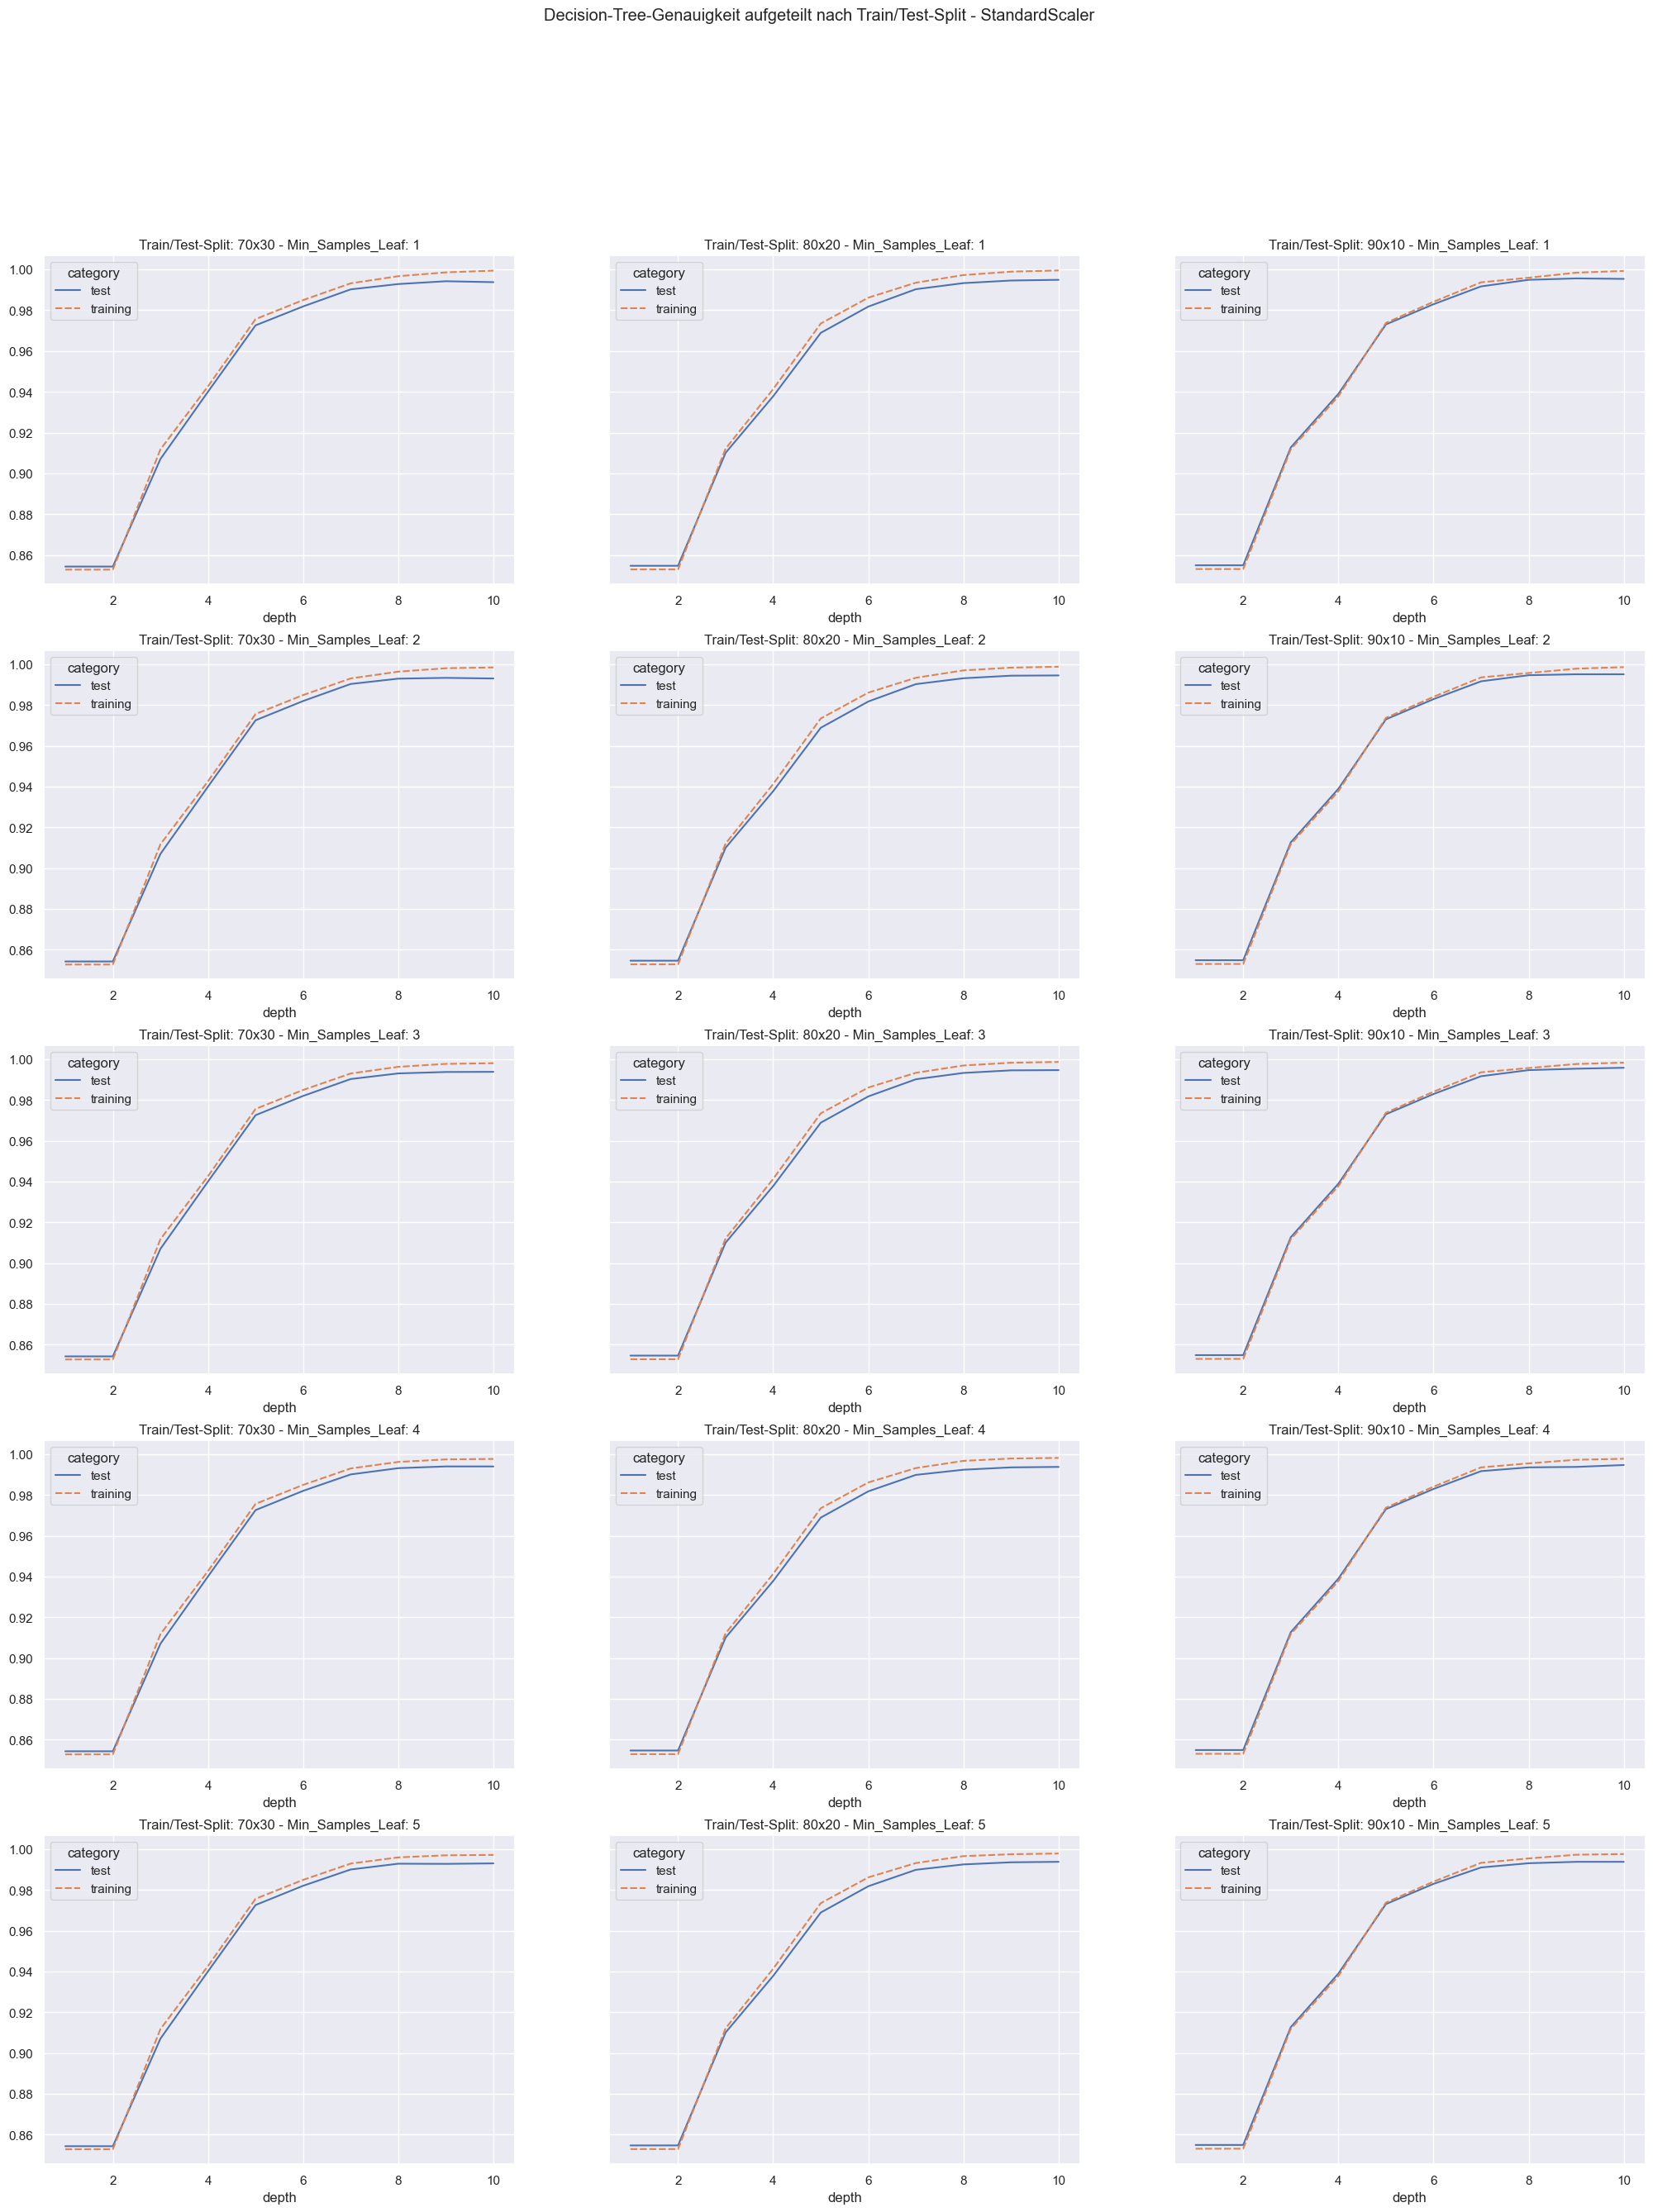

In [82]:
# Iterieren durch Entscheidungsbäume mit Max-Depth = 1-10, Min_Samples_Leaf = 1-5 und verschiedene Train/Test-Splits mit StandardScaler

fig_trees_ssc, axes_trees_ssc = plt.subplots(5,3,figsize=(25,30), sharey=True)
fig_trees_ssc.suptitle("Decision-Tree-Genauigkeit aufgeteilt nach Train/Test-Split - StandardScaler")


treeframe_8020_ssc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train1_SSc, y_train1)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test1_SSc)
        y_train_pred = tree_model.predict(X_train1_SSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_8020_ssc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train1, y_train_pred)})
        counter = counter + 1
        treeframe_8020_ssc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test1, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_8020_ssc.depth.unique()
treeframes_dict_8020_ssc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_8020_ssc.keys():
    treeframes_dict_8020_ssc[key] = treeframe_8020_ssc[:][treeframe_8020_ssc.leaf == key]

# Grafische Ausgabe
treeframe_8020_ssc_1 = treeframes_dict_8020_ssc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[0][1], data=treeframe_8020_ssc_1)
axes_trees_ssc[0][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 1")

treeframe_8020_ssc_2 = treeframes_dict_8020_ssc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[1][1], data=treeframe_8020_ssc_2)
axes_trees_ssc[1][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 2")

treeframe_8020_ssc_3 = treeframes_dict_8020_ssc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[2][1], data=treeframe_8020_ssc_3)
axes_trees_ssc[2][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 3")

treeframe_8020_ssc_4 = treeframes_dict_8020_ssc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[3][1], data=treeframe_8020_ssc_4)
axes_trees_ssc[3][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 4")

treeframe_8020_ssc_5 = treeframes_dict_8020_ssc[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[4][1], data=treeframe_8020_ssc_5)
axes_trees_ssc[4][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 5")


treeframe_7030_ssc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train2_SSc, y_train2)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test2_SSc)
        y_train_pred = tree_model.predict(X_train2_SSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_7030_ssc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train2, y_train_pred)})
        counter = counter + 1
        treeframe_7030_ssc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test2, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_7030_ssc.depth.unique()
treeframes_dict_7030_ssc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_7030_ssc.keys():
    treeframes_dict_7030_ssc[key] = treeframe_7030_ssc[:][treeframe_7030_ssc.leaf == key]

# Grafische Ausgabe
treeframe_7030_ssc_1 = treeframes_dict_7030_ssc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[0][0], data=treeframe_7030_ssc_1)
axes_trees_ssc[0][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 1")

treeframe_7030_ssc_2 = treeframes_dict_7030_ssc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[1][0], data=treeframe_7030_ssc_2)
axes_trees_ssc[1][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 2")

treeframe_7030_ssc_3 = treeframes_dict_7030_ssc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[2][0], data=treeframe_7030_ssc_3)
axes_trees_ssc[2][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 3")

treeframe_7030_ssc_4 = treeframes_dict_7030_ssc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[3][0], data=treeframe_7030_ssc_4)
axes_trees_ssc[3][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 4")

treeframe_7030_ssc_5 = treeframes_dict_7030_ssc[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[4][0], data=treeframe_7030_ssc_5)
axes_trees_ssc[4][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 5")


treeframe_9010_ssc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train3_SSc, y_train3)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test3_SSc)
        y_train_pred = tree_model.predict(X_train3_SSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_9010_ssc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train3, y_train_pred)})
        counter = counter + 1
        treeframe_9010_ssc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test3, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_9010_ssc.depth.unique()
treeframes_dict_9010_ssc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_9010_ssc.keys():
    treeframes_dict_9010_ssc[key] = treeframe_9010_ssc[:][treeframe_9010_ssc.leaf == key]

# Grafische Ausgabe
treeframe_9010_ssc_1 = treeframes_dict_9010_ssc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[0][2], data=treeframe_9010_ssc_1)
axes_trees_ssc[0][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 1")

treeframe_9010_ssc_2 = treeframes_dict_9010_ssc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[1][2], data=treeframe_9010_ssc_2)
axes_trees_ssc[1][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 2")

treeframe_9010_ssc_3 = treeframes_dict_9010_ssc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[2][2], data=treeframe_9010_ssc_3)
axes_trees_ssc[2][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 3")

treeframe_9010_ssc_4 = treeframes_dict_9010_ssc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_ssc[3][2], data=treeframe_9010_ssc_4)
axes_trees_ssc[3][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 4")

treeframe_9010_ssc_5 = treeframes_dict_9010_ssc[5].pivot("depth", "category", "accuracy")
plt_tree_acc_ssc = scn.lineplot(ax = axes_trees_ssc[4][2], data=treeframe_9010_ssc_5)
axes_trees_ssc[4][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 5")

fig_tree_acc_ssc = plt_tree_acc_ssc.get_figure()
fig_tree_acc_ssc.savefig("Tree_Acc_StandardScaler")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_treeframe_8020_ssc = get_max_acc_frame(treeframe_8020_ssc, "StandardScaler", "8020")
max_treeframe_7030_ssc = get_max_acc_frame(treeframe_7030_ssc, "StandardScaler", "7030")
max_treeframe_9010_ssc = get_max_acc_frame(treeframe_9010_ssc, "StandardScaler", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_treeframe_7030_ssc, max_treeframe_8020_ssc, max_treeframe_9010_ssc])
max_trees = pd.concat([max_trees, temp])

display("StandardScaler - 8020")
display(treeframe_8020_ssc) 
display("StandardScaler - 7030")
display(treeframe_7030_ssc)
display("StandardScaler - 9010") 
display(treeframe_9010_ssc) 

# DT - Iterativ - MinMaxScaler

'MinMaxScaler - 8020'

,category,depth,leaf,accuracy
1,training,1,1,0.852886
2,test,1,1,0.854675
3,training,1,2,0.852886
4,test,1,2,0.854675
5,training,1,3,0.852886
...,...,...,...,...
96,test,10,3,0.994127
97,training,10,4,0.997495
98,test,10,4,0.993436
99,training,10,5,0.997265


'MinMaxScaler - 7030'

,category,depth,leaf,accuracy
1,training,1,1,0.852795
2,test,1,1,0.854291
3,training,1,2,0.852795
4,test,1,2,0.854291
5,training,1,3,0.852795
...,...,...,...,...
96,test,10,3,0.992630
97,training,10,4,0.996545
98,test,10,4,0.991555
99,training,10,5,0.996085


'MinMaxScaler - 9010'

,category,depth,leaf,accuracy
1,training,1,1,0.853059
2,test,1,1,0.854906
3,training,1,2,0.853059
4,test,1,2,0.854906
5,training,1,3,0.853059
...,...,...,...,...
96,test,10,3,0.993782
97,training,10,4,0.996801
98,test,10,4,0.993091
99,training,10,5,0.996801


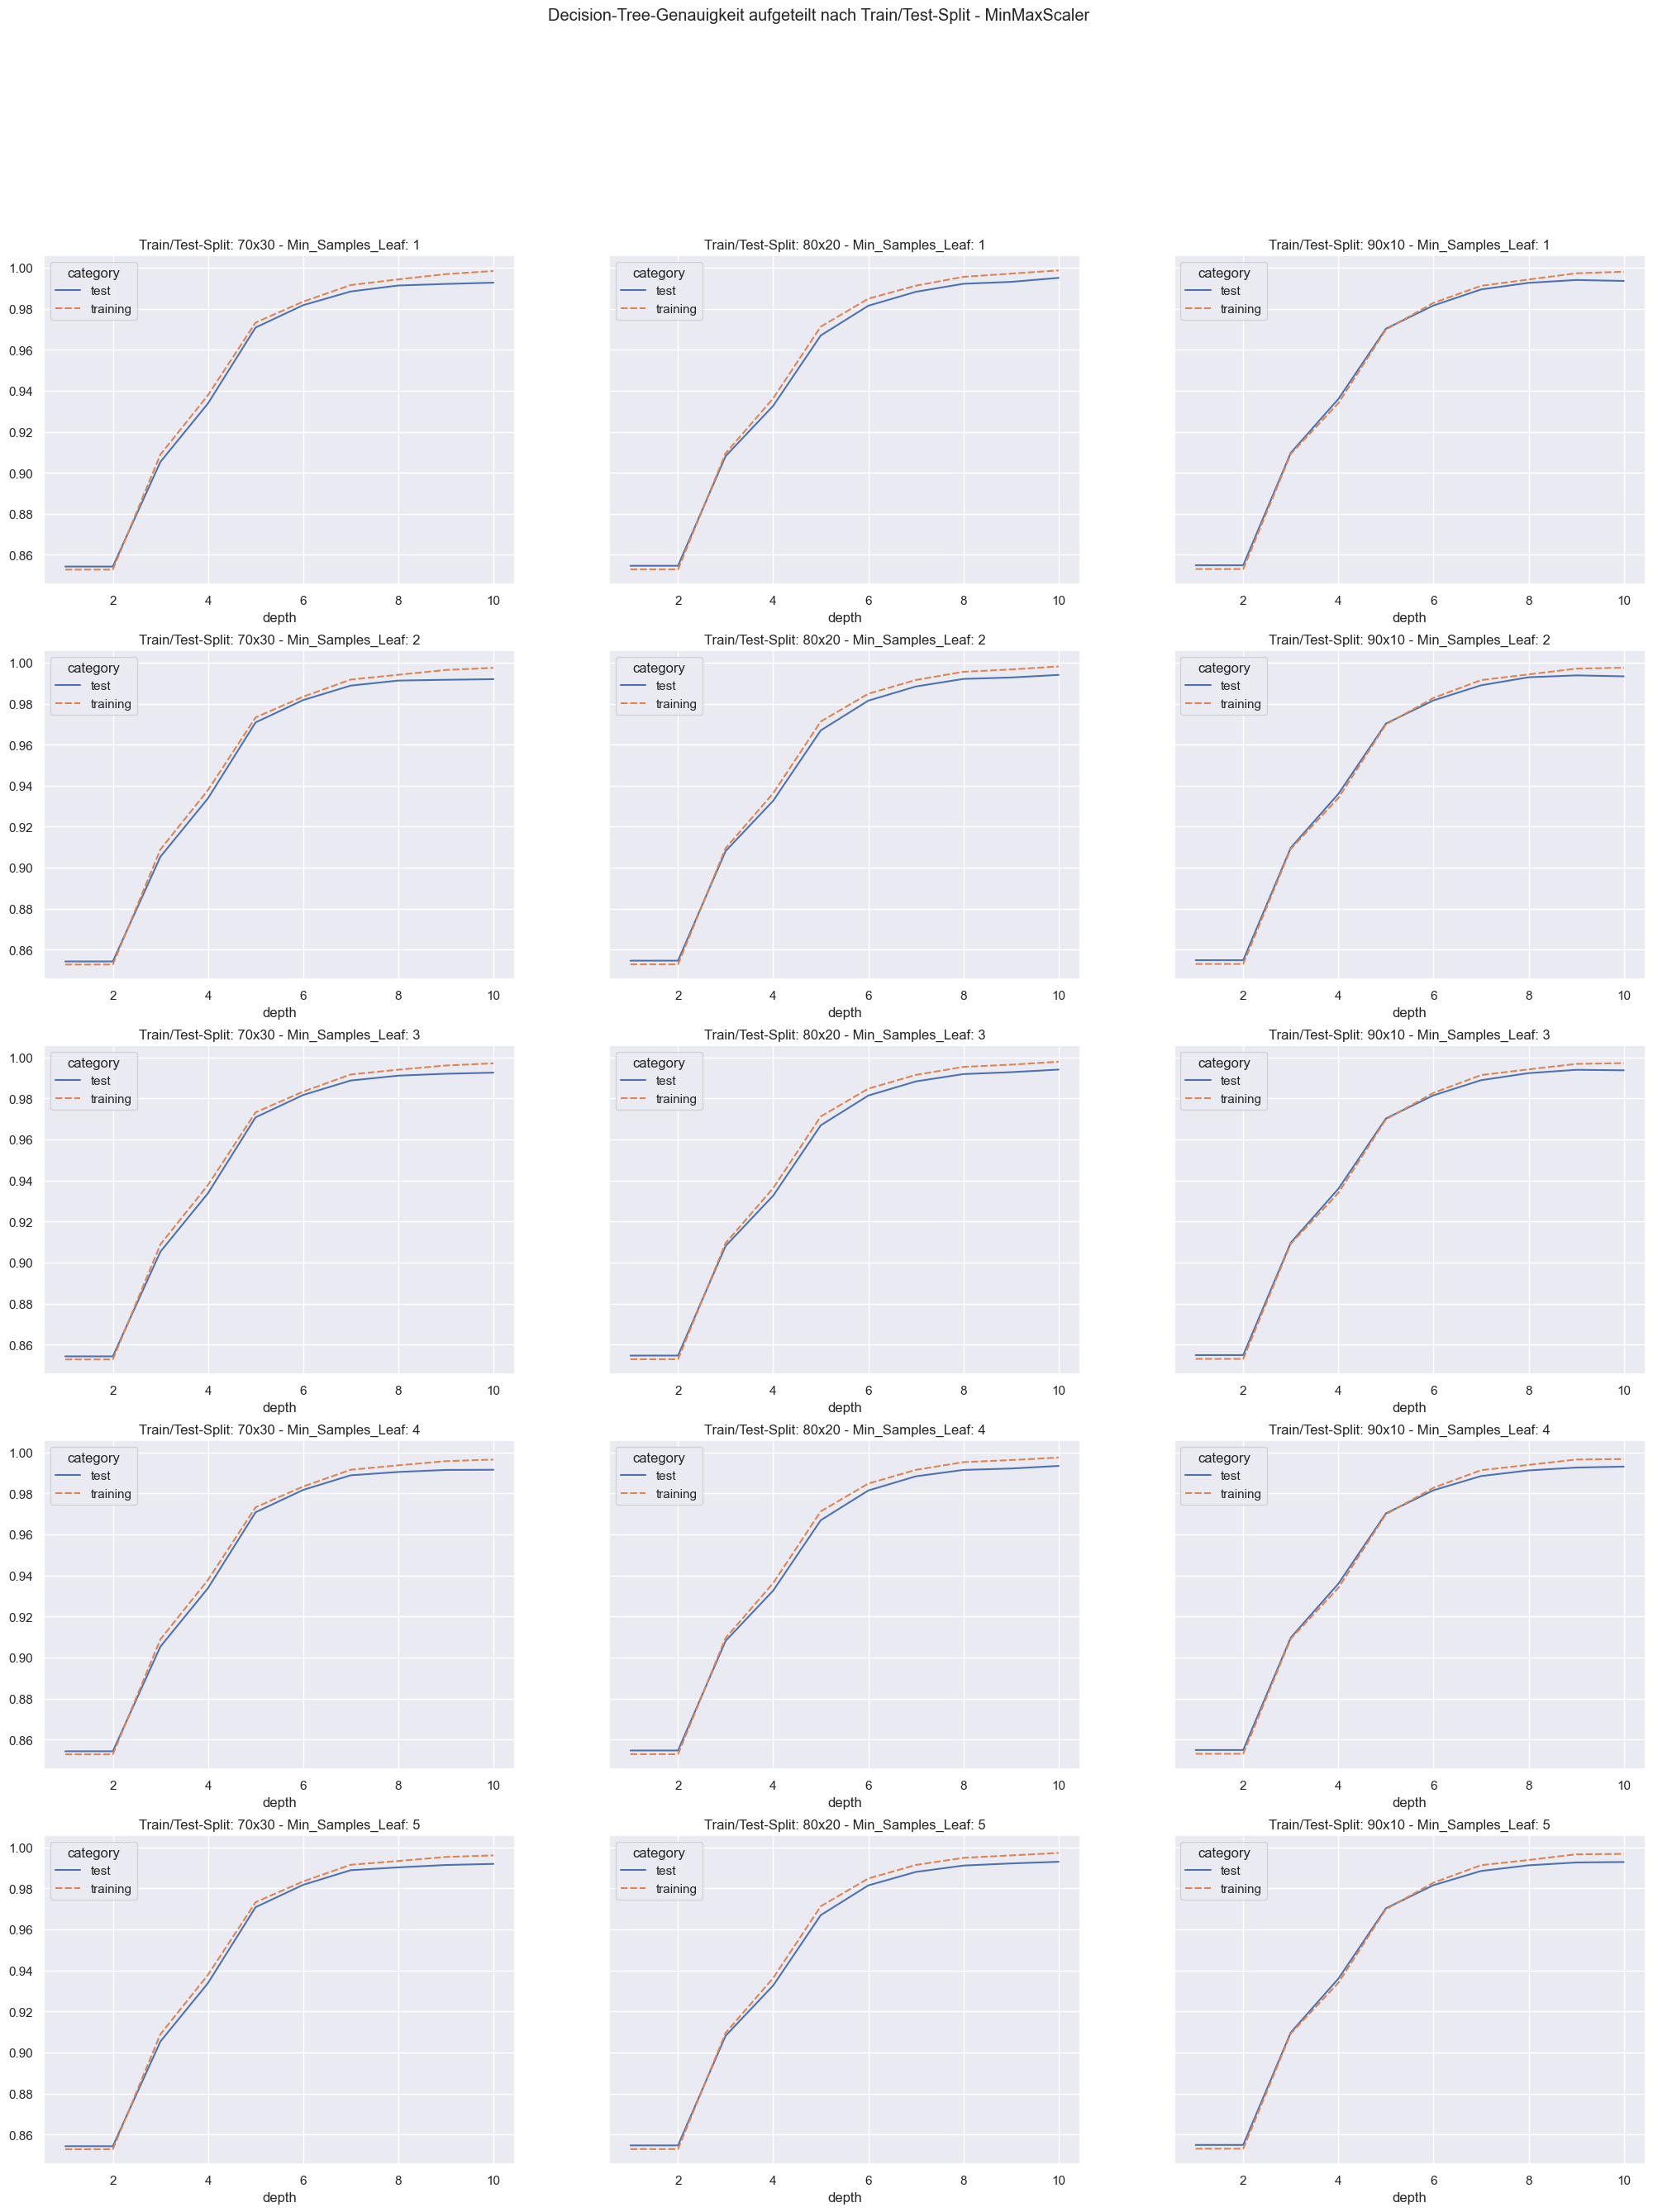

In [83]:
# Iterieren durch Entscheidungsbäume mit Max-Depth = 1-10, Min_Samples_Leaf = 1-5 und verschiedene Train/Test-Splits mit MinMaxScaler

fig_trees_msc, axes_trees_msc = plt.subplots(5,3,figsize=(25,30), sharey=True)
fig_trees_msc.suptitle("Decision-Tree-Genauigkeit aufgeteilt nach Train/Test-Split - MinMaxScaler")


treeframe_8020_msc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train1_MSc, y_train1)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test1_MSc)
        y_train_pred = tree_model.predict(X_train1_MSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_8020_msc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train1, y_train_pred)})
        counter = counter + 1
        treeframe_8020_msc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test1, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_8020_msc.depth.unique()
treeframes_dict_8020_msc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_8020_msc.keys():
    treeframes_dict_8020_msc[key] = treeframe_8020_msc[:][treeframe_8020_msc.leaf == key]

# Grafische Ausgabe
treeframe_8020_msc_1 = treeframes_dict_8020_msc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[0][1], data=treeframe_8020_msc_1)
axes_trees_msc[0][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 1")

treeframe_8020_msc_2 = treeframes_dict_8020_msc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[1][1], data=treeframe_8020_msc_2)
axes_trees_msc[1][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 2")

treeframe_8020_msc_3 = treeframes_dict_8020_msc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[2][1], data=treeframe_8020_msc_3)
axes_trees_msc[2][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 3")

treeframe_8020_msc_4 = treeframes_dict_8020_msc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[3][1], data=treeframe_8020_msc_4)
axes_trees_msc[3][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 4")

treeframe_8020_msc_5 = treeframes_dict_8020_msc[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[4][1], data=treeframe_8020_msc_5)
axes_trees_msc[4][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 5")


treeframe_7030_msc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train2_MSc, y_train2)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test2_MSc)
        y_train_pred = tree_model.predict(X_train2_MSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_7030_msc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train2, y_train_pred)})
        counter = counter + 1
        treeframe_7030_msc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test2, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_7030_msc.depth.unique()
treeframes_dict_7030_msc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_7030_msc.keys():
    treeframes_dict_7030_msc[key] = treeframe_7030_msc[:][treeframe_7030_msc.leaf == key]

# Grafische Ausgabe
treeframe_7030_msc_1 = treeframes_dict_7030_msc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[0][0], data=treeframe_7030_msc_1)
axes_trees_msc[0][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 1")

treeframe_7030_msc_2 = treeframes_dict_7030_msc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[1][0], data=treeframe_7030_msc_2)
axes_trees_msc[1][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 2")

treeframe_7030_msc_3 = treeframes_dict_7030_msc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[2][0], data=treeframe_7030_msc_3)
axes_trees_msc[2][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 3")

treeframe_7030_msc_4 = treeframes_dict_7030_msc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[3][0], data=treeframe_7030_msc_4)
axes_trees_msc[3][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 4")

treeframe_7030_msc_5 = treeframes_dict_7030_msc[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[4][0], data=treeframe_7030_msc_5)
axes_trees_msc[4][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 5")


treeframe_9010_msc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train3_MSc, y_train3)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test3_MSc)
        y_train_pred = tree_model.predict(X_train3_MSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_9010_msc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train3, y_train_pred)})
        counter = counter + 1
        treeframe_9010_msc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test3, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_9010_msc.depth.unique()
treeframes_dict_9010_msc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_9010_msc.keys():
    treeframes_dict_9010_msc[key] = treeframe_9010_msc[:][treeframe_9010_msc.leaf == key]

# Grafische Ausgabe
treeframe_9010_msc_1 = treeframes_dict_9010_msc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[0][2], data=treeframe_9010_msc_1)
axes_trees_msc[0][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 1")

treeframe_9010_msc_2 = treeframes_dict_9010_msc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[1][2], data=treeframe_9010_msc_2)
axes_trees_msc[1][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 2")

treeframe_9010_msc_3 = treeframes_dict_9010_msc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[2][2], data=treeframe_9010_msc_3)
axes_trees_msc[2][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 3")

treeframe_9010_msc_4 = treeframes_dict_9010_msc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_msc[3][2], data=treeframe_9010_msc_4)
axes_trees_msc[3][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 4")

treeframe_9010_msc_5 = treeframes_dict_9010_msc[5].pivot("depth", "category", "accuracy")
plt_tree_acc_msc = scn.lineplot(ax = axes_trees_msc[4][2], data=treeframe_9010_msc_5)
axes_trees_msc[4][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 5")

fig_tree_acc_msc = plt_tree_acc_msc.get_figure()
fig_tree_acc_msc.savefig("Tree_Acc_MinMaxScaler")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_treeframe_8020_msc = get_max_acc_frame(treeframe_8020_msc, "MinMaxScaler", "8020")
max_treeframe_7030_msc = get_max_acc_frame(treeframe_7030_msc, "MinMaxScaler", "7030")
max_treeframe_9010_msc = get_max_acc_frame(treeframe_9010_msc, "MinMaxScaler", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_treeframe_7030_msc, max_treeframe_8020_msc, max_treeframe_9010_msc])
max_trees = pd.concat([max_trees, temp])

display("MinMaxScaler - 8020")
display(treeframe_8020_msc) 
display("MinMaxScaler - 7030")
display(treeframe_7030_msc) 
display("MinMaxScaler - 9010")
display(treeframe_9010_msc) 

# Ergebnis DT

In [84]:
# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_trees = max_trees.reset_index()
max_trees["accuracy"] = pd.to_numeric(max_trees["accuracy"])
max_trees["train_accuracy"] = pd.to_numeric(max_trees["train_accuracy"])
max_trees["depth"] = pd.to_numeric(max_trees["depth"])
max_trees["leaf"] = pd.to_numeric(max_trees["leaf"])
max_trees_max_id =  max_trees["accuracy"].idxmax()
max_trees_result = max_trees.iloc[max_trees_max_id]
display(max_trees_result)

# Bestes Ergebnis in DataFrame zur Endanalyse eintragen
temp = pd.DataFrame(columns=["modell_name", "category", "accuracy"])
temp.loc[1] = pd.Series({"modell_name": "DT-" + str(max_trees_result["modell_cat"]) + "-" + str(max_trees_result["ratio"]) + "-" + str(max_trees_result["depth"]) + "-" + str(max_trees_result["leaf"]), "category": "test", "accuracy": max_trees_result["accuracy"]})
temp.loc[2] = pd.Series({"modell_name": "DT-" + str(max_trees_result["modell_cat"]) + "-" + str(max_trees_result["ratio"]) + "-" + str(max_trees_result["depth"]) + "-" + str(max_trees_result["leaf"]), "category": "training", "accuracy": max_trees_result["train_accuracy"]})
max_acc = pd.concat([max_acc, temp])

index                    1
modell_cat        Standard
ratio                 9010
depth                    9
leaf                     1
accuracy          0.995854
train_accuracy    0.998439
Name: 2, dtype: object

# DT - Iterativ - Reduziert

'8020 - Reduziert'

,category,depth,leaf,accuracy
1,training,1,1,0.576565
2,test,1,1,0.567711
3,training,1,2,0.576565
4,test,1,2,0.567711
5,training,1,3,0.576565
...,...,...,...,...
96,test,10,3,0.649240
97,training,10,4,0.682165
98,test,10,4,0.648895
99,training,10,5,0.681647


'7030 - Reduziert'

,category,depth,leaf,accuracy
1,training,1,1,0.577172
2,test,1,1,0.569246
3,training,1,2,0.577172
4,test,1,2,0.569246
5,training,1,3,0.577172
...,...,...,...,...
96,test,10,3,0.646630
97,training,10,4,0.685816
98,test,10,4,0.646937
99,training,10,5,0.684664


'9010 - Reduziert'

,category,depth,leaf,accuracy
1,training,1,1,0.575351
2,test,1,1,0.569784
3,training,1,2,0.575351
4,test,1,2,0.569784
5,training,1,3,0.575351
...,...,...,...,...
96,test,10,3,0.657301
97,training,10,4,0.688205
98,test,10,4,0.655689
99,training,10,5,0.687463


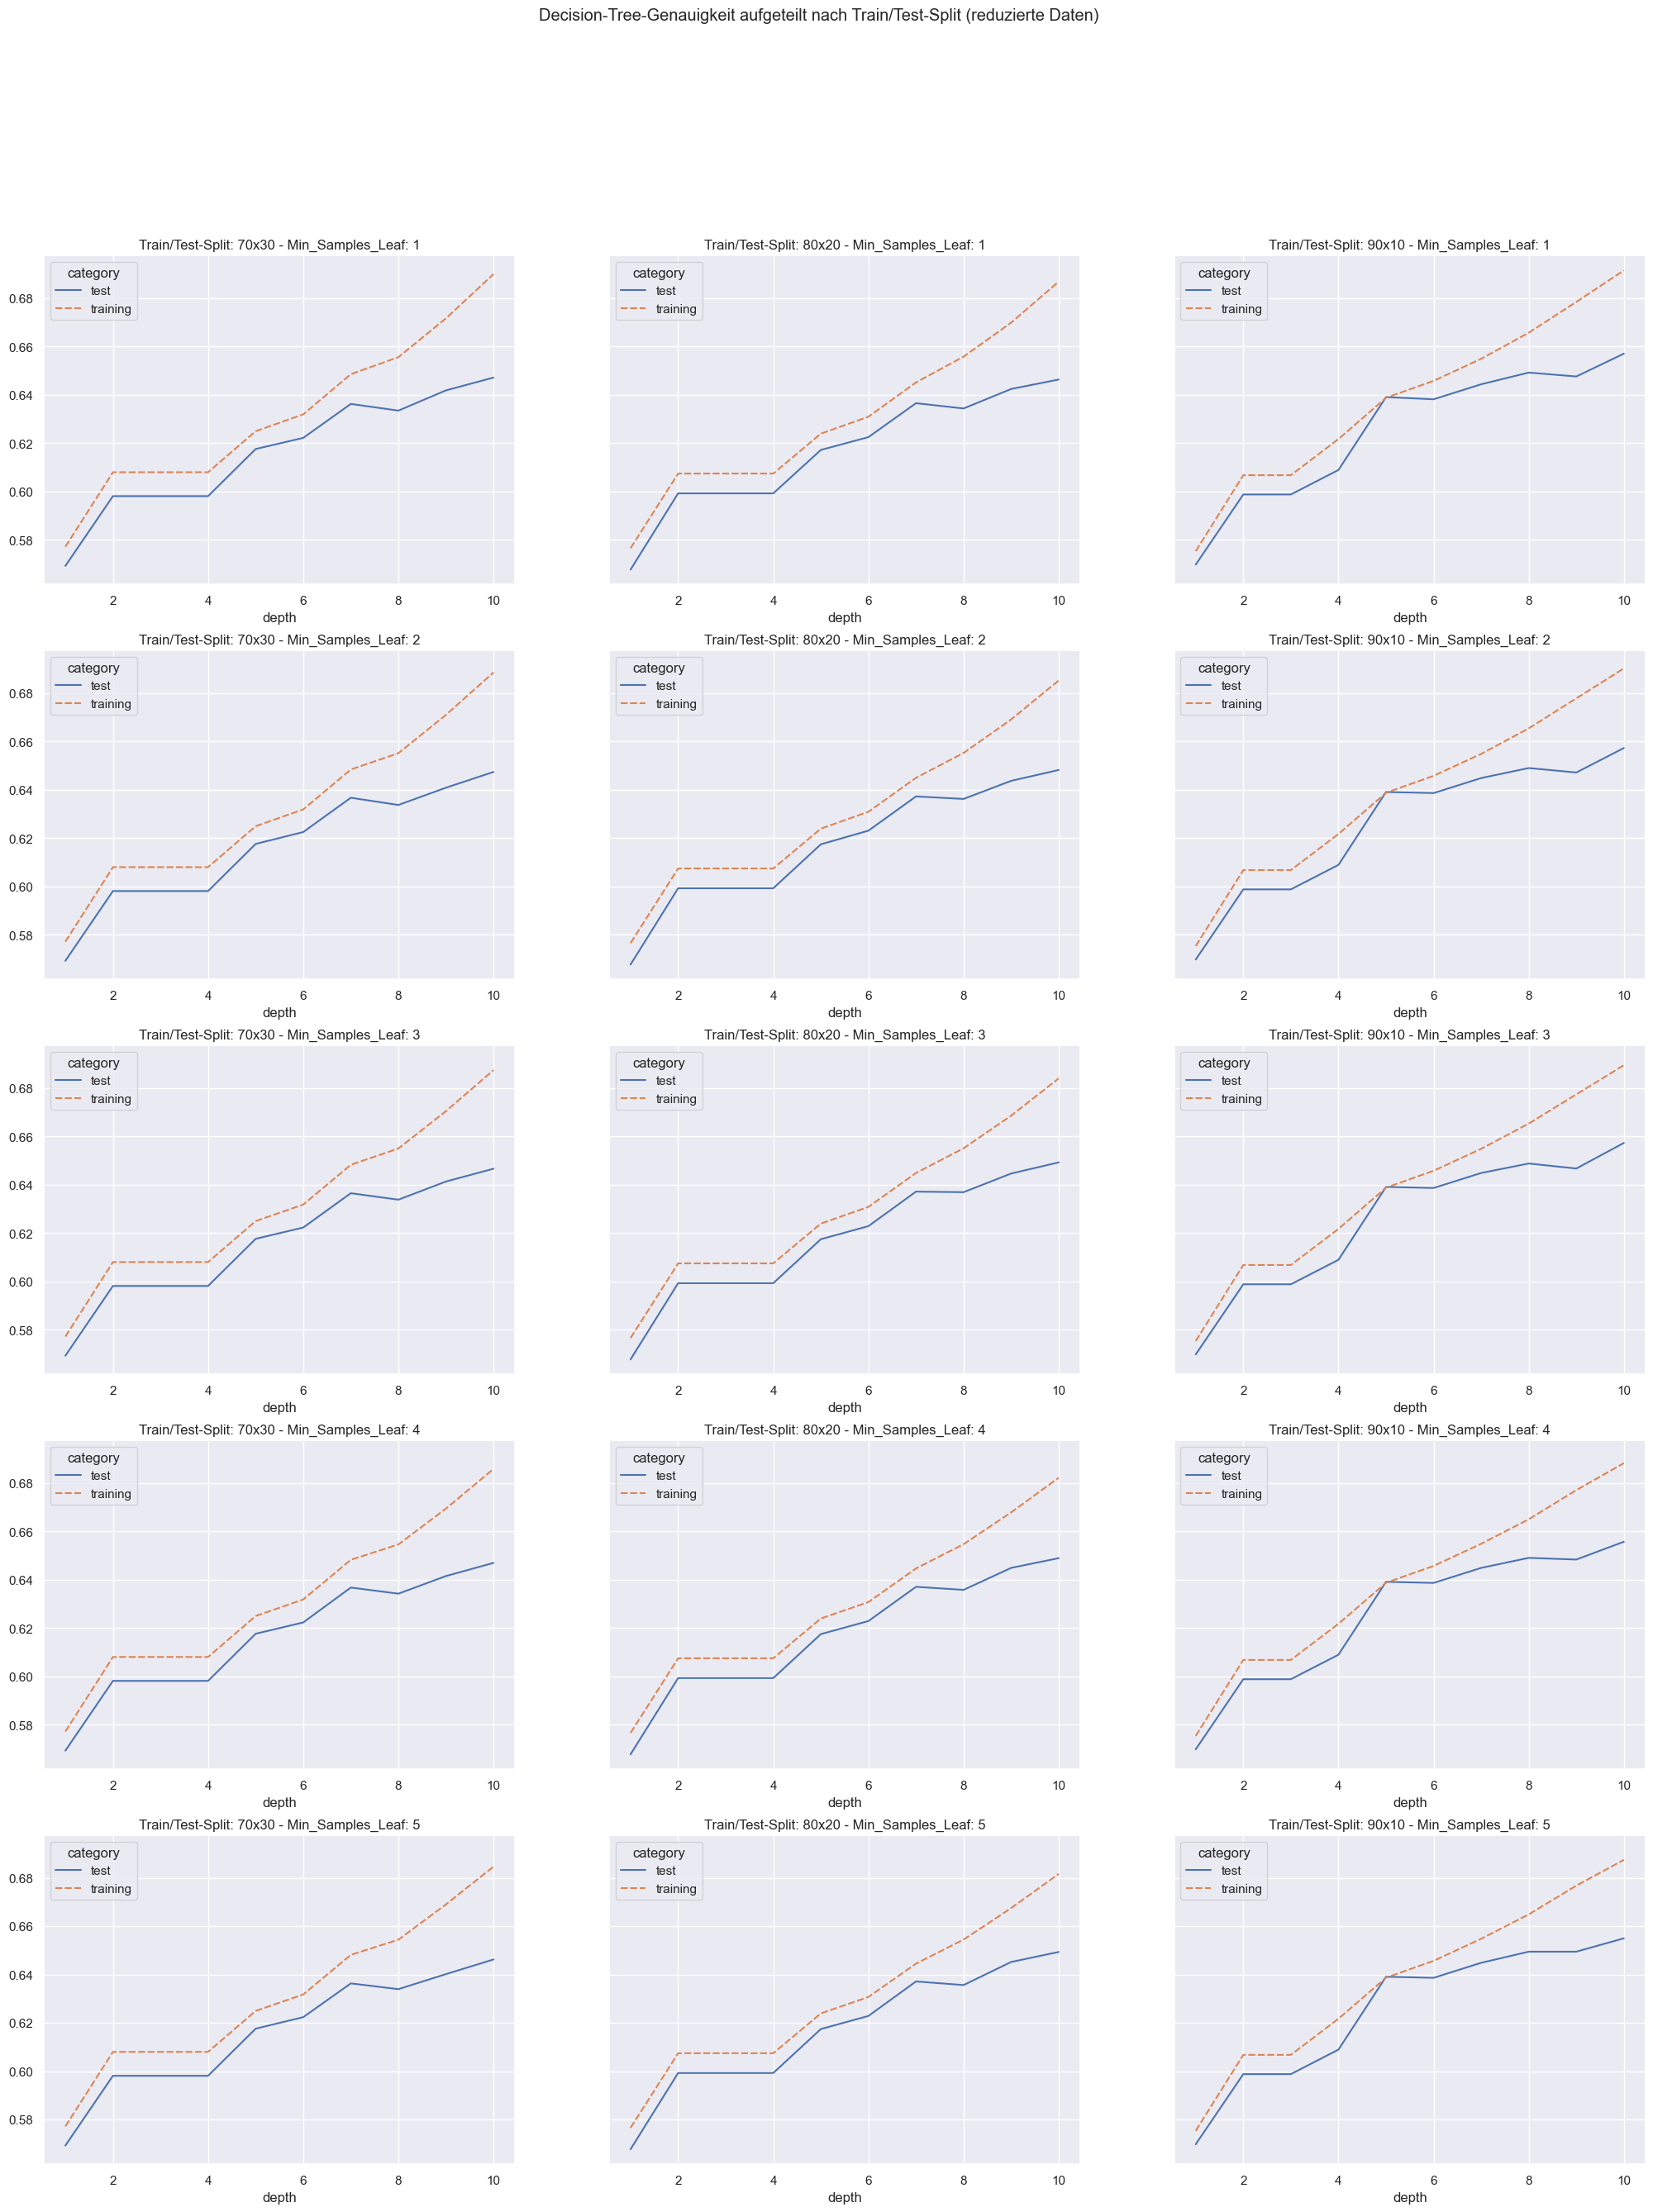

In [85]:
# Iterieren durch Entscheidungsbäume mit Max-Depth = 1-10, Min_Samples_Leaf = 1-5 und verschiedene Train/Test-Splits (reduziert)

fig_trees_red, axes_trees_red = plt.subplots(5,3,figsize=(25,30), sharey=True)
fig_trees_red.suptitle("Decision-Tree-Genauigkeit aufgeteilt nach Train/Test-Split (reduzierte Daten)")

treeframe_8020_red = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train4, y_train4)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test4)
        y_train_pred = tree_model.predict(X_train4)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_8020_red.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train4, y_train_pred)})
        counter = counter + 1
        treeframe_8020_red.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test4, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_8020_red.depth.unique()
treeframes_dict_8020_red = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_8020_red.keys():
    treeframes_dict_8020_red[key] = treeframe_8020_red[:][treeframe_8020_red.leaf == key]

# Grafische Ausgabe
treeframe_8020_red_1 = treeframes_dict_8020_red[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[0][1], data=treeframe_8020_red_1)
axes_trees_red[0][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 1")

treeframe_8020_red_2 = treeframes_dict_8020_red[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[1][1], data=treeframe_8020_red_2)
axes_trees_red[1][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 2")

treeframe_8020_red_3 = treeframes_dict_8020_red[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[2][1], data=treeframe_8020_red_3)
axes_trees_red[2][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 3")

treeframe_8020_red_4 = treeframes_dict_8020_red[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[3][1], data=treeframe_8020_red_4)
axes_trees_red[3][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 4")

treeframe_8020_red_5 = treeframes_dict_8020_red[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[4][1], data=treeframe_8020_red_5)
axes_trees_red[4][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 5")


treeframe_7030_red = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train5, y_train5)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test5)
        y_train_pred = tree_model.predict(X_train5)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_7030_red.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train5, y_train_pred)})
        counter = counter + 1
        treeframe_7030_red.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test5, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_7030_red.depth.unique()
treeframes_dict_7030_red = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_7030_red.keys():
    treeframes_dict_7030_red[key] = treeframe_7030_red[:][treeframe_7030_red.leaf == key]

# Grafische Ausgabe
treeframe_7030_red_1 = treeframes_dict_7030_red[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[0][0], data=treeframe_7030_red_1)
axes_trees_red[0][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 1")

treeframe_7030_red_2 = treeframes_dict_7030_red[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[1][0], data=treeframe_7030_red_2)
axes_trees_red[1][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 2")

treeframe_7030_red_3 = treeframes_dict_7030_red[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[2][0], data=treeframe_7030_red_3)
axes_trees_red[2][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 3")

treeframe_7030_red_4 = treeframes_dict_7030_red[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[3][0], data=treeframe_7030_red_4)
axes_trees_red[3][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 4")

treeframe_7030_red_5 = treeframes_dict_7030_red[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[4][0], data=treeframe_7030_red_5)
axes_trees_red[4][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 5")


treeframe_9010_red = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train6, y_train6)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test6)
        y_train_pred = tree_model.predict(X_train6)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_9010_red.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train6, y_train_pred)})
        counter = counter + 1
        treeframe_9010_red.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test6, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_9010_red.depth.unique()
treeframes_dict_9010_red = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_9010_red.keys():
    treeframes_dict_9010_red[key] = treeframe_9010_red[:][treeframe_9010_red.leaf == key]

# Grafische Ausgabe
treeframe_9010_red_1 = treeframes_dict_9010_red[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[0][2], data=treeframe_9010_red_1)
axes_trees_red[0][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 1")

treeframe_9010_red_2 = treeframes_dict_9010_red[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[1][2], data=treeframe_9010_red_2)
axes_trees_red[1][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 2")

treeframe_9010_red_3 = treeframes_dict_9010_red[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[2][2], data=treeframe_9010_red_3)
axes_trees_red[2][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 3")

treeframe_9010_red_4 = treeframes_dict_9010_red[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red[3][2], data=treeframe_9010_red_4)
axes_trees_red[3][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 4")

treeframe_9010_red_5 = treeframes_dict_9010_red[5].pivot("depth", "category", "accuracy")
plt_tree_red_acc = scn.lineplot(ax = axes_trees_red[4][2], data=treeframe_9010_red_5)
axes_trees_red[4][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 5")

fig_tree_red_acc = plt_tree_red_acc.get_figure()
fig_tree_red_acc.savefig("Tree_Red_Acc")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_treeframe_8020_red = get_max_acc_frame(treeframe_8020_red, "StandardScaler", "8020")
max_treeframe_7030_red = get_max_acc_frame(treeframe_7030_red, "StandardScaler", "7030")
max_treeframe_9010_red = get_max_acc_frame(treeframe_9010_red, "StandardScaler", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_treeframe_7030_red, max_treeframe_8020_red, max_treeframe_9010_red])
max_trees_red = pd.concat([max_trees_red, temp])

display("8020 - Reduziert")
display(treeframe_8020_red) 
display("7030 - Reduziert")
display(treeframe_7030_red) 
display("9010 - Reduziert")
display(treeframe_9010_red) 

# DT - Iterativ - Reduziert - StandardScaler

'StandardScaler - 8020 - Reduziert'

,category,depth,leaf,accuracy
1,training,1,1,0.576565
2,test,1,1,0.567711
3,training,1,2,0.576565
4,test,1,2,0.567711
5,training,1,3,0.576565
...,...,...,...,...
96,test,10,3,0.649240
97,training,10,4,0.682165
98,test,10,4,0.649240
99,training,10,5,0.681647


'StandardScaler - 7030 - Reduziert'

,category,depth,leaf,accuracy
1,training,1,1,0.577172
2,test,1,1,0.569246
3,training,1,2,0.577172
4,test,1,2,0.569246
5,training,1,3,0.577172
...,...,...,...,...
96,test,10,3,0.647321
97,training,10,4,0.685816
98,test,10,4,0.646323
99,training,10,5,0.684697


'StandardScaler - 9010 - Reduziert'

,category,depth,leaf,accuracy
1,training,1,1,0.575351
2,test,1,1,0.569784
3,training,1,2,0.575351
4,test,1,2,0.569784
5,training,1,3,0.575351
...,...,...,...,...
96,test,10,3,0.656840
97,training,10,4,0.688205
98,test,10,4,0.655919
99,training,10,5,0.687514


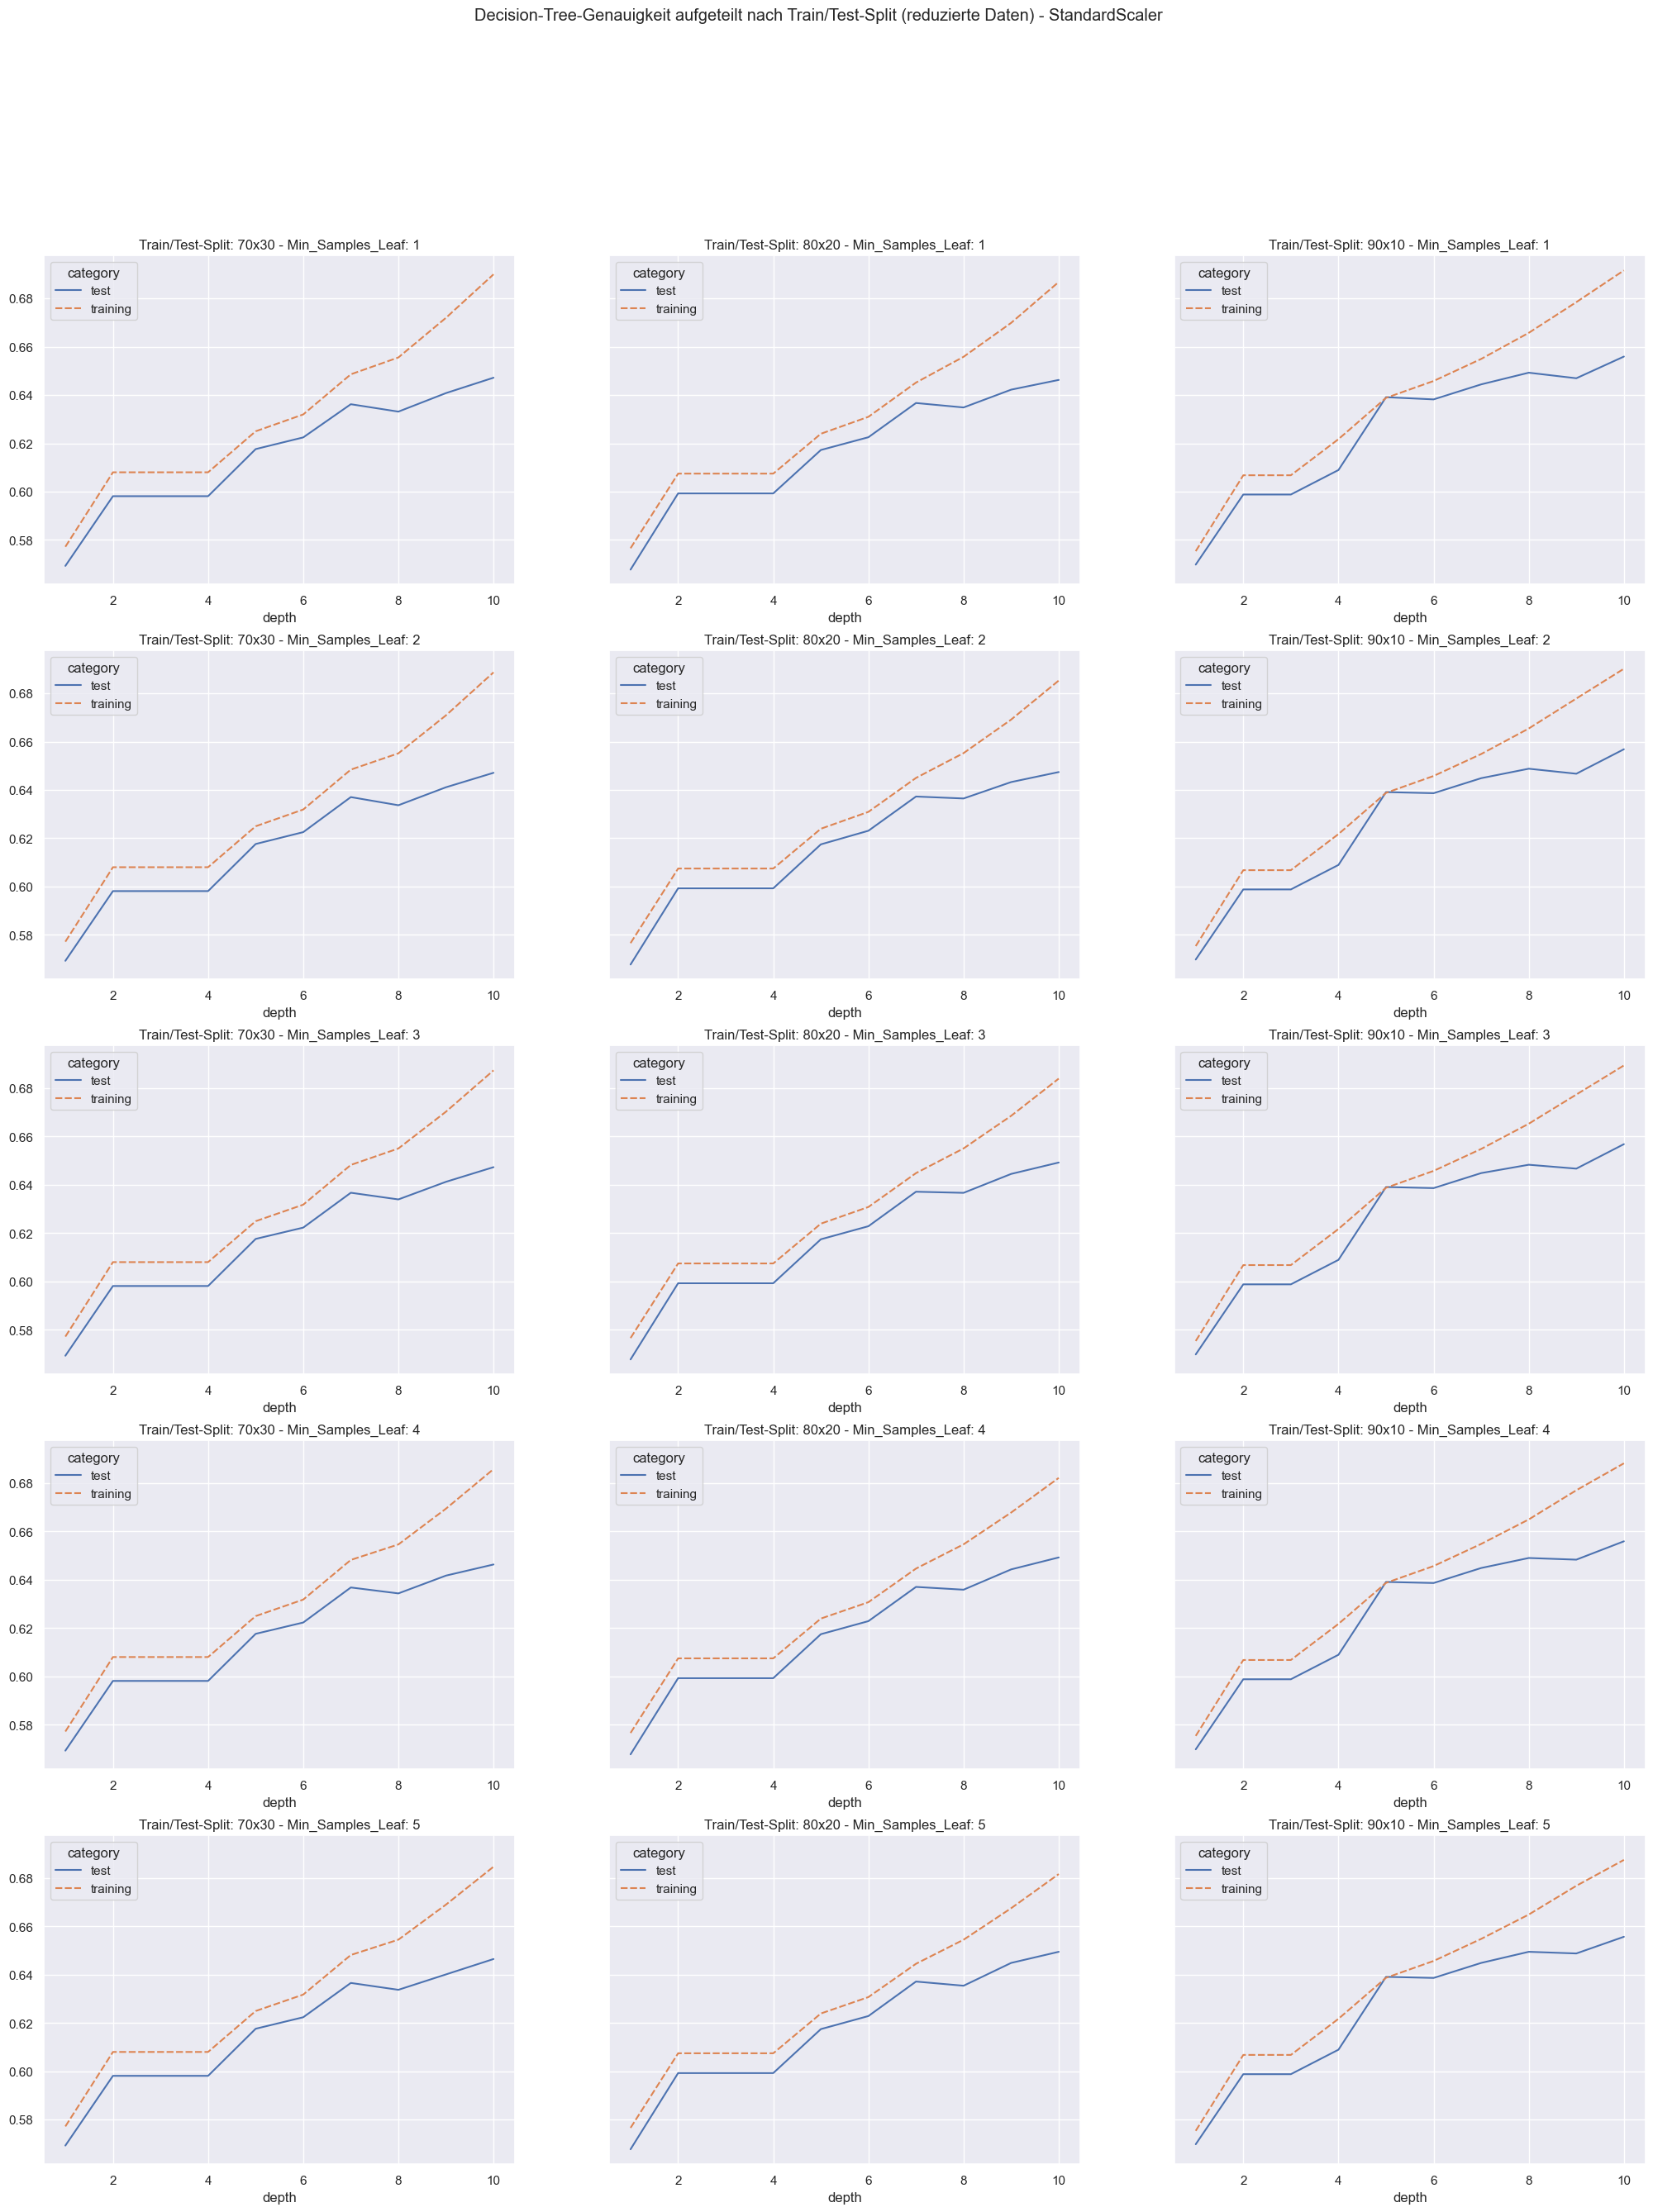

In [86]:
# Iterieren durch Entscheidungsbäume mit Max-Depth = 1-10, Min_Samples_Leaf = 1-5 und verschiedene Train/Test-Splits (reduziert) mit StandardScaler

fig_trees_red_ssc, axes_trees_red_ssc = plt.subplots(5,3,figsize=(25,30), sharey=True)
fig_trees_red_ssc.suptitle("Decision-Tree-Genauigkeit aufgeteilt nach Train/Test-Split (reduzierte Daten) - StandardScaler")

treeframe_8020_red_ssc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train4_SSc, y_train4)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test4_SSc)
        y_train_pred = tree_model.predict(X_train4_SSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_8020_red_ssc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train4, y_train_pred)})
        counter = counter + 1
        treeframe_8020_red_ssc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test4, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_8020_red_ssc.depth.unique()
treeframes_dict_8020_red_ssc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_8020_red_ssc.keys():
    treeframes_dict_8020_red_ssc[key] = treeframe_8020_red_ssc[:][treeframe_8020_red_ssc.leaf == key]

# Grafische Ausgabe
treeframe_8020_red_ssc_1 = treeframes_dict_8020_red_ssc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[0][1], data=treeframe_8020_red_ssc_1)
axes_trees_red_ssc[0][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 1")

treeframe_8020_red_ssc_2 = treeframes_dict_8020_red_ssc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[1][1], data=treeframe_8020_red_ssc_2)
axes_trees_red_ssc[1][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 2")

treeframe_8020_red_ssc_3 = treeframes_dict_8020_red_ssc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[2][1], data=treeframe_8020_red_ssc_3)
axes_trees_red_ssc[2][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 3")

treeframe_8020_red_ssc_4 = treeframes_dict_8020_red_ssc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[3][1], data=treeframe_8020_red_ssc_4)
axes_trees_red_ssc[3][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 4")

treeframe_8020_red_ssc_5 = treeframes_dict_8020_red_ssc[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[4][1], data=treeframe_8020_red_ssc_5)
axes_trees_red_ssc[4][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 5")


treeframe_7030_red_ssc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train5_SSc, y_train5)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test5_SSc)
        y_train_pred = tree_model.predict(X_train5_SSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_7030_red_ssc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train5, y_train_pred)})
        counter = counter + 1
        treeframe_7030_red_ssc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test5, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_7030_red_ssc.depth.unique()
treeframes_dict_7030_red_ssc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_7030_red_ssc.keys():
    treeframes_dict_7030_red_ssc[key] = treeframe_7030_red_ssc[:][treeframe_7030_red_ssc.leaf == key]

# Grafische Ausgabe
treeframe_7030_red_ssc_1 = treeframes_dict_7030_red_ssc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[0][0], data=treeframe_7030_red_ssc_1)
axes_trees_red_ssc[0][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 1")

treeframe_7030_red_ssc_2 = treeframes_dict_7030_red_ssc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[1][0], data=treeframe_7030_red_ssc_2)
axes_trees_red_ssc[1][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 2")

treeframe_7030_red_ssc_3 = treeframes_dict_7030_red_ssc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[2][0], data=treeframe_7030_red_ssc_3)
axes_trees_red_ssc[2][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 3")

treeframe_7030_red_ssc_4 = treeframes_dict_7030_red_ssc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[3][0], data=treeframe_7030_red_ssc_4)
axes_trees_red_ssc[3][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 4")

treeframe_7030_red_ssc_5 = treeframes_dict_7030_red_ssc[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[4][0], data=treeframe_7030_red_ssc_5)
axes_trees_red_ssc[4][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 5")


treeframe_9010_red_ssc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train6_SSc, y_train6)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test6_SSc)
        y_train_pred = tree_model.predict(X_train6_SSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_9010_red_ssc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train6, y_train_pred)})
        counter = counter + 1
        treeframe_9010_red_ssc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test6, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_9010_red_ssc.depth.unique()
treeframes_dict_9010_red_ssc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_9010_red_ssc.keys():
    treeframes_dict_9010_red_ssc[key] = treeframe_9010_red_ssc[:][treeframe_9010_red_ssc.leaf == key]

# Grafische Ausgabe
treeframe_9010_red_ssc_1 = treeframes_dict_9010_red_ssc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[0][2], data=treeframe_9010_red_ssc_1)
axes_trees_red_ssc[0][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 1")

treeframe_9010_red_ssc_2 = treeframes_dict_9010_red_ssc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[1][2], data=treeframe_9010_red_ssc_2)
axes_trees_red_ssc[1][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 2")

treeframe_9010_red_ssc_3 = treeframes_dict_9010_red_ssc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[2][2], data=treeframe_9010_red_ssc_3)
axes_trees_red_ssc[2][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 3")

treeframe_9010_red_ssc_4 = treeframes_dict_9010_red_ssc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_ssc[3][2], data=treeframe_9010_red_ssc_4)
axes_trees_red_ssc[3][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 4")

treeframe_9010_red_ssc_5 = treeframes_dict_9010_red_ssc[5].pivot("depth", "category", "accuracy")
plt_tree_red_acc_ssc = scn.lineplot(ax = axes_trees_red_ssc[4][2], data=treeframe_9010_red_ssc_5)
axes_trees_red_ssc[4][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 5")

fig_tree_red_acc_ssc = plt_tree_red_acc_ssc.get_figure()
fig_tree_red_acc_ssc.savefig("Tree_Red_Acc_StandardScaler")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_treeframe_8020_red_ssc = get_max_acc_frame(treeframe_8020_red_ssc, "Standard", "8020")
max_treeframe_7030_red_ssc = get_max_acc_frame(treeframe_7030_red_ssc, "Standard", "7030")
max_treeframe_9010_red_ssc = get_max_acc_frame(treeframe_9010_red_ssc, "Standard", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_treeframe_7030_red_ssc, max_treeframe_8020_red_ssc, max_treeframe_9010_red_ssc])
max_trees_red = pd.concat([max_trees_red, temp])

display("StandardScaler - 8020 - Reduziert")
display(treeframe_8020_red_ssc) 
display("StandardScaler - 7030 - Reduziert")
display(treeframe_7030_red_ssc) 
display("StandardScaler - 9010 - Reduziert")
display(treeframe_9010_red_ssc) 

# DT - Iterativ - Reduziert - MinMaxScaler

'MinMaxScaler - 8020 - Reduziert'

,category,depth,leaf,accuracy
1,training,1,1,0.576565
2,test,1,1,0.567711
3,training,1,2,0.576565
4,test,1,2,0.567711
5,training,1,3,0.576565
...,...,...,...,...
96,test,10,3,0.647513
97,training,10,4,0.691867
98,test,10,4,0.646476
99,training,10,5,0.691205


'MinMaxScaler - 7030 - Reduziert'

,category,depth,leaf,accuracy
1,training,1,1,0.577172
2,test,1,1,0.569246
3,training,1,2,0.577172
4,test,1,2,0.569246
5,training,1,3,0.577172
...,...,...,...,...
96,test,10,3,0.649394
97,training,10,4,0.691310
98,test,10,4,0.647935
99,training,10,5,0.689896


'MinMaxScaler - 9010 - Reduziert'

,category,depth,leaf,accuracy
1,training,1,1,0.575351
2,test,1,1,0.569784
3,training,1,2,0.575351
4,test,1,2,0.569784
5,training,1,3,0.575351
...,...,...,...,...
96,test,10,3,0.652695
97,training,10,4,0.686465
98,test,10,4,0.652234
99,training,10,5,0.685339


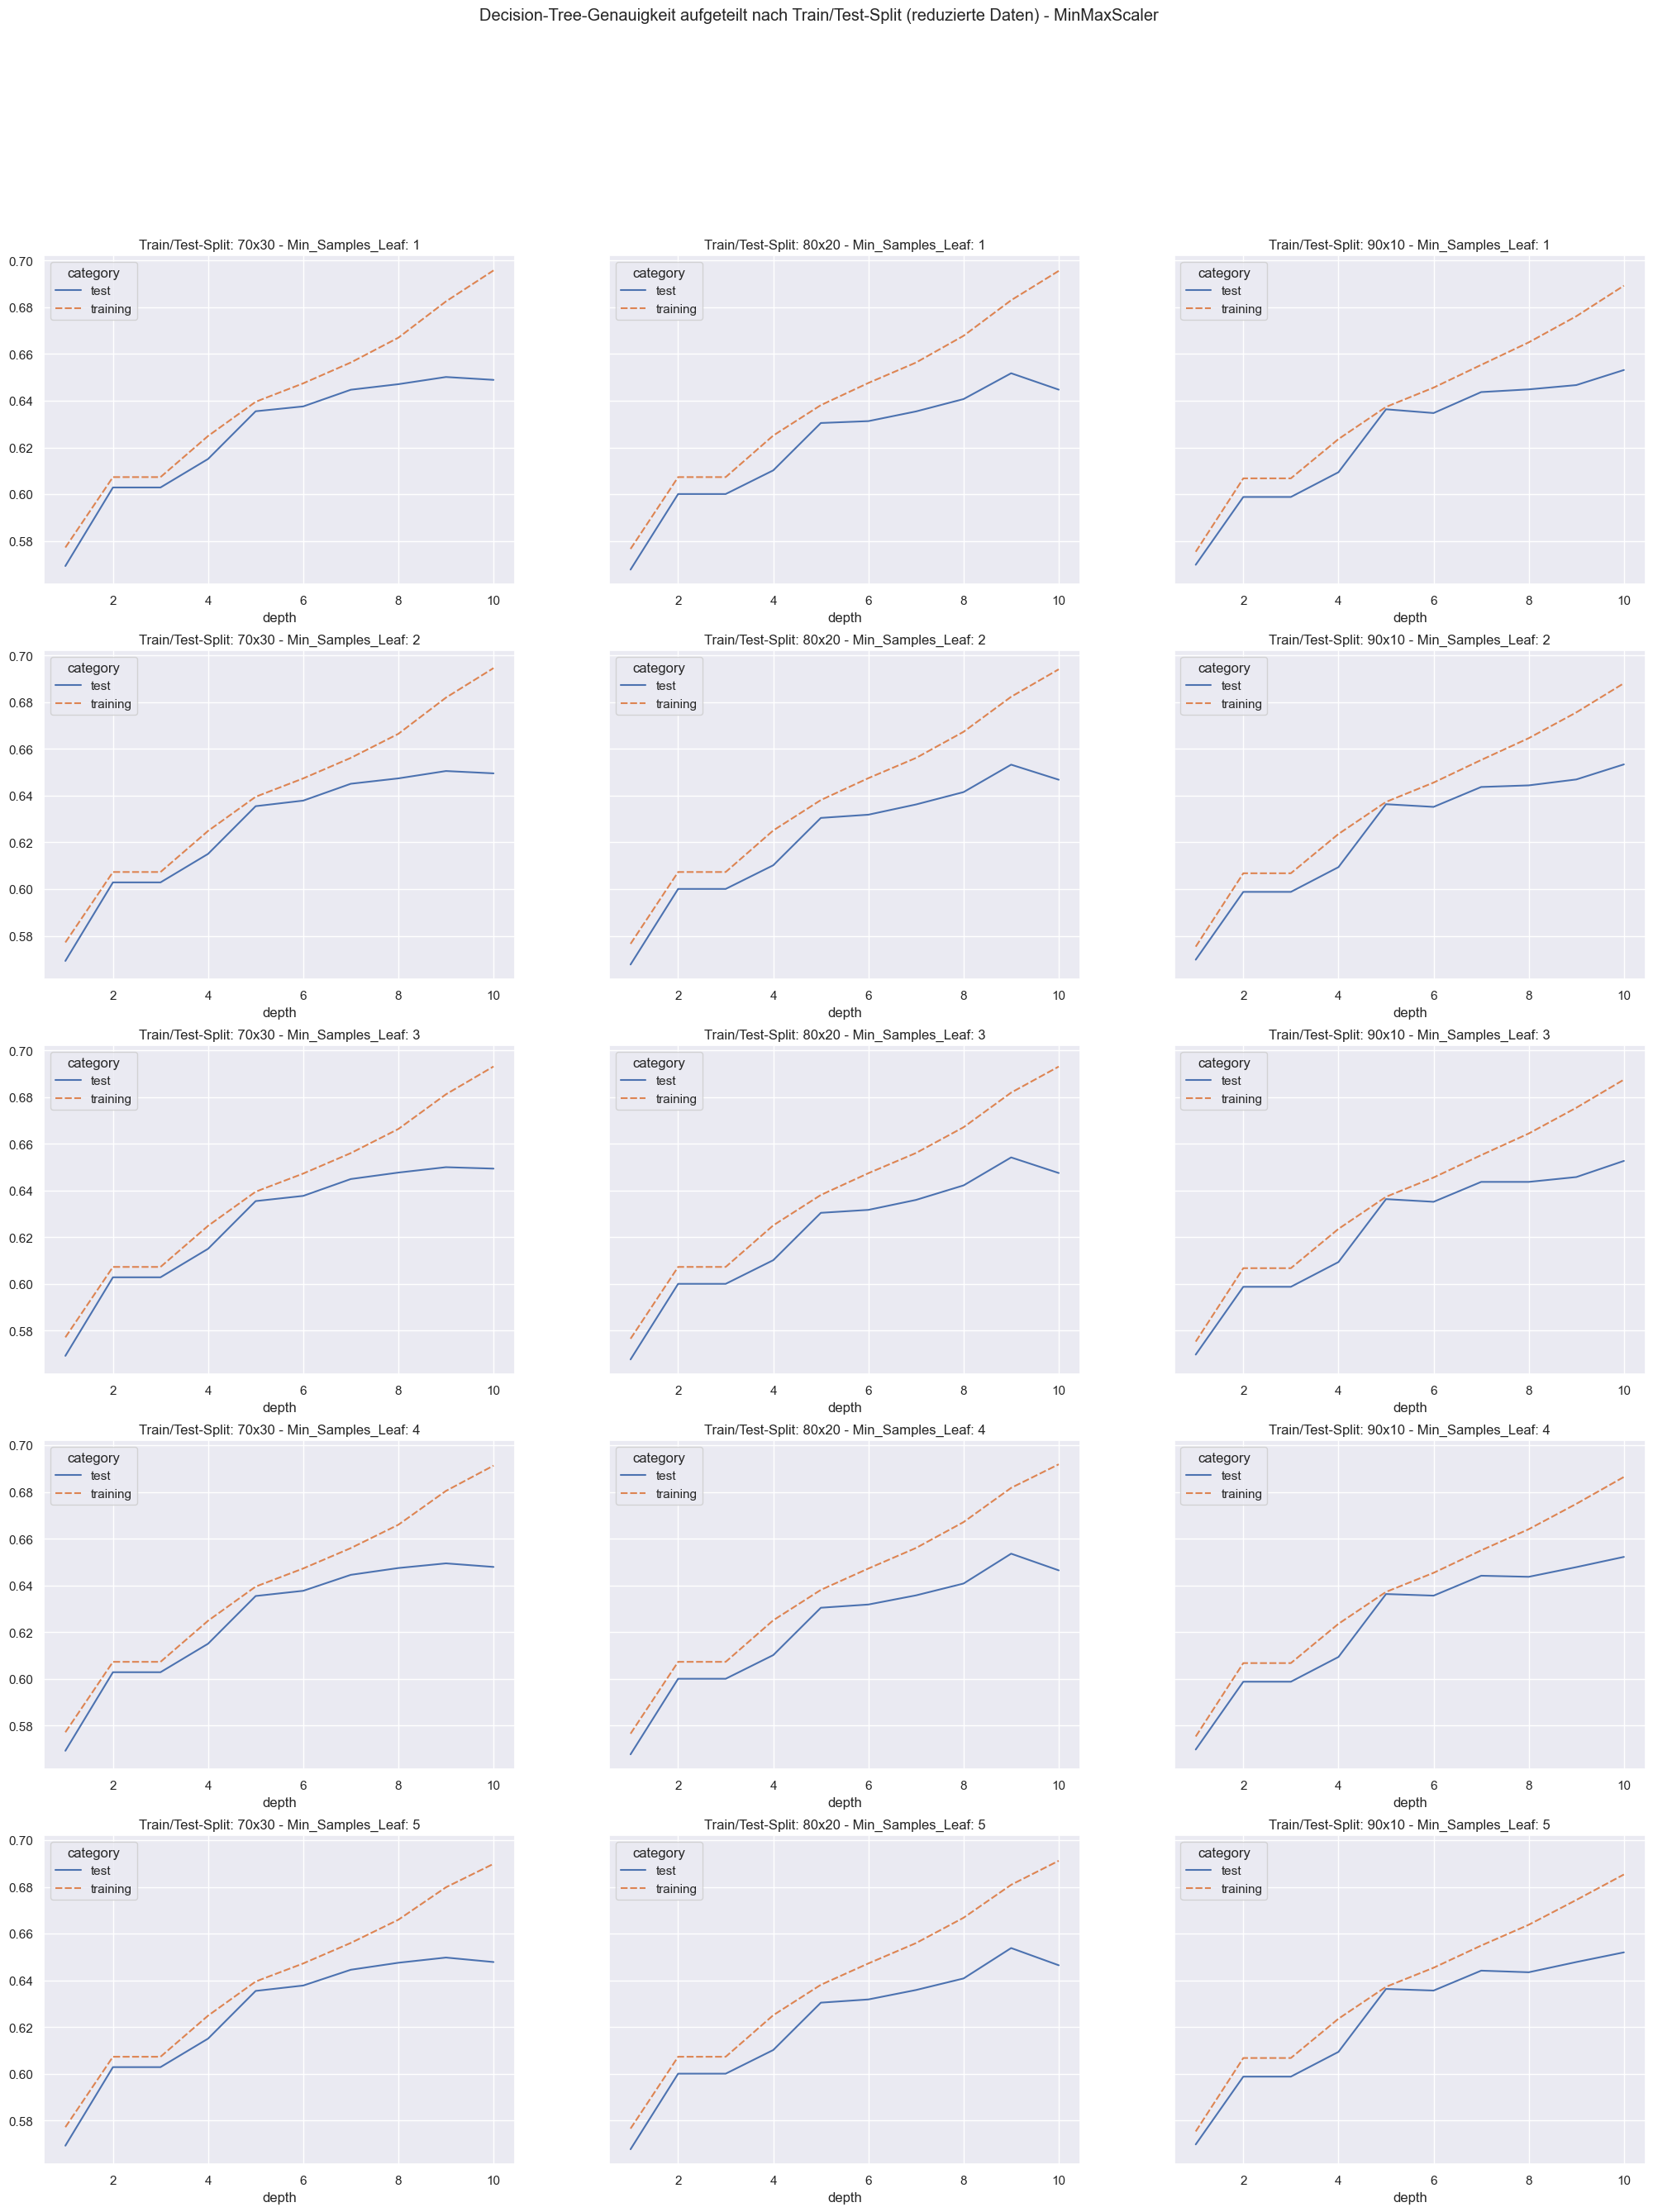

In [87]:
# Iterieren durch Entscheidungsbäume mit Max-Depth = 1-10, Min_Samples_Leaf = 1-5 und verschiedene Train/Test-Splits (reduziert) mit MinMaxScler

fig_trees_red_msc, axes_trees_red_msc = plt.subplots(5,3,figsize=(25,30), sharey=True)
fig_trees_red_msc.suptitle("Decision-Tree-Genauigkeit aufgeteilt nach Train/Test-Split (reduzierte Daten) - MinMaxScaler")

treeframe_8020_red_msc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train4_MSc, y_train4)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test4_MSc)
        y_train_pred = tree_model.predict(X_train4_MSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_8020_red_msc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train4, y_train_pred)})
        counter = counter + 1
        treeframe_8020_red_msc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test4, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_8020_red_msc.depth.unique()
treeframes_dict_8020_red_msc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_8020_red_msc.keys():
    treeframes_dict_8020_red_msc[key] = treeframe_8020_red_msc[:][treeframe_8020_red_msc.leaf == key]

# Grafische Ausgabe
treeframe_8020_red_msc_1 = treeframes_dict_8020_red_msc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[0][1], data=treeframe_8020_red_msc_1)
axes_trees_red_msc[0][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 1")

treeframe_8020_red_msc_2 = treeframes_dict_8020_red_msc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[1][1], data=treeframe_8020_red_msc_2)
axes_trees_red_msc[1][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 2")

treeframe_8020_red_msc_3 = treeframes_dict_8020_red_msc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[2][1], data=treeframe_8020_red_msc_3)
axes_trees_red_msc[2][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 3")

treeframe_8020_red_msc_4 = treeframes_dict_8020_red_msc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[3][1], data=treeframe_8020_red_msc_4)
axes_trees_red_msc[3][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 4")

treeframe_8020_red_msc_5 = treeframes_dict_8020_red_msc[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[4][1], data=treeframe_8020_red_msc_5)
axes_trees_red_msc[4][1].set_title("Train/Test-Split: 80x20 - Min_Samples_Leaf: 5")


treeframe_7030_red_msc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train5_MSc, y_train5)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test5_MSc)
        y_train_pred = tree_model.predict(X_train5_MSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_7030_red_msc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train5, y_train_pred)})
        counter = counter + 1
        treeframe_7030_red_msc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test5, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_7030_red_msc.depth.unique()
treeframes_dict_7030_red_msc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_7030_red_msc.keys():
    treeframes_dict_7030_red_msc[key] = treeframe_7030_red_msc[:][treeframe_7030_red_msc.leaf == key]

# Grafische Ausgabe
treeframe_7030_red_msc_1 = treeframes_dict_7030_red_msc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[0][0], data=treeframe_7030_red_msc_1)
axes_trees_red_msc[0][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 1")

treeframe_7030_red_msc_2 = treeframes_dict_7030_red_msc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[1][0], data=treeframe_7030_red_msc_2)
axes_trees_red_msc[1][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 2")

treeframe_7030_red_msc_3 = treeframes_dict_7030_red_msc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[2][0], data=treeframe_7030_red_msc_3)
axes_trees_red_msc[2][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 3")

treeframe_7030_red_msc_4 = treeframes_dict_7030_red_msc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[3][0], data=treeframe_7030_red_msc_4)
axes_trees_red_msc[3][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 4")

treeframe_7030_red_msc_5 = treeframes_dict_7030_red_msc[5].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[4][0], data=treeframe_7030_red_msc_5)
axes_trees_red_msc[4][0].set_title("Train/Test-Split: 70x30 - Min_Samples_Leaf: 5")


treeframe_9010_red_msc = pd.DataFrame(columns=["category", "depth", "leaf", "accuracy"])
counter = 0

for i in range(1,11):
    for j in range(1,6):
        tree_model = DecisionTreeClassifier(max_depth = int(i), min_samples_leaf = int(j))
        tree_model.fit(X_train6_MSc, y_train6)
        # Vorhersagen für Test- und Trainingswert
        y_pred = tree_model.predict(X_test6_MSc)
        y_train_pred = tree_model.predict(X_train6_MSc)
    
        #Ausgabe der Genauigkeitswerte
        counter = counter + 1
        treeframe_9010_red_msc.loc[counter] = pd.Series({"category": "training", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_train6, y_train_pred)})
        counter = counter + 1
        treeframe_9010_red_msc.loc[counter] = pd.Series({"category": "test", "depth":int(i), "leaf":int(j), "accuracy":accuracy_score(y_test6, y_pred)})

# Aufsplittern eines Frames in mehrere basierend auf leaf-Wert
unique_leaf = treeframe_9010_red_msc.depth.unique()
treeframes_dict_9010_red_msc = {elem:pd.DataFrame() for elem in unique_leaf}
for key in treeframes_dict_9010_red_msc.keys():
    treeframes_dict_9010_red_msc[key] = treeframe_9010_red_msc[:][treeframe_9010_red_msc.leaf == key]

# Grafische Ausgabe
treeframe_9010_red_msc_1 = treeframes_dict_9010_red_msc[1].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[0][2], data=treeframe_9010_red_msc_1)
axes_trees_red_msc[0][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 1")

treeframe_9010_red_msc_2 = treeframes_dict_9010_red_msc[2].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[1][2], data=treeframe_9010_red_msc_2)
axes_trees_red_msc[1][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 2")

treeframe_9010_red_msc_3 = treeframes_dict_9010_red_msc[3].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[2][2], data=treeframe_9010_red_msc_3)
axes_trees_red_msc[2][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 3")

treeframe_9010_red_msc_4 = treeframes_dict_9010_red_msc[4].pivot("depth", "category", "accuracy")
scn.lineplot(ax = axes_trees_red_msc[3][2], data=treeframe_9010_red_msc_4)
axes_trees_red_msc[3][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 4")

treeframe_9010_red_msc_5 = treeframes_dict_9010_red_msc[5].pivot("depth", "category", "accuracy")
plt_tree_red_acc_msc = scn.lineplot(ax = axes_trees_red_msc[4][2], data=treeframe_9010_red_msc_5)
axes_trees_red_msc[4][2].set_title("Train/Test-Split: 90x10 - Min_Samples_Leaf: 5")

fig_tree_red_acc_msc = plt_tree_red_acc_msc.get_figure()
fig_tree_red_acc_msc.savefig("Tree_Red_Acc_MinMaxScaler")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_treeframe_8020_red_msc = get_max_acc_frame(treeframe_8020_red_msc, "MinMaxScaler", "8020")
max_treeframe_7030_red_msc = get_max_acc_frame(treeframe_7030_red_msc, "MinMaxScaler", "7030")
max_treeframe_9010_red_msc = get_max_acc_frame(treeframe_9010_red_msc, "MinMaxScaler", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_treeframe_7030_red_msc, max_treeframe_8020_red_msc, max_treeframe_9010_red_msc])
max_trees_red = pd.concat([max_trees_red, temp])

display("MinMaxScaler - 8020 - Reduziert")
display(treeframe_8020_red_msc) 
display("MinMaxScaler - 7030 - Reduziert")
display(treeframe_7030_red_msc) 
display("MinMaxScaler - 9010 - Reduziert")
display(treeframe_9010_red_msc) 

# Ergebnis DT - Reduziert

In [88]:
# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_trees_red = max_trees_red.reset_index()
max_trees_red["accuracy"] = pd.to_numeric(max_trees_red["accuracy"])
max_trees_red["train_accuracy"] = pd.to_numeric(max_trees_red["train_accuracy"])
max_trees_red["depth"] = pd.to_numeric(max_trees_red["depth"])
max_trees_red["leaf"] = pd.to_numeric(max_trees_red["leaf"])
max_trees_max_id_red =  max_trees_red["accuracy"].idxmax()
max_trees_red_result = max_trees_red.iloc[max_trees_max_id_red]
display(max_trees_red_result)

# Bestes Ergebnis in DataFrame zur Endanalyse eintragen
temp = pd.DataFrame(columns=["modell_name", "category", "accuracy"])
temp.loc[1] = pd.Series({"modell_name": "DT-" + str(max_trees_red_result["modell_cat"]) + "-" + str(max_trees_red_result["ratio"]) + "-" + str(max_trees_red_result["depth"]) + "-" + str(max_trees_red_result["leaf"]), "category": "test", "accuracy": max_trees_red_result["accuracy"]})
temp.loc[2] = pd.Series({"modell_name": "DT-" + str(max_trees_red_result["modell_cat"]) + "-" + str(max_trees_red_result["ratio"]) + "-" + str(max_trees_red_result["depth"]) + "-" + str(max_trees_red_result["leaf"]), "category": "training", "accuracy": max_trees_red_result["train_accuracy"]})
max_acc_red = pd.concat([max_acc_red, temp])

index                          1
modell_cat        StandardScaler
ratio                       9010
depth                         10
leaf                           2
accuracy                0.657301
train_accuracy          0.690253
Name: 2, dtype: object

# K-Nearest Neighbor (KNN)

In [89]:
# DataFrames zur Sammlung der besten Baummodelle für eine Zwischenanalyse
max_knn= pd.DataFrame(columns=["modell_cat", "ratio", "neighbors", "accuracy", "train_accuracy"])
max_knn_red= pd.DataFrame(columns=["modell_cat", "ratio", "neighbors", "accuracy", "train_accuracy"])

# KNN - Iterativ 

In [90]:
# Funktion um den Eintrag mit maximaler Test-Genauigkeit aus einem DataFrame (für KNN) zu gewinnen
def get_max_acc_frame_knn(frame, mode, ratio):
    erg = pd.DataFrame(columns=["modell_cat", "ratio", "neighbors", "accuracy", "train_accuracy"])
    temp = frame
    temp["accuracy"] = pd.to_numeric(temp["accuracy"])
    temp_red = temp.loc[temp["category"] == "test"]
    max_acc_id = temp_red["accuracy"].idxmax() -1
    max_acc_id_train = max_acc_id - 1
    erg.loc[1] =  pd.Series({"modell_cat": mode, "ratio": ratio, "neighbors": temp.iloc[max_acc_id]["neighbors"], "accuracy": temp.iloc[max_acc_id]["accuracy"], "train_accuracy": temp.iloc[max_acc_id_train]["accuracy"]})
    return erg

'8020'

,category,neighbors,accuracy
1,training,1,1.000000
2,test,1,0.998618
3,training,2,0.999712
4,test,2,0.998158
5,training,3,0.999108
6,test,3,0.998158
7,training,4,0.999223
8,test,4,0.997927
9,training,5,0.998762
10,test,5,0.998158


'7030'

,category,neighbors,accuracy
1,training,1,1.000000
2,test,1,0.998618
3,training,2,0.999638
4,test,2,0.998541
5,training,3,0.999112
6,test,3,0.998465
7,training,4,0.999145
8,test,4,0.998311
9,training,5,0.998585
10,test,5,0.998158


'9010'

,category,neighbors,accuracy
1,training,1,1.000000
2,test,1,0.999079
3,training,2,0.999719
4,test,2,0.998848
5,training,3,0.999079
6,test,3,0.998848
7,training,4,0.999156
8,test,4,0.999079
9,training,5,0.998720
10,test,5,0.998848


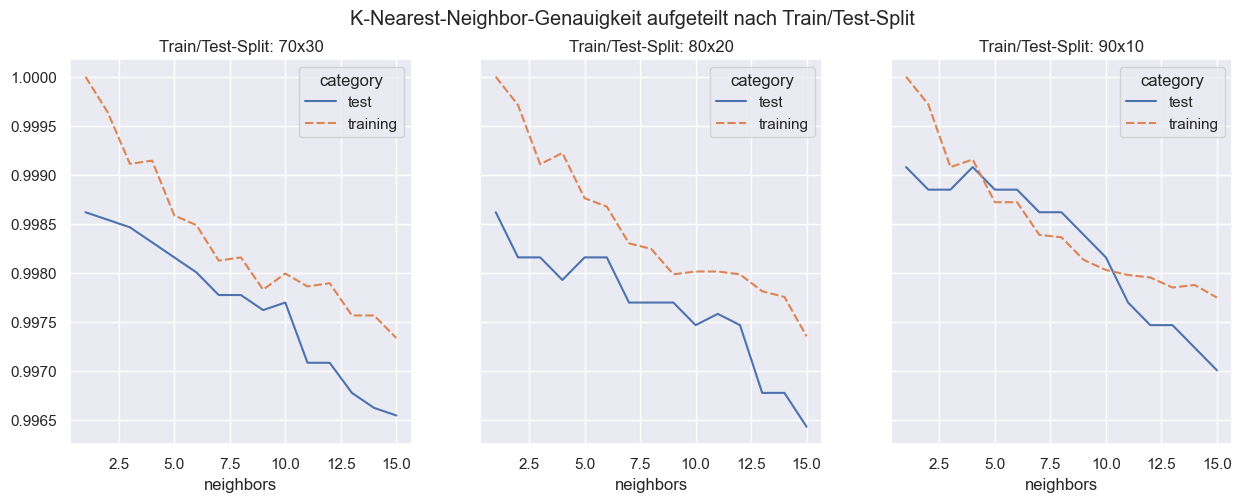

In [91]:
# Iterieren durch KNN-Modelle mit Neighbors = 1-15 und verschiedenen Train/Test-Splits
fig_knn, axes_knn = plt.subplots(1,3,figsize=(15,5), sharey=True)
fig_knn.suptitle("K-Nearest-Neighbor-Genauigkeit aufgeteilt nach Train/Test-Split")

knnframe_8020 = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0
for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train1,y_train1)
    y_train_pred = knn_model.predict(X_train1)
    y_pred = knn_model.predict(X_test1)
    
    counter = counter + 1
    knnframe_8020.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train1, y_train_pred)})
    counter = counter + 1
    knnframe_8020.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test1, y_pred)})

knnframe_8020_pivot = knnframe_8020.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn[1], data=knnframe_8020_pivot)
axes_knn[1].set_title("Train/Test-Split: 80x20")


knnframe_7030 = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0
for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train2,y_train2)
    y_train_pred = knn_model.predict(X_train2)
    y_pred = knn_model.predict(X_test2)

    counter = counter + 1
    knnframe_7030.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train2, y_train_pred)})
    counter = counter + 1
    knnframe_7030.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test2, y_pred)})

knnframe_7030_pivot = knnframe_7030.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn[0], data=knnframe_7030_pivot)
axes_knn[0].set_title("Train/Test-Split: 70x30")


knnframe_9010 = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0
for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train3,y_train3)
    y_train_pred = knn_model.predict(X_train3)
    y_pred = knn_model.predict(X_test3)

    counter = counter + 1
    knnframe_9010.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train3, y_train_pred)})
    counter = counter + 1
    knnframe_9010.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test3, y_pred)})

knnframe_9010_pivot = knnframe_9010.pivot("neighbors", "category", "accuracy")
plt_knn_acc = scn.lineplot(ax = axes_knn[2], data=knnframe_9010_pivot)
axes_knn[2].set_title("Train/Test-Split: 90x10")

fig_knn_acc = plt_knn_acc.get_figure()
fig_knn_acc.savefig("KNN_Acc")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_knnframe_8020 = get_max_acc_frame_knn(knnframe_8020, "Standard", "8020")
max_knnframe_7030 = get_max_acc_frame_knn(knnframe_7030, "Standard", "7030")
max_knnframe_9010 = get_max_acc_frame_knn(knnframe_9010, "Standard", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_knnframe_7030, max_knnframe_8020, max_knnframe_9010])
max_knn = pd.concat([max_knn, temp])

display("8020")
display(knnframe_8020) 
display("7030")
display(knnframe_7030)
display("9010") 
display(knnframe_9010) 

# KNN - Iterativ - Scaler

       modell_cat ratio neighbors  accuracy train_accuracy
1        Standard  7030         1  0.998618            1.0
1        Standard  8020         1  0.998618            1.0
1        Standard  9010         1  0.999079            1.0
1  StandardScaler  7030        11  0.683172       0.742934
1  StandardScaler  8020        13  0.679871       0.736231
1  StandardScaler  9010        13  0.688853       0.737006


'StandardScaler - 8020'

,category,neighbors,accuracy
1,training,1,1.000000
2,test,1,0.653270
3,training,2,0.816180
4,test,2,0.659258
5,training,3,0.829768
6,test,3,0.667895
7,training,4,0.776738
8,test,4,0.667434
9,training,5,0.785692
10,test,5,0.672041


'StandardScaler - 7030'

,category,neighbors,accuracy
1,training,1,1.000000
2,test,1,0.656072
3,training,2,0.813214
4,test,2,0.661677
5,training,3,0.828612
6,test,3,0.668509
7,training,4,0.774784
8,test,4,0.673422
9,training,5,0.785641
10,test,5,0.673192


...

,category,neighbors,accuracy
1,training,1,1.000000
2,test,1,0.590511
3,training,2,0.790212
4,test,2,0.599608
5,training,3,0.795307
6,test,3,0.593160
7,training,4,0.741011
8,test,4,0.595578
9,training,5,0.740262
10,test,5,0.595463


'MinMaxScaler - 7030'

,category,neighbors,accuracy
1,training,1,1.000000
2,test,1,0.592661
3,training,2,0.787747
4,test,2,0.602027
5,training,3,0.792880
6,test,3,0.597037
7,training,4,0.739282
8,test,4,0.603562
9,training,5,0.739512
10,test,5,0.599647


'MinMaxScaler - 9010'

,category,neighbors,accuracy
1,training,1,1.000000
2,test,1,0.602718
3,training,2,0.791233
4,test,2,0.606172
5,training,3,0.794815
6,test,3,0.606863
7,training,4,0.741331
8,test,4,0.605481
9,training,5,0.739130
10,test,5,0.606403


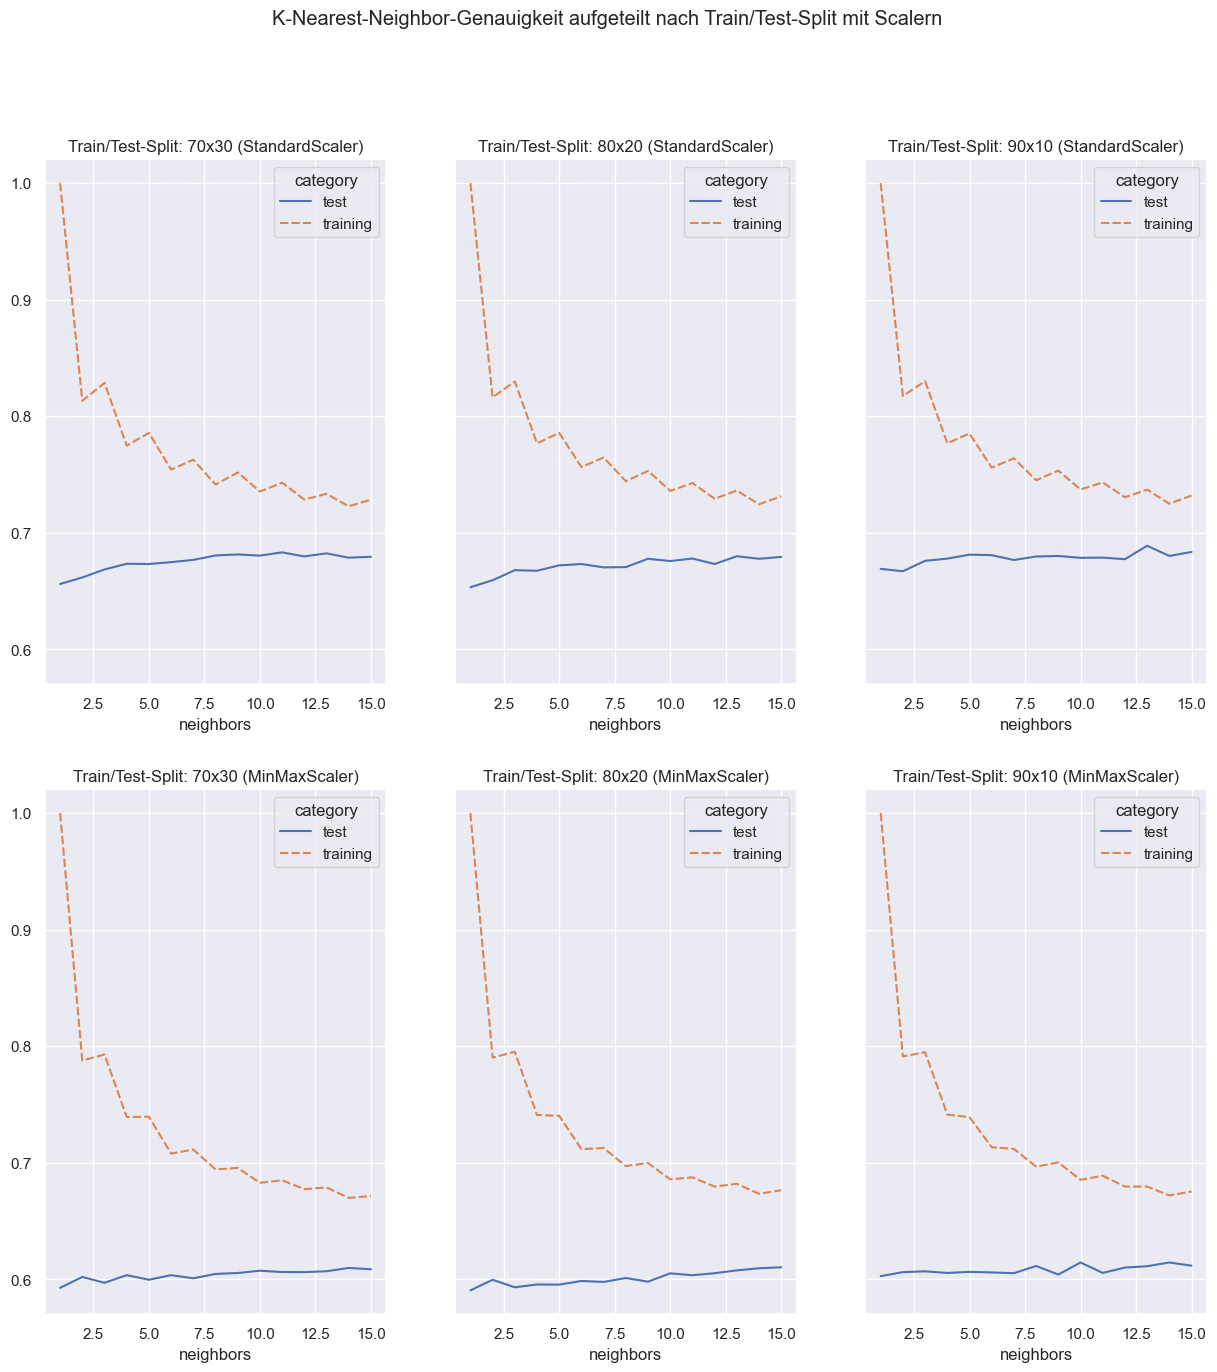

In [92]:
# Iterieren durch KNN-Modelle mit Neighbors = 1-15 und verschiedenen Train/Test-Splits mit StandardScaler
fig_knn_sc, axes_knn_sc = plt.subplots(2,3,figsize=(15,15), sharey=True)
fig_knn_sc.suptitle("K-Nearest-Neighbor-Genauigkeit aufgeteilt nach Train/Test-Split mit Scalern")

knnframe_8020_ssc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train1_SSc,y_train1)
    y_train_pred = knn_model.predict(X_train1_SSc)
    y_pred = knn_model.predict(X_test1_SSc)

    counter = counter + 1
    knnframe_8020_ssc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train1, y_train_pred)})
    counter = counter + 1
    knnframe_8020_ssc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test1, y_pred)})

knnframe_8020_ssc_pivot = knnframe_8020_ssc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_sc[0][1], data=knnframe_8020_ssc_pivot)
axes_knn_sc[0][1].set_title("Train/Test-Split: 80x20 (StandardScaler)")


knnframe_7030_ssc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train2_SSc,y_train2)
    y_train_pred = knn_model.predict(X_train2_SSc)
    y_pred = knn_model.predict(X_test2_SSc)

    counter = counter + 1
    knnframe_7030_ssc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train2, y_train_pred)})
    counter = counter + 1
    knnframe_7030_ssc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test2, y_pred)})

knnframe_7030_ssc_pivot = knnframe_7030_ssc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_sc[0][0], data=knnframe_7030_ssc_pivot)
axes_knn_sc[0][0].set_title("Train/Test-Split: 70x30 (StandardScaler)")


knnframe_9010_ssc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train3_SSc,y_train3)
    y_train_pred = knn_model.predict(X_train3_SSc)
    y_pred = knn_model.predict(X_test3_SSc)

    counter = counter + 1
    knnframe_9010_ssc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train3, y_train_pred)})
    counter = counter + 1
    knnframe_9010_ssc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test3, y_pred)})

knnframe_9010_ssc_pivot = knnframe_9010_ssc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_sc[0][2], data=knnframe_9010_ssc_pivot)
axes_knn_sc[0][2].set_title("Train/Test-Split: 90x10 (StandardScaler)")

# Iterieren durch KNN-Modelle mit Neighbors = 1-15 und verschiedenen Train/Test-Splits mit MinMaxScaler
knnframe_8020_msc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train1_MSc,y_train1)
    y_train_pred = knn_model.predict(X_train1_MSc)
    y_pred = knn_model.predict(X_test1_MSc)

    counter = counter + 1
    knnframe_8020_msc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train1, y_train_pred)})
    counter = counter + 1
    knnframe_8020_msc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test1, y_pred)})

knnframe_8020_msc_pivot = knnframe_8020_msc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_sc[1][1], data=knnframe_8020_msc_pivot)
axes_knn_sc[1][1].set_title("Train/Test-Split: 80x20 (MinMaxScaler)")


knnframe_7030_msc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train2_MSc,y_train2)
    y_train_pred = knn_model.predict(X_train2_MSc)
    y_pred = knn_model.predict(X_test2_MSc)

    counter = counter + 1
    knnframe_7030_msc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train2, y_train_pred)})
    counter = counter + 1
    knnframe_7030_msc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test2, y_pred)})

knnframe_7030_msc_pivot = knnframe_7030_msc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_sc[1][0], data=knnframe_7030_msc_pivot)
axes_knn_sc[1][0].set_title("Train/Test-Split: 70x30 (MinMaxScaler)")


knnframe_9010_msc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train3_MSc,y_train3)
    y_train_pred = knn_model.predict(X_train3_MSc)
    y_pred = knn_model.predict(X_test3_MSc)

    counter = counter + 1
    knnframe_9010_msc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train3, y_train_pred)})
    counter = counter + 1
    knnframe_9010_msc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test3, y_pred)})

knnframe_9010_msc_pivot = knnframe_9010_msc.pivot("neighbors", "category", "accuracy")
plt_knn_acc_sc = scn.lineplot(ax = axes_knn_sc[1][2], data=knnframe_9010_msc_pivot)
axes_knn_sc[1][2].set_title("Train/Test-Split: 90x10 (MinMaxScaler)")

fig_knn_acc_sc = plt_knn_acc_sc.get_figure()
fig_knn_acc_sc.savefig("KNN_Acc_Scaler")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_knnframe_8020_ssc = get_max_acc_frame_knn(knnframe_8020_ssc, "StandardScaler", "8020")
max_knnframe_7030_ssc = get_max_acc_frame_knn(knnframe_7030_ssc, "StandardScaler", "7030")
max_knnframe_9010_ssc = get_max_acc_frame_knn(knnframe_9010_ssc, "StandardScaler", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_knnframe_7030_ssc, max_knnframe_8020_ssc, max_knnframe_9010_ssc])
max_knn = pd.concat([max_knn, temp])
print(max_knn)

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_knnframe_8020_msc = get_max_acc_frame_knn(knnframe_8020_msc, "MinMaxScaler", "8020")
max_knnframe_7030_msc = get_max_acc_frame_knn(knnframe_7030_msc, "MinMaxScaler", "7030")
max_knnframe_9010_msc = get_max_acc_frame_knn(knnframe_9010_msc, "MinMaxScaler", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_knnframe_7030_msc, max_knnframe_8020_msc, max_knnframe_9010_msc])
max_knn = pd.concat([max_knn, temp])

display("StandardScaler - 8020")
display(knnframe_8020_ssc) 
display("StandardScaler - 7030")
display(knnframe_7030_ssc) 
display("StandardScaler - 9010")
display(knnframe_9010_ssc) 
display("MinMaxScaler - 8020")
display(knnframe_8020_msc) 
display("MinMaxScaler - 7030")
display(knnframe_7030_msc) 
display("MinMaxScaler - 9010")
display(knnframe_9010_msc) 

# Ergebnis KNN 

In [93]:
# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_knn = max_knn.reset_index()
max_knn["accuracy"] = pd.to_numeric(max_knn["accuracy"])
max_knn["train_accuracy"] = pd.to_numeric(max_knn["train_accuracy"])
max_knn["neighbors"] = pd.to_numeric(max_knn["neighbors"])
max_knn_max_id =  max_knn["accuracy"].idxmax()
max_knn_result = max_knn.iloc[max_knn_max_id]
display(max_knn_result)

# Bestes Ergebnis in DataFrame zur Endanalyse eintragen
temp = pd.DataFrame(columns=["modell_name", "category", "accuracy"])
temp.loc[1] = pd.Series({"modell_name": "KNN-" + str(max_knn_result["modell_cat"]) + "-" + str(max_knn_result["ratio"]) + "-" + str(max_knn_result["neighbors"]), "category": "test", "accuracy": max_knn_result["accuracy"]})
temp.loc[2] = pd.Series({"modell_name": "KNN-" + str(max_knn_result["modell_cat"]) + "-" + str(max_knn_result["ratio"]) + "-" + str(max_knn_result["neighbors"]), "category": "training", "accuracy": max_knn_result["train_accuracy"]})
max_acc = pd.concat([max_acc, temp])

index                    1
modell_cat        Standard
ratio                 9010
neighbors                1
accuracy          0.999079
train_accuracy         1.0
Name: 2, dtype: object

# KNN - Iterativ - Reduziert

'8020 - Reduziert'

,category,neighbors,accuracy
1,training,1,0.998014
2,test,1,0.569208
3,training,2,0.785807
4,test,2,0.591202
5,training,3,0.786267
6,test,3,0.582911
7,training,4,0.735541
8,test,4,0.598111
9,training,5,0.735080
10,test,5,0.587978


'7030 - Reduziert'

,category,neighbors,accuracy
1,training,1,0.998256
2,test,1,0.564793
3,training,2,0.787648
4,test,2,0.594580
5,training,3,0.785280
6,test,3,0.586980
7,training,4,0.734840
8,test,4,0.601336
9,training,5,0.733425
10,test,5,0.588285


'9010 - Reduziert'

,category,neighbors,accuracy
1,training,1,0.997850
2,test,1,0.572317
3,training,2,0.787548
4,test,2,0.595348
5,training,3,0.786038
6,test,3,0.583372
7,training,4,0.736571
8,test,4,0.600645
9,training,5,0.734806
10,test,5,0.595348


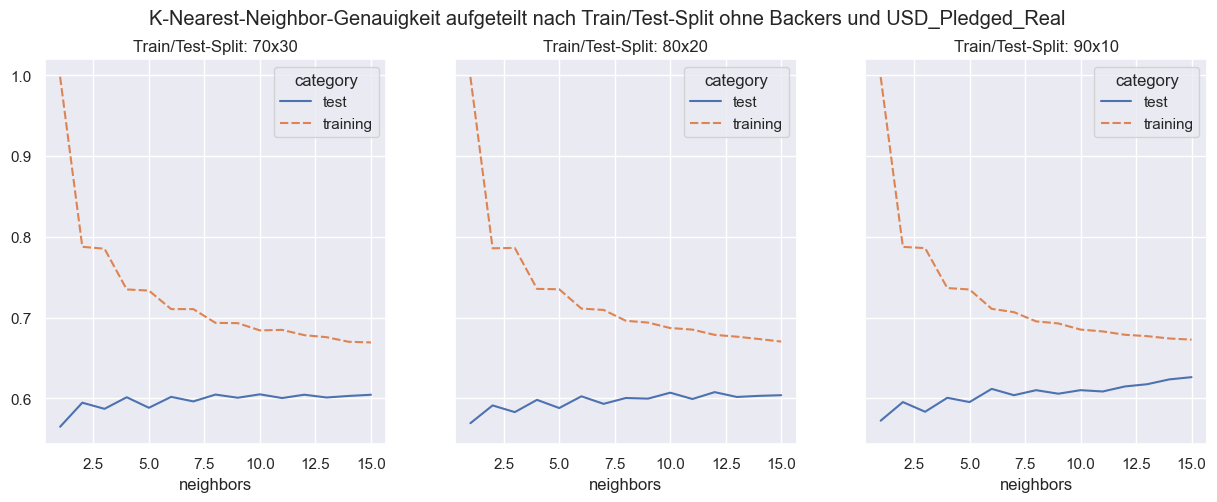

In [94]:
# Iterieren durch KNN-Modelle mit Neighbors = 1-15 und verschiedenen Train/Test-Splits (reduzierte Daten)
fig_knn_red, axes_knn_red = plt.subplots(1,3,figsize=(15,5), sharey=True)
fig_knn_red.suptitle("K-Nearest-Neighbor-Genauigkeit aufgeteilt nach Train/Test-Split ohne Backers und USD_Pledged_Real")

knnframe_8020_red = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train4,y_train4)
    y_train_pred = knn_model.predict(X_train4)
    y_pred = knn_model.predict(X_test4)

    counter = counter + 1
    knnframe_8020_red.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train4, y_train_pred)})
    counter = counter + 1
    knnframe_8020_red.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test4, y_pred)})

knnframe_8020_red_pivot = knnframe_8020_red.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_red[1], data=knnframe_8020_red_pivot)
axes_knn_red[1].set_title("Train/Test-Split: 80x20")

knnframe_7030_red = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train5,y_train5)
    y_train_pred = knn_model.predict(X_train5)
    y_pred = knn_model.predict(X_test5)

    counter = counter + 1
    knnframe_7030_red.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train5, y_train_pred)})
    counter = counter + 1
    knnframe_7030_red.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test5, y_pred)})

knnframe_7030_red_pivot = knnframe_7030_red.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_red[0], data=knnframe_7030_red_pivot)
axes_knn_red[0].set_title("Train/Test-Split: 70x30")


knnframe_9010_red = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train6,y_train6)
    y_train_pred = knn_model.predict(X_train6)
    y_pred = knn_model.predict(X_test6)

    counter = counter + 1
    knnframe_9010_red.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train6, y_train_pred)})
    counter = counter + 1
    knnframe_9010_red.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test6, y_pred)})

knnframe_9010_red_pivot = knnframe_9010_red.pivot("neighbors", "category", "accuracy")
plt_knn_red_acc = scn.lineplot(ax = axes_knn_red[2], data=knnframe_9010_red_pivot)
axes_knn_red[2].set_title("Train/Test-Split: 90x10")

fig_knn_red_acc = plt_knn_red_acc.get_figure()
fig_knn_red_acc.savefig("KNN_Red_Acc")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_knnframe_8020_red = get_max_acc_frame_knn(knnframe_8020_red, "Standard", "8020")
max_knnframe_7030_red = get_max_acc_frame_knn(knnframe_7030_red, "Standard", "7030")
max_knnframe_9010_red = get_max_acc_frame_knn(knnframe_9010_red, "Standard", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_knnframe_7030_red, max_knnframe_8020_red, max_knnframe_9010_red])
max_knn_red = pd.concat([max_knn_red, temp])

display("8020 - Reduziert")
display(knnframe_8020_red) 
display("7030 - Reduziert")
display(knnframe_7030_red) 
display("9010 - Reduziert")
display(knnframe_9010_red) 

# KNN - Iterativ - Reduziert - Scaler

  modell_cat ratio neighbors  accuracy train_accuracy
1   Standard  7030        10  0.604944       0.684105
1   Standard  8020        12  0.607669       0.678595
1   Standard  9010        15  0.626209       0.672672
1   Standard  7030        12  0.605712       0.673905
1   Standard  8020        14  0.605366       0.669526
1   Standard  9010        15  0.610318       0.669652


'StandardScaler - 8020 - Reduziert'

,category,neighbors,accuracy
1,training,1,0.998014
2,test,1,0.567826
3,training,2,0.788398
4,test,2,0.585790
5,training,3,0.786354
6,test,3,0.578190
7,training,4,0.739053
8,test,4,0.587632
9,training,5,0.731165
10,test,5,0.582566


'StandardScaler - 7030 - Reduziert'

,category,neighbors,accuracy
1,training,1,0.998256
2,test,1,0.571780
3,training,2,0.785938
4,test,2,0.589667
5,training,3,0.786661
6,test,3,0.583295
7,training,4,0.736058
8,test,4,0.592968
9,training,5,0.730727
10,test,5,0.587364


...

,category,neighbors,accuracy
1,training,1,0.998014
2,test,1,0.567826
3,training,2,0.788398
4,test,2,0.585790
5,training,3,0.786354
6,test,3,0.578190
7,training,4,0.739053
8,test,4,0.587632
9,training,5,0.731165
10,test,5,0.582566


'MinMaxScaler - 8020 - Reduziert'

,category,neighbors,accuracy
1,training,1,0.998256
2,test,1,0.571780
3,training,2,0.785938
4,test,2,0.589667
5,training,3,0.786661
6,test,3,0.583295
7,training,4,0.736058
8,test,4,0.592968
9,training,5,0.730727
10,test,5,0.587364


'MinMaxScaler - 8020 - Reduziert'

,category,neighbors,accuracy
1,training,1,0.997850
2,test,1,0.579917
3,training,2,0.788367
4,test,2,0.599033
5,training,3,0.784656
6,test,3,0.588899
7,training,4,0.736776
8,test,4,0.591893
9,training,5,0.731121
10,test,5,0.593275


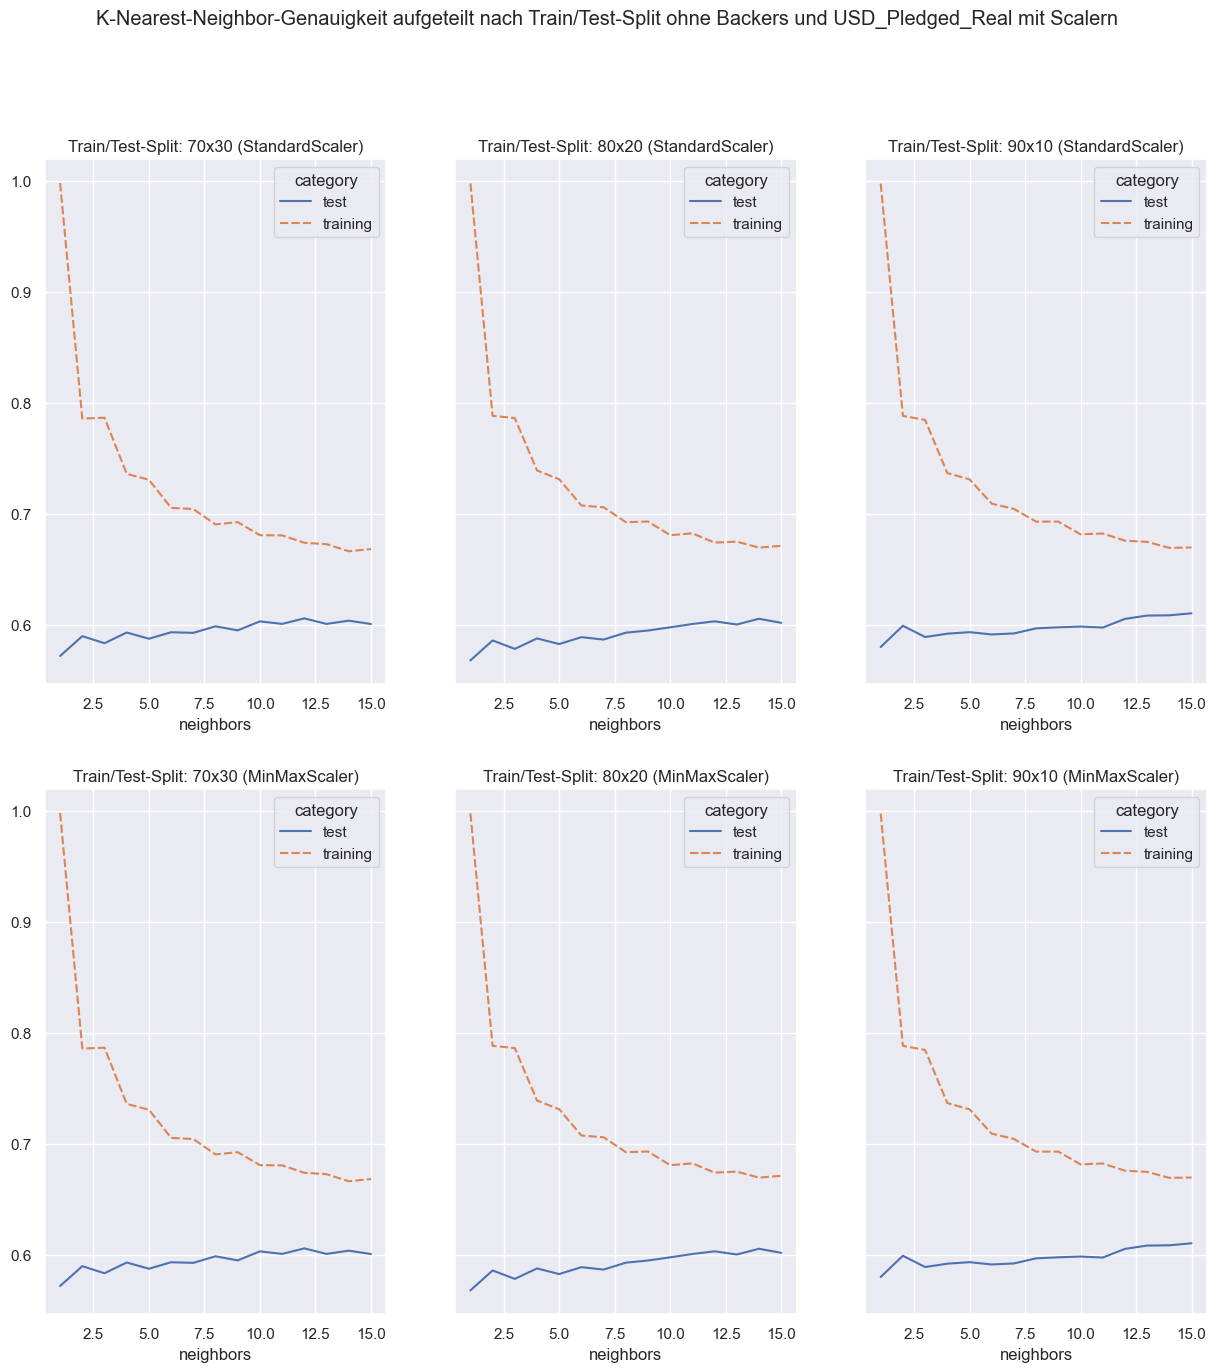

In [95]:
# Iterieren durch KNN-Modelle mit Neighbors = 1-15 und verschiedenen Train/Test-Splits mit StandardScaler (reduzierte Daten)
fig_knn_red_sc, axes_knn_red_sc = plt.subplots(2,3,figsize=(15,15), sharey=True)
fig_knn_red_sc.suptitle("K-Nearest-Neighbor-Genauigkeit aufgeteilt nach Train/Test-Split ohne Backers und USD_Pledged_Real mit Scalern")

knnframe_8020_red_ssc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train4_SSc,y_train4)
    y_train_pred = knn_model.predict(X_train4_SSc)
    y_pred = knn_model.predict(X_test4_SSc)

    counter = counter + 1
    knnframe_8020_red_ssc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train4, y_train_pred)})
    counter = counter + 1
    knnframe_8020_red_ssc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test4, y_pred)})

knnframe_8020_red_ssc_pivot = knnframe_8020_red_ssc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_red_sc[0][1], data=knnframe_8020_red_ssc_pivot)
axes_knn_red_sc[0][1].set_title("Train/Test-Split: 80x20 (StandardScaler)")


knnframe_7030_red_ssc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train5_SSc,y_train5)
    y_train_pred = knn_model.predict(X_train5_SSc)
    y_pred = knn_model.predict(X_test5_SSc)

    counter = counter + 1
    knnframe_7030_red_ssc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train5, y_train_pred)})
    counter = counter + 1
    knnframe_7030_red_ssc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test5, y_pred)})

knnframe_7030_red_ssc_pivot = knnframe_7030_red_ssc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_red_sc[0][0], data=knnframe_7030_red_ssc_pivot)
axes_knn_red_sc[0][0].set_title("Train/Test-Split: 70x30 (StandardScaler)")


knnframe_9010_red_ssc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train6_SSc,y_train6)
    y_train_pred = knn_model.predict(X_train6_SSc)
    y_pred = knn_model.predict(X_test6_SSc)

    counter = counter + 1
    knnframe_9010_red_ssc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train6, y_train_pred)})
    counter = counter + 1
    knnframe_9010_red_ssc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test6, y_pred)})

knnframe_9010_red_ssc_pivot = knnframe_9010_red_ssc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_red_sc[0][2], data=knnframe_9010_red_ssc_pivot)
axes_knn_red_sc[0][2].set_title("Train/Test-Split: 90x10 (StandardScaler)")

# Iterieren durch KNN-Modelle mit Neighbors = 1-15 und verschiedenen Train/Test-Splits mit MinMaxScaler (reduzierte Daten)

knnframe_8020_red_msc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train4_SSc,y_train4)
    y_train_pred = knn_model.predict(X_train4_SSc)
    y_pred = knn_model.predict(X_test4_SSc)

    counter = counter + 1
    knnframe_8020_red_msc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train4, y_train_pred)})
    counter = counter + 1
    knnframe_8020_red_msc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test4, y_pred)})

knnframe_8020_red_msc_pivot = knnframe_8020_red_msc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_red_sc[1][1], data=knnframe_8020_red_msc_pivot)
axes_knn_red_sc[1][1].set_title("Train/Test-Split: 80x20 (MinMaxScaler)")


knnframe_7030_red_msc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    nn_model = KNeighborsClassifier(n_neighbors=int(i))
    nn_model.fit(X_train5_SSc,y_train5)
    y_train_pred = nn_model.predict(X_train5_SSc)
    y_pred = nn_model.predict(X_test5_SSc)

    counter = counter + 1
    knnframe_7030_red_msc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train5, y_train_pred)})
    counter = counter + 1
    knnframe_7030_red_msc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test5, y_pred)})

knnframe_7030_red_msc_pivot = knnframe_7030_red_msc.pivot("neighbors", "category", "accuracy")
scn.lineplot(ax = axes_knn_red_sc[1][0], data=knnframe_7030_red_msc_pivot)
axes_knn_red_sc[1][0].set_title("Train/Test-Split: 70x30 (MinMaxScaler)")


knnframe_9010_red_msc = pd.DataFrame(columns=["category", "neighbors", "accuracy"])
counter = 0

for i in range(1,16):
    knn_model = KNeighborsClassifier(n_neighbors=int(i))
    knn_model.fit(X_train6_SSc,y_train6)
    y_train_pred = knn_model.predict(X_train6_SSc)
    y_pred = knn_model.predict(X_test6_SSc)

    counter = counter + 1
    knnframe_9010_red_msc.loc[counter] = pd.Series({"category": "training", "neighbors":int(i), "accuracy":accuracy_score(y_train6, y_train_pred)})
    counter = counter + 1
    knnframe_9010_red_msc.loc[counter] = pd.Series({"category": "test", "neighbors":int(i), "accuracy":accuracy_score(y_test6, y_pred)})

knnframe_9010_red_msc_pivot = knnframe_9010_red_msc.pivot("neighbors", "category", "accuracy")
plt_knn_red_acc_sc = scn.lineplot(ax = axes_knn_red_sc[1][2], data=knnframe_9010_red_msc_pivot)
axes_knn_red_sc[1][2].set_title("Train/Test-Split: 90x10 (MinMaxScaler)")

fig_knn_red_acc_sc = plt_knn_red_acc_sc.get_figure()
fig_knn_red_acc_sc.savefig("KNN_Red_Acc_Scaler")

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_knnframe_8020_red_ssc = get_max_acc_frame_knn(knnframe_8020_red_ssc, "Standard", "8020")
max_knnframe_7030_red_ssc = get_max_acc_frame_knn(knnframe_7030_red_ssc, "Standard", "7030")
max_knnframe_9010_red_ssc = get_max_acc_frame_knn(knnframe_9010_red_ssc, "Standard", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_knnframe_7030_red_ssc, max_knnframe_8020_red_ssc, max_knnframe_9010_red_ssc])
max_knn_red = pd.concat([max_knn_red, temp])
print(max_knn_red)

# Auswählen der Einträge mit höchster Test-Genauigkeit pro Train/Test-Split
max_knnframe_8020_red_msc = get_max_acc_frame_knn(knnframe_8020_red_msc, "Standard", "8020")
max_knnframe_7030_red_msc = get_max_acc_frame_knn(knnframe_7030_red_msc, "Standard", "7030")
max_knnframe_9010_red_msc = get_max_acc_frame_knn(knnframe_9010_red_msc, "Standard", "9010")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.concat([max_knnframe_7030_red_msc, max_knnframe_8020_red_msc, max_knnframe_9010_red_msc])
max_knn_red = pd.concat([max_knn_red, temp])

display("StandardScaler - 8020 - Reduziert")
display(knnframe_8020_red_ssc) 
display("StandardScaler - 7030 - Reduziert")
display(knnframe_7030_red_ssc) 
display("StandardScaler - 9010 - Reduziert")
display(knnframe_9010_red_ssc)
display("MinMaxScaler - 8020 - Reduziert")
display(knnframe_8020_red_msc) 
display("MinMaxScaler - 8020 - Reduziert")
display(knnframe_7030_red_msc) 
display("MinMaxScaler - 8020 - Reduziert")
display(knnframe_9010_red_msc)  

# Ergebnis KNN - Reduziert

In [96]:
# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_knn_red = max_knn_red.reset_index()
max_knn_red["accuracy"] = pd.to_numeric(max_knn_red["accuracy"])
max_knn_red["train_accuracy"] = pd.to_numeric(max_knn_red["train_accuracy"])
max_knn_red["neighbors"] = pd.to_numeric(max_knn_red["neighbors"])
max_knn_red_max_id =  max_knn_red["accuracy"].idxmax()
max_knn_red_result = max_knn_red.iloc[max_knn_red_max_id]
display(max_knn_red_result)

# Bestes Ergebnis in DataFrame zur Endanalyse eintragen
temp = pd.DataFrame(columns=["modell_name", "category", "accuracy"])
temp.loc[1] = pd.Series({"modell_name": "KNN-" + str(max_knn_red_result["modell_cat"]) + "-" + str(max_knn_red_result["ratio"]) + "-" + str(max_knn_red_result["neighbors"]), "category": "test", "accuracy": max_knn_red_result["accuracy"]})
temp.loc[2] = pd.Series({"modell_name": "KNN-" + str(max_knn_red_result["modell_cat"]) + "-" + str(max_knn_red_result["ratio"]) + "-" + str(max_knn_red_result["neighbors"]), "category": "training", "accuracy": max_knn_red_result["train_accuracy"]})
max_acc_red = pd.concat([max_acc_red, temp])

index                    1
modell_cat        Standard
ratio                 9010
neighbors               15
accuracy          0.626209
train_accuracy    0.672672
Name: 2, dtype: object

# Naive Bayes (NB)

In [97]:
# DataFrames zur Sammlung der besten Baummodelle für eine Zwischenanalyse
max_nb= pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
max_nb_red= pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])

# NB - Arten

In [98]:
nb_model_ga = GaussianNB()
nb_model_ga.fit(X_train4, y_train4)
y_pred_train_nb_ga = nb_model_ga.predict(X_train4)
y_pred_test_nb_ga = nb_model_ga.predict(X_test4)

display("Gaussian Naive Bayes:")
display("Genauigkeit Trainingsdaten: " + str(accuracy_score(y_train4, y_pred_train_nb_ga)))
display("Genauigkeit Testdaten: " + str(accuracy_score(y_test4, y_pred_test_nb_ga)))

nb_model_mul = MultinomialNB()
nb_model_mul.fit(X_train4, y_train4)
y_pred_train_nb_mul = nb_model_mul.predict(X_train4)
y_pred_test_nb_mul = nb_model_mul.predict(X_test4)

display("Multinominal Naive Bayes:")
display("Genauigkeit Trainingsdaten: " + str(accuracy_score(y_train4, y_pred_train_nb_mul)))
display("Genauigkeit Testdaten: " + str(accuracy_score(y_test4, y_pred_test_nb_mul)))

nb_model_com = ComplementNB()
nb_model_com.fit(X_train4, y_train4)
y_pred_train_nb_com = nb_model_com.predict(X_train4)
y_pred_test_nb_com = nb_model_com.predict(X_test4)

display("Complement Naive Bayes:")
display("Genauigkeit Trainingsdaten: " + str(accuracy_score(y_train4, y_pred_train_nb_com)))
display("Genauigkeit Testdaten: " + str(accuracy_score(y_test4, y_pred_test_nb_com)))

nb_model_cat = CategoricalNB()
nb_model_cat.fit(X_train4, y_train4)
y_pred_train_nb_cat = nb_model_cat.predict(X_train4)
y_pred_test_nb_cat = nb_model_cat.predict(X_test4)

display("Categorical Naive Bayes:")
display("Genauigkeit Trainingsdaten: " + str(accuracy_score(y_train4, y_pred_train_nb_cat)))
display("Genauigkeit Testdaten: " + str(accuracy_score(y_test4, y_pred_test_nb_cat)))

nb_model_ber = BernoulliNB()
nb_model_ber.fit(X_train4, y_train4)
y_pred_train_nb_ber = nb_model_ber.predict(X_train4)
y_pred_test_nb_ber = nb_model_ber.predict(X_test4)

display("Cateorical Naive Bayes:")
display("Genauigkeit Trainingsdaten: " + str(accuracy_score(y_train4, y_pred_train_nb_ber)))
display("Genauigkeit Testdaten: " + str(accuracy_score(y_test4, y_pred_test_nb_ber)))



'Gaussian Naive Bayes:'

'Genauigkeit Trainingsdaten: 0.4595652799769685'

'Genauigkeit Testdaten: 0.46936895439889453'

'Multinominal Naive Bayes:'

'Genauigkeit Trainingsdaten: 0.5172880380020153'

...

'Genauigkeit Trainingsdaten: 0.7231322873182668'

'Genauigkeit Testdaten: 0.6690465223399356'

'Cateorical Naive Bayes:'

'Genauigkeit Trainingsdaten: 0.5765942133294948'

'Genauigkeit Testdaten: 0.567710732381391'

# NB - Splits

In [99]:
# Modell erstellen 8020
nb_model_8020 = CategoricalNB()
nb_model_8020.fit(X_train1, y_train1)
y_pred_train_nb_8020 = nb_model_8020.predict(X_train1)
y_pred_test_nb_8020 = nb_model_8020.predict(X_test1)

# Modell erstellen 7030
nb_model_7030 = CategoricalNB()
nb_model_7030.fit(X_train2, y_train2)
y_pred_train_nb_7030 = nb_model_7030.predict(X_train2)
y_pred_test_nb_7030 = nb_model_7030.predict(X_test2)

# Modell erstellen 9010
nb_model_9010 = CategoricalNB()
nb_model_9010.fit(X_train3, y_train3)
y_pred_train_nb_9010 = nb_model_9010.predict(X_train3)
y_pred_test_nb_9010 = nb_model_9010.predict(X_test3)


# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
temp.loc[1] = pd.Series({"modell_cat":"Standard","ratio":"7030", "accuracy":  accuracy_score(y_test2, y_pred_test_nb_7030), "train_accuracy": accuracy_score(y_train2, y_pred_train_nb_7030)})
temp.loc[2] = pd.Series({"modell_cat":"Standard","ratio":"8020", "accuracy":  accuracy_score(y_test1, y_pred_test_nb_8020), "train_accuracy": accuracy_score(y_train1, y_pred_train_nb_8020)})
temp.loc[3] = pd.Series({"modell_cat":"Standard","ratio":"9010", "accuracy":  accuracy_score(y_test3, y_pred_test_nb_9010), "train_accuracy": accuracy_score(y_train3, y_pred_train_nb_9010)})
max_nb = pd.concat([max_nb, temp])


# Ausgabe 
display("8020")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test1, y_pred_test_nb_8020)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train1, y_pred_train_nb_8020)))
display("7030")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test2, y_pred_test_nb_7030)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train2, y_pred_train_nb_7030)))
display("9010")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test3, y_pred_test_nb_9010)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train3, y_pred_train_nb_9010)))


'8020'

'Genauigkeit der Testwerte: 0.8302625518194381'

'Genauigkeit der Testwerte: 0.8952353533899525'

'7030'

'Genauigkeit der Testwerte: 0.8228926761860894'

'Genauigkeit der Testwerte: 0.8966867370776166'

'9010'

'Genauigkeit der Testwerte: 0.8263473053892215'

'Genauigkeit der Testwerte: 0.8954116232054661'

# NB - Splits - Scaler

In [100]:
# StandardScaler wird übersprungen, da die negativne Werte nicht kompatibel sind mit Categorical-Naive-Bayes
# Modell erstellen 8020 mit MinMaxScaler
nb_model_8020_msc = CategoricalNB()
nb_model_8020_msc.fit(X_train1_MSc, y_train1)
y_pred_train_nb_8020_msc = nb_model_8020_msc.predict(X_train1_MSc)
y_pred_test_nb_8020_msc = nb_model_8020_msc.predict(X_test1_MSc)

# Modell erstellen 7030 mit MinMaxScaler
nb_model_7030_msc = CategoricalNB()
nb_model_7030_msc.fit(X_train2_MSc, y_train2)
y_pred_train_nb_7030_msc = nb_model_7030_msc.predict(X_train2_MSc)
y_pred_test_nb_7030_msc = nb_model_7030_msc.predict(X_test2_MSc)

# Modell erstellen 9010 mit MinMaxScaler
nb_model_9010_msc = CategoricalNB()
nb_model_9010_msc.fit(X_train3_MSc, y_train3)
y_pred_train_nb_9010_msc = nb_model_9010_msc.predict(X_train3_MSc)
y_pred_test_nb_9010_msc = nb_model_9010_msc.predict(X_test3_MSc)


# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
temp.loc[1] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"7030", "accuracy":  accuracy_score(y_test2, y_pred_test_nb_7030_msc), "train_accuracy": accuracy_score(y_train2, y_pred_train_nb_7030_msc)})
temp.loc[2] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"8020", "accuracy":  accuracy_score(y_test1, y_pred_test_nb_8020_msc), "train_accuracy": accuracy_score(y_train1, y_pred_train_nb_8020_msc)})
temp.loc[3] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"9010", "accuracy":  accuracy_score(y_test3, y_pred_test_nb_9010_msc), "train_accuracy": accuracy_score(y_train3, y_pred_train_nb_9010_msc)})
max_nb = pd.concat([max_nb, temp])


# Ausgabe 
display("8020")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test1, y_pred_test_nb_8020_msc)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train1, y_pred_train_nb_8020_msc)))
display("7030")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test2, y_pred_test_nb_7030_msc)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train2, y_pred_train_nb_7030_msc)))
display("9010")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test3, y_pred_test_nb_9010_msc)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train3, y_pred_train_nb_9010_msc)))

'8020'

'Genauigkeit der Testwerte: 0.5726623675725472'

'Genauigkeit der Testwerte: 0.5808550453433137'

'7030'

'Genauigkeit der Testwerte: 0.5756947643175188'

'Genauigkeit der Testwerte: 0.5807258250254993'

'9010'

'Genauigkeit der Testwerte: 0.5727775218793183'

'Genauigkeit der Testwerte: 0.5799319292678558'

# Ergebnis NB

In [101]:
# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_nb = max_nb.reset_index()
max_nb["accuracy"] = pd.to_numeric(max_nb["accuracy"])
max_nb["train_accuracy"] = pd.to_numeric(max_nb["train_accuracy"])
max_nb_max_id =  max_nb["accuracy"].idxmax()
max_nb_result = max_nb.iloc[max_nb_max_id]
display(max_nb_result)

# Bestes Ergebnis in DataFrame zur Endanalyse eintragen
temp = pd.DataFrame(columns=["modell_name", "category", "accuracy"])
temp.loc[1] = pd.Series({"modell_name": "NB-Categorical-" + str(max_nb_result["modell_cat"]) + "-" + str(max_nb_result["ratio"]), "category": "test", "accuracy": max_nb_result["accuracy"]})
temp.loc[2] = pd.Series({"modell_name": "NB-Categorical-" + str(max_nb_result["modell_cat"]) + "-" + str(max_nb_result["ratio"]), "category": "training", "accuracy": max_nb_result["train_accuracy"]})
max_acc = pd.concat([max_acc, temp])

index                    2
modell_cat        Standard
ratio                 8020
accuracy          0.830263
train_accuracy    0.895235
Name: 1, dtype: object

# NB - Splits - Reduziert

In [102]:
# Modell erstellen 8020 - ohne Backers und USD_Pledged_Real
nb_model_8020_red = CategoricalNB()
nb_model_8020_red.fit(X_train4, y_train4)
y_pred_train_nb_8020_red = nb_model_8020_red.predict(X_train4)
y_pred_test_nb_8020_red = nb_model_8020_red.predict(X_test4)

# Modell erstellen 7030 - ohne Backers und USD_Pledged_Real
nb_model_7030_red = CategoricalNB()
nb_model_7030_red.fit(X_train5, y_train5)
y_pred_train_nb_7030_red = nb_model_7030_red.predict(X_train5)
y_pred_test_nb_7030_red = nb_model_7030_red.predict(X_test5)

# Modell erstellen 9010 - ohne Backers und USD_Pledged_Real
nb_model_9010_red = CategoricalNB()
nb_model_9010_red.fit(X_train6, y_train6)
y_pred_train_nb_9010_red = nb_model_9010_red.predict(X_train6)
y_pred_test_nb_9010_red = nb_model_9010_red.predict(X_test6)


# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
temp.loc[1] = pd.Series({"modell_cat":"Standard","ratio":"7030", "accuracy":  accuracy_score(y_test5, y_pred_test_nb_7030_red), "train_accuracy": accuracy_score(y_train5, y_pred_train_nb_7030_red)})
temp.loc[2] = pd.Series({"modell_cat":"Standard","ratio":"8020", "accuracy":  accuracy_score(y_test4, y_pred_test_nb_8020_red), "train_accuracy": accuracy_score(y_train4, y_pred_train_nb_8020_red)})
temp.loc[3] = pd.Series({"modell_cat":"Standard","ratio":"9010", "accuracy":  accuracy_score(y_test6, y_pred_test_nb_9010_red), "train_accuracy": accuracy_score(y_train6, y_pred_train_nb_9010_red)})
max_nb_red = pd.concat([max_nb_red, temp])


# Ausgabe 
display("8020 - Reduziert")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test4, y_pred_test_nb_8020_red)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train4, y_pred_train_nb_8020_red)))
display("7030 - Reduziert")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test5, y_pred_test_nb_7030_red)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train5, y_pred_train_nb_7030_red)))
display("9010 - Reduziert")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test6, y_pred_test_nb_9010_red)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train6, y_pred_train_nb_9010_red)))

'8020 - Reduziert'

'Genauigkeit der Testwerte: 0.6690465223399356'

'Genauigkeit der Testwerte: 0.7231322873182668'

'7030 - Reduziert'

'Genauigkeit der Testwerte: 0.671349608475357'

'Genauigkeit der Testwerte: 0.7242457144737275'

'9010 - Reduziert'

'Genauigkeit der Testwerte: 0.6759557807461999'

'Genauigkeit der Testwerte: 0.720935588709471'

# NB - Splits - Reduziert - Scaler

In [103]:
# StandardScaler wird übersprungen, da die negativne Werte nicht kompatibel sind mit Categorical-Naive-Bayes
# Modell erstellen 8020 - ohne Backers und USD_Pledged_Real mit MinMaxScaler
nb_model_8020_red_msc = CategoricalNB()
nb_model_8020_red_msc.fit(X_train4_MSc, y_train4)
y_pred_train_nb_8020_red_msc = nb_model_8020_red_msc.predict(X_train4_MSc)
y_pred_test_nb_8020_red_msc = nb_model_8020_red_msc.predict(X_test4_MSc)

# Modell erstellen 7030 - ohne Backers und USD_Pledged_Real mit MinMaxScaler
nb_model_7030_red_msc = CategoricalNB()
nb_model_7030_red_msc.fit(X_train5_MSc, y_train5)
y_pred_train_nb_7030_red_msc = nb_model_7030_red_msc.predict(X_train5_MSc)
y_pred_test_nb_7030_red_msc = nb_model_7030_red_msc.predict(X_test5_MSc)

# Modell erstellen 9010 - ohne Backers und USD_Pledged_Real mit MinMaxScaler
nb_model_9010_red_msc = CategoricalNB()
nb_model_9010_red_msc.fit(X_train6_MSc, y_train6)
y_pred_train_nb_9010_red_msc = nb_model_9010_red_msc.predict(X_train6_MSc)
y_pred_test_nb_9010_red_msc = nb_model_9010_red_msc.predict(X_test6_MSc)


# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
temp.loc[1] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"7030", "accuracy":  accuracy_score(y_test5, y_pred_test_nb_7030_red_msc), "train_accuracy": accuracy_score(y_train5, y_pred_train_nb_7030_red_msc)})
temp.loc[2] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"8020", "accuracy":  accuracy_score(y_test4, y_pred_test_nb_8020_red_msc), "train_accuracy": accuracy_score(y_train4, y_pred_train_nb_8020_red_msc)})
temp.loc[3] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"9010", "accuracy":  accuracy_score(y_test6, y_pred_test_nb_9010_red_msc), "train_accuracy": accuracy_score(y_train6, y_pred_train_nb_9010_red_msc)})
max_nb_red = pd.concat([max_nb_red, temp])


# Ausgabe 
display("8020 - Reduziert - MinMaxScaler")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test4, y_pred_test_nb_8020_red_msc)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train4, y_pred_train_nb_8020_red_msc)))
display("7030 - Reduziert - MinMaxScaler")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test5, y_pred_test_nb_7030_red_msc)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train5, y_pred_train_nb_7030_red_msc)))
display("9010 - Reduziert - MinMaxScaler")
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_test6, y_pred_test_nb_9010_red_msc)))
display("Genauigkeit der Testwerte: " + str(accuracy_score(y_train6, y_pred_train_nb_9010_red_msc)))

'8020 - Reduziert - MinMaxScaler'

'Genauigkeit der Testwerte: 0.5726623675725472'

'Genauigkeit der Testwerte: 0.5808262559378149'

'7030 - Reduziert - MinMaxScaler'

'Genauigkeit der Testwerte: 0.5756947643175188'

'Genauigkeit der Testwerte: 0.5806929227124666'

'9010 - Reduziert - MinMaxScaler'

'Genauigkeit der Testwerte: 0.5727775218793183'

'Genauigkeit der Testwerte: 0.5799063387670497'

# Ergebnis NB - Reduziert

In [104]:
# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_nb_red = max_nb_red.reset_index()
max_nb_red["accuracy"] = pd.to_numeric(max_nb_red["accuracy"])
max_nb_red["train_accuracy"] = pd.to_numeric(max_nb_red["train_accuracy"])
max_nb_max_id_red =  max_nb_red["accuracy"].idxmax()
max_nb_result_red = max_nb_red.iloc[max_nb_max_id_red]
display(max_nb_result_red)

# Bestes Ergebnis in DataFrame zur Endanalyse eintragen
temp = pd.DataFrame(columns=["modell_name", "category", "accuracy"])
temp.loc[1] = pd.Series({"modell_name": "NB-Categorical-" + str(max_nb_result_red["modell_cat"]) + "-" + str(max_nb_result_red["ratio"]), "category": "test", "accuracy": max_nb_result_red["accuracy"]})
temp.loc[2] = pd.Series({"modell_name": "NB-Categorical-" + str(max_nb_result_red["modell_cat"]) + "-" + str(max_nb_result_red["ratio"]), "category": "training", "accuracy": max_nb_result_red["train_accuracy"]})
max_acc_red = pd.concat([max_acc_red, temp])

index                    3
modell_cat        Standard
ratio                 9010
accuracy          0.675956
train_accuracy    0.720936
Name: 2, dtype: object

# Neural Network (NN)

In [105]:
# DataFrames zur Sammlung der besten Baummodelle für eine Zwischenanalyse
max_nn= pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
max_nn_red= pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])

# NN - Aktivierungsfunktion

272/272 [==============================] - 0s 1ms/step - loss: 3.6091 - accuracy: 0.6047


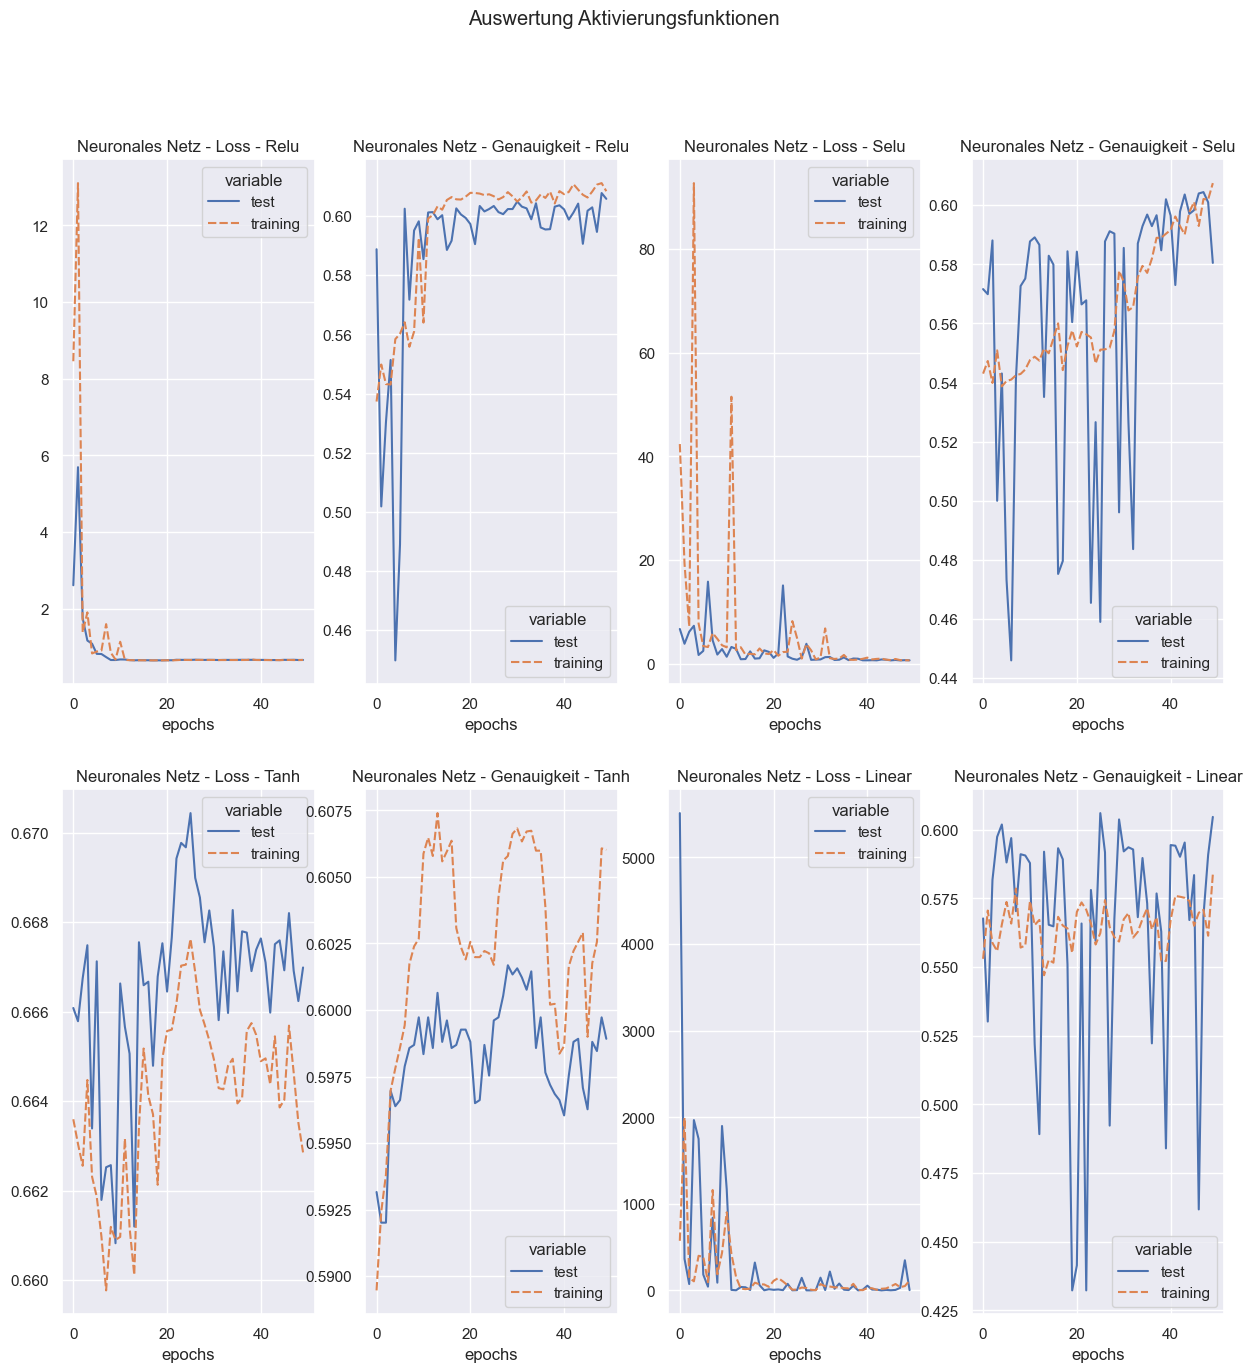

In [106]:
# Modellerstellung
nn_model_relu = Sequential()

nn_model_relu.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_relu.add(Dense(20, activation="relu", name="layer1"))
nn_model_relu.add(Dense(40, activation="relu", name="layer2"))
nn_model_relu.add(Dense(15, activation="relu", name="layer3"))
nn_model_relu.add(Dense(1, activation="sigmoid", name="result"))
nn_model_relu.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_relu = nn_model_relu.fit(X_train4, y_train4, epochs=50, batch_size=100, validation_data=(X_test4, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_relu = nn_model_relu.evaluate(X_train4, y_train4)
nn_result_test_relu = nn_model_relu.evaluate(X_test4, y_test4)

auswertung_relu = pd.DataFrame.from_dict(hist_relu.history) 

# Modellerstellung
nn_model_selu = Sequential()

nn_model_selu.add(Dense(10, input_dim=X2.shape[1], activation="selu", name="input"))
nn_model_selu.add(Dense(20, activation="selu", name="layer1"))
nn_model_selu.add(Dense(40, activation="selu", name="layer2"))
nn_model_selu.add(Dense(15, activation="selu", name="layer3"))
nn_model_selu.add(Dense(1, activation="sigmoid", name="result"))
nn_model_selu.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_selu = nn_model_selu.fit(X_train4, y_train4, epochs=50, batch_size=100, validation_data=(X_test4, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_selu = nn_model_selu.evaluate(X_train4, y_train4)
nn_result_test_selu = nn_model_selu.evaluate(X_test4, y_test4)

auswertung_selu = pd.DataFrame.from_dict(hist_selu.history) 

# Modellerstellung
nn_model_tanh = Sequential()

nn_model_tanh.add(Dense(10, input_dim=X2.shape[1], activation="tanh", name="input"))
nn_model_tanh.add(Dense(20, activation="tanh", name="layer1"))
nn_model_tanh.add(Dense(40, activation="tanh", name="layer2"))
nn_model_tanh.add(Dense(15, activation="tanh", name="layer3"))
nn_model_tanh.add(Dense(1, activation="sigmoid", name="result"))
nn_model_tanh.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_tanh = nn_model_tanh.fit(X_train4, y_train4, epochs=50, batch_size=100, validation_data=(X_test4,y_test4), verbose=0)

# Modellevaluierung
nn_result_train_tanh = nn_model_tanh.evaluate(X_train4, y_train4)
nn_result_test_tanh = nn_model_tanh.evaluate(X_test4, y_test4)

auswertung_tanh = pd.DataFrame.from_dict(hist_tanh.history) 

# Modellerstellung
nn_model_linear = Sequential()

nn_model_linear.add(Dense(10, input_dim=X2.shape[1], activation="linear", name="input"))
nn_model_linear.add(Dense(20, activation="linear", name="layer1"))
nn_model_linear.add(Dense(40, activation="linear", name="layer2"))
nn_model_linear.add(Dense(15, activation="linear", name="layer3"))
nn_model_linear.add(Dense(1, activation="sigmoid", name="result"))
nn_model_linear.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_linear = nn_model_linear.fit(X_train4, y_train4, epochs=50, batch_size=100, validation_data=(X_test4,y_test4), verbose=0)

# Modellevaluierung
nn_result_train_linear = nn_model_linear.evaluate(X_train4, y_train4)
nn_result_test_linear = nn_model_linear.evaluate(X_test4, y_test4)

auswertung_linear = pd.DataFrame.from_dict(hist_linear.history) 

# Plot erstellen
fig_nn_af, axes_nn_af = plt.subplots(2,4,figsize=(15,15), sharey=False)
fig_nn_af.suptitle("Auswertung Aktivierungsfunktionen")

# Grafische Ausgabe
auswertung_relu["epochs"] = auswertung_relu.index
auswertung_relu_loss = auswertung_relu.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_relu_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_relu_accuracy = auswertung_relu.drop(["loss", "val_loss"], axis=1)
auswertung_relu_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_relu_loss = pd.melt(auswertung_relu_loss, ["epochs"])
auswertung_relu_accuracy = pd.melt(auswertung_relu_accuracy, ["epochs"])
auswertung_relu_loss = auswertung_relu_loss.pivot("epochs", "variable", "value")
auswertung_relu_accuracy = auswertung_relu_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_af[0][0], data=auswertung_relu_loss)
axes_nn_af[0][0].set_title("Neuronales Netz - Loss - Relu")
scn.lineplot(ax=axes_nn_af[0][1], data=auswertung_relu_accuracy)
axes_nn_af[0][1].set_title("Neuronales Netz - Genauigkeit - Relu")

auswertung_selu["epochs"] = auswertung_selu.index
auswertung_selu_loss = auswertung_selu.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_selu_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_selu_accuracy = auswertung_selu.drop(["loss", "val_loss"], axis=1)
auswertung_selu_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_selu_loss = pd.melt(auswertung_selu_loss, ["epochs"])
auswertung_selu_accuracy = pd.melt(auswertung_selu_accuracy, ["epochs"])
auswertung_selu_loss = auswertung_selu_loss.pivot("epochs", "variable", "value")
auswertung_selu_accuracy = auswertung_selu_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_af[0][2], data=auswertung_selu_loss)
axes_nn_af[0][2].set_title("Neuronales Netz - Loss - Selu")
scn.lineplot(ax=axes_nn_af[0][3], data=auswertung_selu_accuracy)
axes_nn_af[0][3].set_title("Neuronales Netz - Genauigkeit - Selu")

auswertung_tanh["epochs"] = auswertung_tanh.index
auswertung_tanh_loss = auswertung_tanh.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_tanh_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_tanh_accuracy = auswertung_tanh.drop(["loss", "val_loss"], axis=1)
auswertung_tanh_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_tanh_loss = pd.melt(auswertung_tanh_loss, ["epochs"])
auswertung_tanh_accuracy = pd.melt(auswertung_tanh_accuracy, ["epochs"])
auswertung_tanh_loss = auswertung_tanh_loss.pivot("epochs", "variable", "value")
auswertung_tanh_accuracy = auswertung_tanh_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_af[1][0], data=auswertung_tanh_loss)
axes_nn_af[1][0].set_title("Neuronales Netz - Loss - Tanh")
scn.lineplot(ax=axes_nn_af[1][1], data=auswertung_tanh_accuracy)
axes_nn_af[1][1].set_title("Neuronales Netz - Genauigkeit - Tanh")

auswertung_linear["epochs"] = auswertung_linear.index
auswertung_linear_loss = auswertung_linear.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_linear_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_linear_accuracy = auswertung_linear.drop(["loss", "val_loss"], axis=1)
auswertung_linear_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_linear_loss = pd.melt(auswertung_linear_loss, ["epochs"])
auswertung_linear_accuracy = pd.melt(auswertung_linear_accuracy, ["epochs"])
auswertung_linear_loss = auswertung_linear_loss.pivot("epochs", "variable", "value")
auswertung_linear_accuracy = auswertung_linear_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_af[1][2], data=auswertung_linear_loss)
axes_nn_af[1][2].set_title("Neuronales Netz - Loss - Linear")
plt_nn_af = scn.lineplot(ax=axes_nn_af[1][3], data=auswertung_linear_accuracy)
axes_nn_af[1][3].set_title("Neuronales Netz - Genauigkeit - Linear")

fig_nn_af = plt_nn_af.get_figure()
fig_nn_af.savefig("NN_ActivationFunctionsTest")

# NN -  Weitere Parameter

272/272 [==============================] - 0s 983us/step - loss: 0.6650 - accuracy: 0.5981


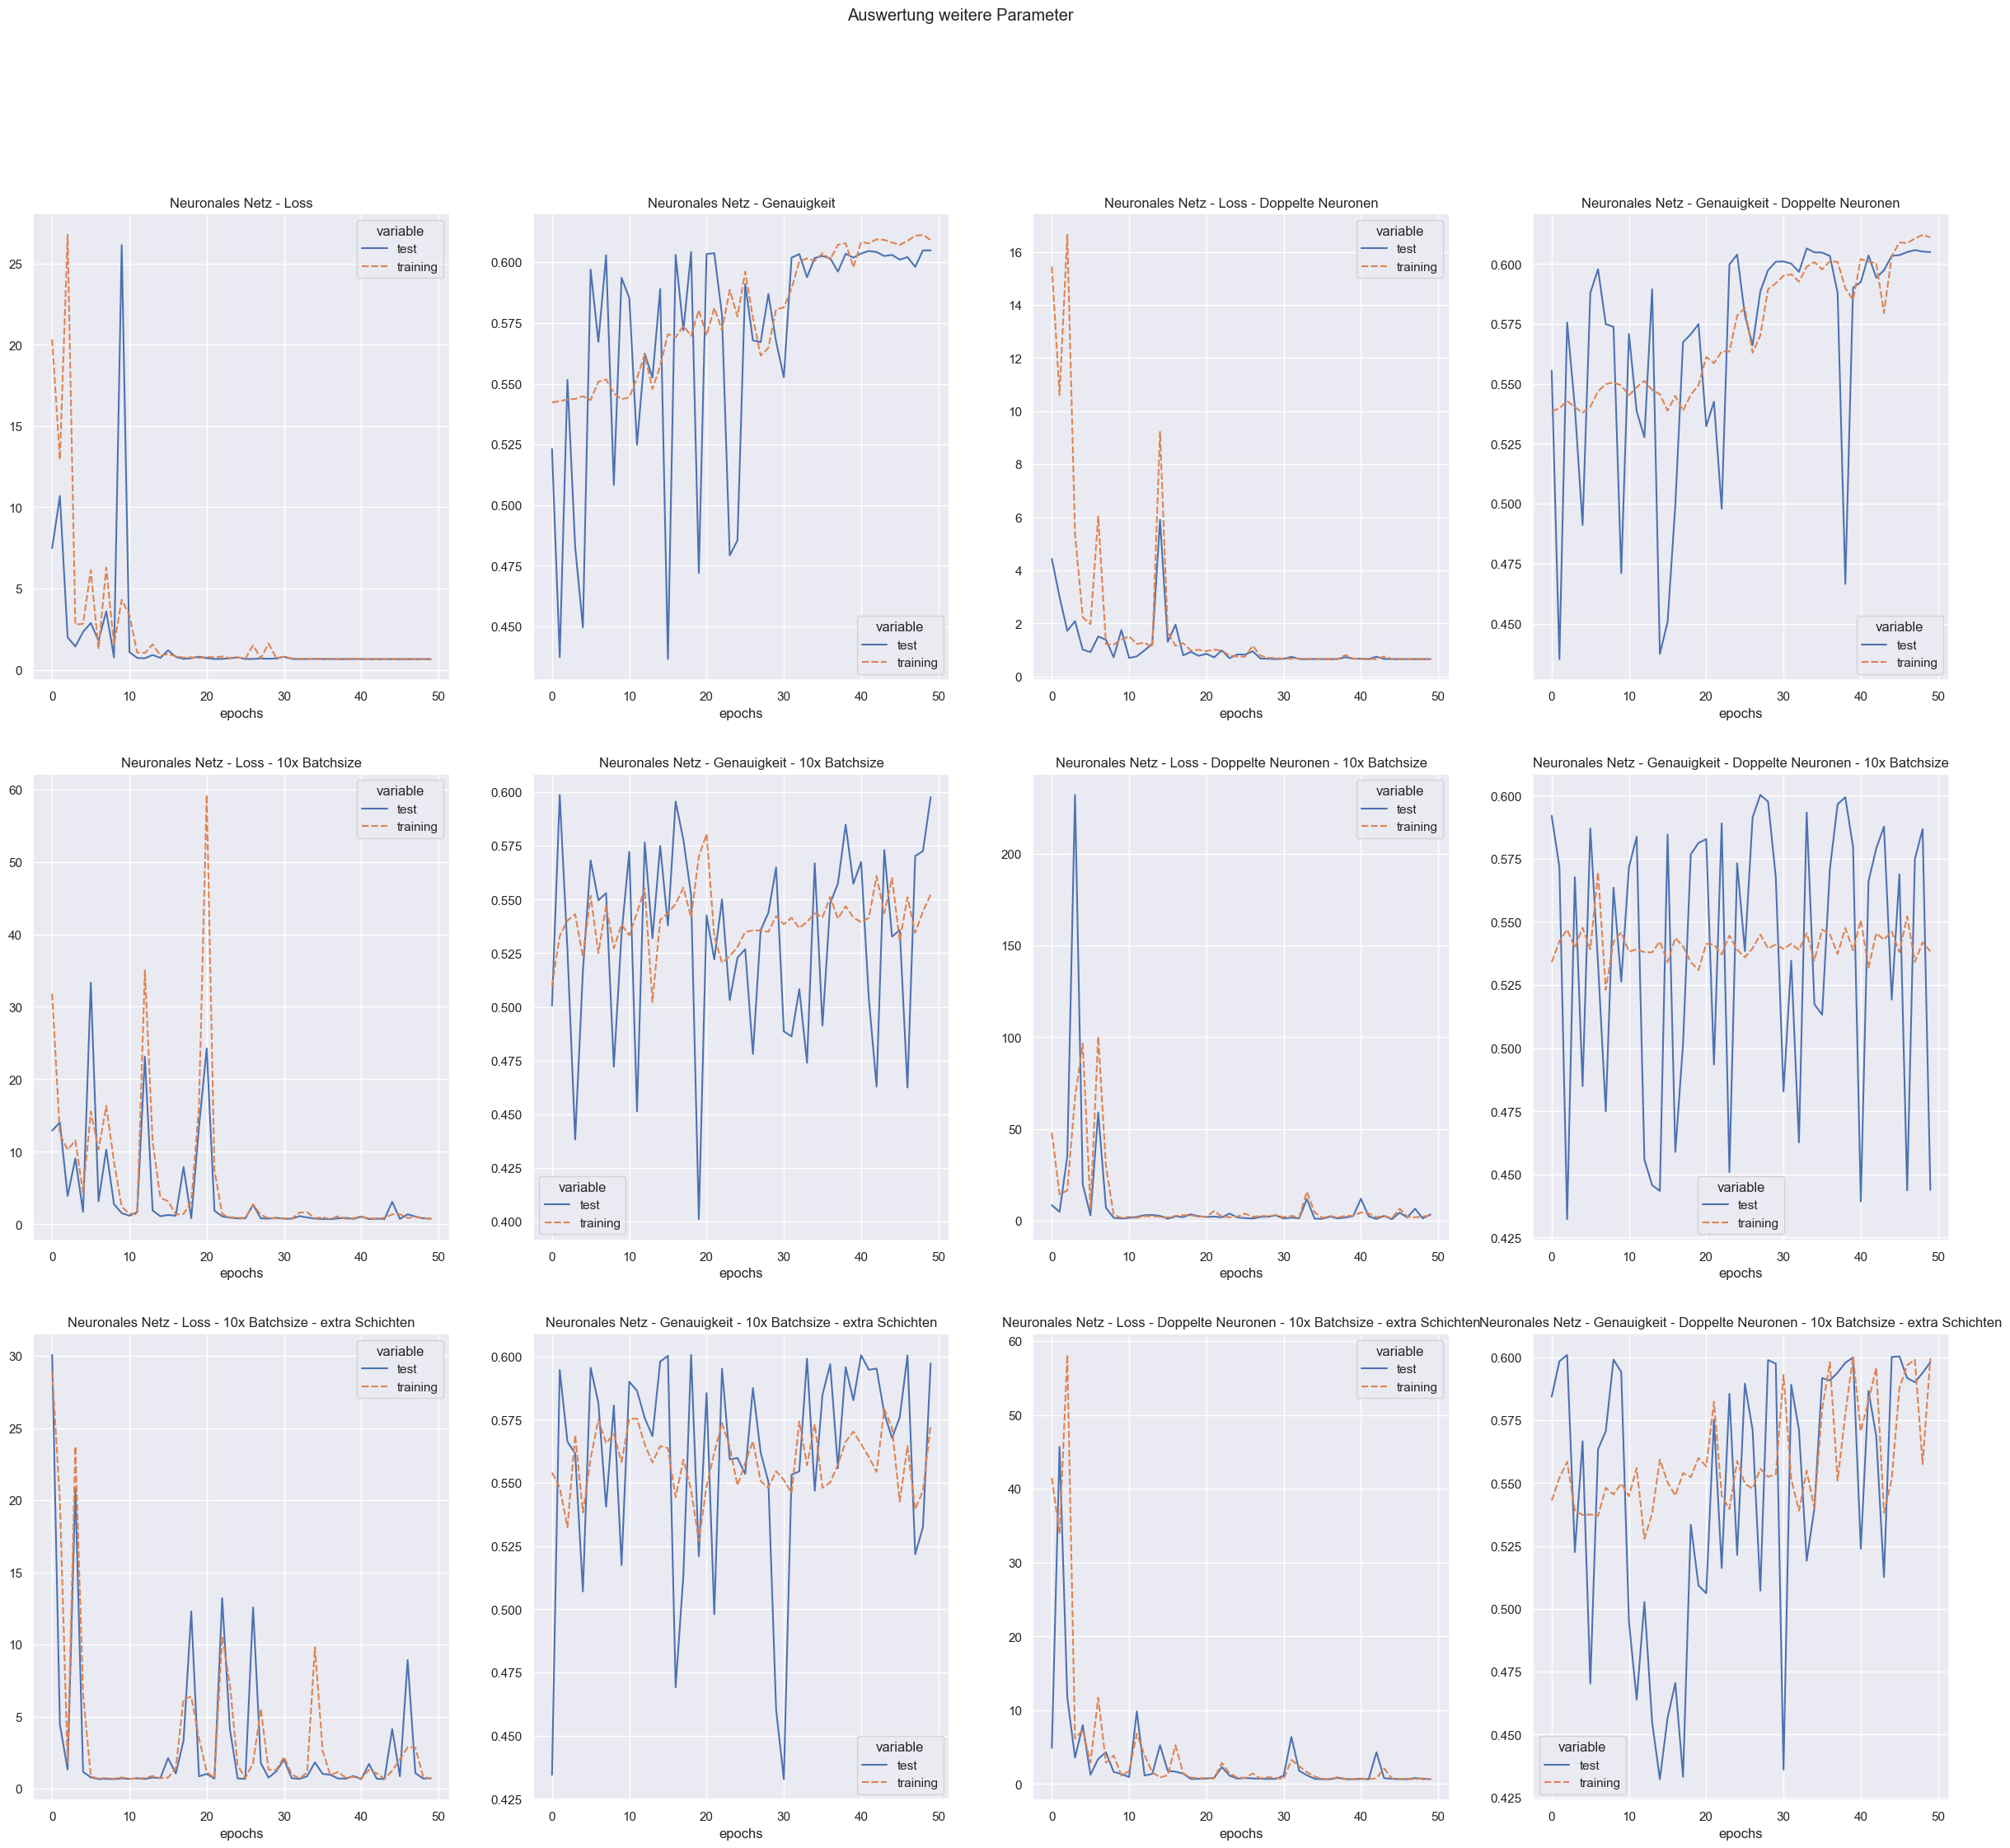

In [107]:
# Modellerstellung
nn_model_reg1 = Sequential()

nn_model_reg1.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_reg1.add(Dense(20, activation="relu", name="layer1"))
nn_model_reg1.add(Dense(40, activation="relu", name="layer2"))
nn_model_reg1.add(Dense(15, activation="relu", name="layer3"))
nn_model_reg1.add(Dense(1, activation="sigmoid", name="result"))
nn_model_reg1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_reg1 = nn_model_reg1.fit(X_train4, y_train4, epochs=50, batch_size=100, validation_data=(X_test4, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_reg1 = nn_model_reg1.evaluate(X_train4, y_train4)
nn_result_test_reg1 = nn_model_reg1.evaluate(X_test4, y_test4)

auswertung_reg1 = pd.DataFrame.from_dict(hist_reg1.history)

# Modellerstellung
nn_model_reg2 = Sequential()

nn_model_reg2.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_reg2.add(Dense(40, activation="relu", name="layer1"))
nn_model_reg2.add(Dense(80, activation="relu", name="layer2"))
nn_model_reg2.add(Dense(30, activation="relu", name="layer3"))
nn_model_reg2.add(Dense(1, activation="sigmoid", name="result"))
nn_model_reg2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_reg2 = nn_model_reg2.fit(X_train4, y_train4, epochs=50, batch_size=100, validation_data=(X_test4, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_reg2 = nn_model_reg2.evaluate(X_train4, y_train4)
nn_result_test_reg2 = nn_model_reg2.evaluate(X_test4, y_test4)

auswertung_reg2 = pd.DataFrame.from_dict(hist_reg2.history)

# Modellerstellung
nn_model_reg3 = Sequential()

nn_model_reg3.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_reg3.add(Dense(20, activation="relu", name="layer1"))
nn_model_reg3.add(Dense(40, activation="relu", name="layer2"))
nn_model_reg3.add(Dense(15, activation="relu", name="layer3"))
nn_model_reg3.add(Dense(1, activation="sigmoid", name="result"))
nn_model_reg3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_reg3 = nn_model_reg3.fit(X_train4, y_train4, epochs=50, batch_size=1000, validation_data=(X_test4, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_reg3 = nn_model_reg3.evaluate(X_train4, y_train4)
nn_result_test_reg3 = nn_model_reg3.evaluate(X_test4, y_test4)

auswertung_reg3 = pd.DataFrame.from_dict(hist_reg3.history)

# Modellerstellung
nn_model_reg4 = Sequential()

nn_model_reg4.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_reg4.add(Dense(40, activation="relu", name="layer1"))
nn_model_reg4.add(Dense(80, activation="relu", name="layer2"))
nn_model_reg4.add(Dense(30, activation="relu", name="layer3"))
nn_model_reg4.add(Dense(1, activation="sigmoid", name="result"))
nn_model_reg4.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_reg4 = nn_model_reg4.fit(X_train4, y_train4, epochs=50, batch_size=1000, validation_data=(X_test4, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_reg4 = nn_model_reg4.evaluate(X_train4, y_train4)
nn_result_test_reg4 = nn_model_reg4.evaluate(X_test4, y_test4)

auswertung_reg4 = pd.DataFrame.from_dict(hist_reg4.history)

# Modellerstellung
nn_model_reg5 = Sequential()

nn_model_reg5.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_reg5.add(Dense(20, activation="relu", name="layer1"))
nn_model_reg5.add(Dense(40, activation="relu", name="layer2"))
nn_model_reg5.add(Dense(80, activation="relu", name="layer3"))
nn_model_reg5.add(Dense(30, activation="relu", name="layer4"))
nn_model_reg5.add(Dense(15, activation="relu", name="layer5"))
nn_model_reg5.add(Dense(1, activation="sigmoid", name="result"))
nn_model_reg5.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_reg5 = nn_model_reg5.fit(X_train4, y_train4, epochs=50, batch_size=1000, validation_data=(X_test4, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_reg5 = nn_model_reg5.evaluate(X_train4, y_train4)
nn_result_test_reg5 = nn_model_reg5.evaluate(X_test4, y_test4)

auswertung_reg5 = pd.DataFrame.from_dict(hist_reg5.history)

# Modellerstellung
nn_model_reg6 = Sequential()

nn_model_reg6.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_reg6.add(Dense(40, activation="relu", name="layer1"))
nn_model_reg6.add(Dense(80, activation="relu", name="layer2"))
nn_model_reg6.add(Dense(160, activation="relu", name="layer3"))
nn_model_reg6.add(Dense(60, activation="relu", name="layer4"))
nn_model_reg6.add(Dense(30, activation="relu", name="layer5"))
nn_model_reg6.add(Dense(1, activation="sigmoid", name="result"))
nn_model_reg6.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_reg6 = nn_model_reg6.fit(X_train4, y_train4, epochs=50, batch_size=1000, validation_data=(X_test4, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_reg6 = nn_model_reg6.evaluate(X_train4, y_train4)
nn_result_test_reg6 = nn_model_reg6.evaluate(X_test4, y_test4)

auswertung_reg6 = pd.DataFrame.from_dict(hist_reg6.history)

# Plot erstellen
fig_nn_reg, axes_nn_reg = plt.subplots(3,4,figsize=(30,25), sharey=False)
fig_nn_reg.suptitle("Auswertung weitere Parameter")

# Grafische Ausgabe
auswertung_reg1["epochs"] = auswertung_reg1.index
auswertung_reg1_loss = auswertung_reg1.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_reg1_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_reg1_accuracy = auswertung_reg1.drop(["loss", "val_loss"], axis=1)
auswertung_reg1_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_reg1_loss = pd.melt(auswertung_reg1_loss, ["epochs"])
auswertung_reg1_accuracy = pd.melt(auswertung_reg1_accuracy, ["epochs"])
auswertung_reg1_loss = auswertung_reg1_loss.pivot("epochs", "variable", "value")
auswertung_reg1_accuracy = auswertung_reg1_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_reg[0][0], data=auswertung_reg1_loss)
axes_nn_reg[0][0].set_title("Neuronales Netz - Loss")
scn.lineplot(ax=axes_nn_reg[0][1], data=auswertung_reg1_accuracy)
axes_nn_reg[0][1].set_title("Neuronales Netz - Genauigkeit")

auswertung_reg2["epochs"] = auswertung_reg2.index
auswertung_reg2_loss = auswertung_reg2.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_reg2_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_reg2_accuracy = auswertung_reg2.drop(["loss", "val_loss"], axis=1)
auswertung_reg2_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_reg2_loss = pd.melt(auswertung_reg2_loss, ["epochs"])
auswertung_reg2_accuracy = pd.melt(auswertung_reg2_accuracy, ["epochs"])
auswertung_reg2_loss = auswertung_reg2_loss.pivot("epochs", "variable", "value")
auswertung_reg2_accuracy = auswertung_reg2_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_reg[0][2], data=auswertung_reg2_loss)
axes_nn_reg[0][2].set_title("Neuronales Netz - Loss - Doppelte Neuronen")
scn.lineplot(ax=axes_nn_reg[0][3], data=auswertung_reg2_accuracy)
axes_nn_reg[0][3].set_title("Neuronales Netz - Genauigkeit - Doppelte Neuronen")

auswertung_reg3["epochs"] = auswertung_reg3.index
auswertung_reg3_loss = auswertung_reg3.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_reg3_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_reg3_accuracy = auswertung_reg3.drop(["loss", "val_loss"], axis=1)
auswertung_reg3_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_reg3_loss = pd.melt(auswertung_reg3_loss, ["epochs"])
auswertung_reg3_accuracy = pd.melt(auswertung_reg3_accuracy, ["epochs"])
auswertung_reg3_loss = auswertung_reg3_loss.pivot("epochs", "variable", "value")
auswertung_reg3_accuracy = auswertung_reg3_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_reg[1][0], data=auswertung_reg3_loss)
axes_nn_reg[1][0].set_title("Neuronales Netz - Loss - 10x Batchsize")
scn.lineplot(ax=axes_nn_reg[1][1], data=auswertung_reg3_accuracy)
axes_nn_reg[1][1].set_title("Neuronales Netz - Genauigkeit - 10x Batchsize")

auswertung_reg4["epochs"] = auswertung_reg4.index
auswertung_reg4_loss = auswertung_reg4.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_reg4_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_reg4_accuracy = auswertung_reg4.drop(["loss", "val_loss"], axis=1)
auswertung_reg4_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_reg4_loss = pd.melt(auswertung_reg4_loss, ["epochs"])
auswertung_reg4_accuracy = pd.melt(auswertung_reg4_accuracy, ["epochs"])
auswertung_reg4_loss = auswertung_reg4_loss.pivot("epochs", "variable", "value")
auswertung_reg4_accuracy = auswertung_reg4_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_reg[1][2], data=auswertung_reg4_loss)
axes_nn_reg[1][2].set_title("Neuronales Netz - Loss - Doppelte Neuronen - 10x Batchsize")
scn.lineplot(ax=axes_nn_reg[1][3], data=auswertung_reg4_accuracy)
axes_nn_reg[1][3].set_title("Neuronales Netz - Genauigkeit - Doppelte Neuronen - 10x Batchsize")

auswertung_reg5["epochs"] = auswertung_reg5.index
auswertung_reg5_loss = auswertung_reg5.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_reg5_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_reg5_accuracy = auswertung_reg5.drop(["loss", "val_loss"], axis=1)
auswertung_reg5_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_reg5_loss = pd.melt(auswertung_reg5_loss, ["epochs"])
auswertung_reg5_accuracy = pd.melt(auswertung_reg5_accuracy, ["epochs"])
auswertung_reg5_loss = auswertung_reg5_loss.pivot("epochs", "variable", "value")
auswertung_reg5_accuracy = auswertung_reg5_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_reg[2][0], data=auswertung_reg5_loss)
axes_nn_reg[2][0].set_title("Neuronales Netz - Loss - 10x Batchsize - extra Schichten")
scn.lineplot(ax=axes_nn_reg[2][1], data=auswertung_reg5_accuracy)
axes_nn_reg[2][1].set_title("Neuronales Netz - Genauigkeit - 10x Batchsize - extra Schichten")

auswertung_reg6["epochs"] = auswertung_reg6.index
auswertung_reg6_loss = auswertung_reg6.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_reg6_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_reg6_accuracy = auswertung_reg6.drop(["loss", "val_loss"], axis=1)
auswertung_reg6_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_reg6_loss = pd.melt(auswertung_reg6_loss, ["epochs"])
auswertung_reg6_accuracy = pd.melt(auswertung_reg6_accuracy, ["epochs"])
auswertung_reg6_loss = auswertung_reg6_loss.pivot("epochs", "variable", "value")
auswertung_reg6_accuracy = auswertung_reg6_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_reg[2][2], data=auswertung_reg6_loss)
axes_nn_reg[2][2].set_title("Neuronales Netz - Loss - Doppelte Neuronen - 10x Batchsize - extra Schichten")
plt_nn_reg = scn.lineplot(ax=axes_nn_reg[2][3], data=auswertung_reg6_accuracy)
axes_nn_reg[2][3].set_title("Neuronales Netz - Genauigkeit - Doppelte Neuronen - 10x Batchsize - extra Schichten")

fig_nn_reg = plt_nn_reg.get_figure()
fig_nn_reg.savefig("NN_ParameterTest")

# NN - Splits

136/136 [==============================] - 0s 926us/step - loss: 0.0018 - accuracy: 0.9995


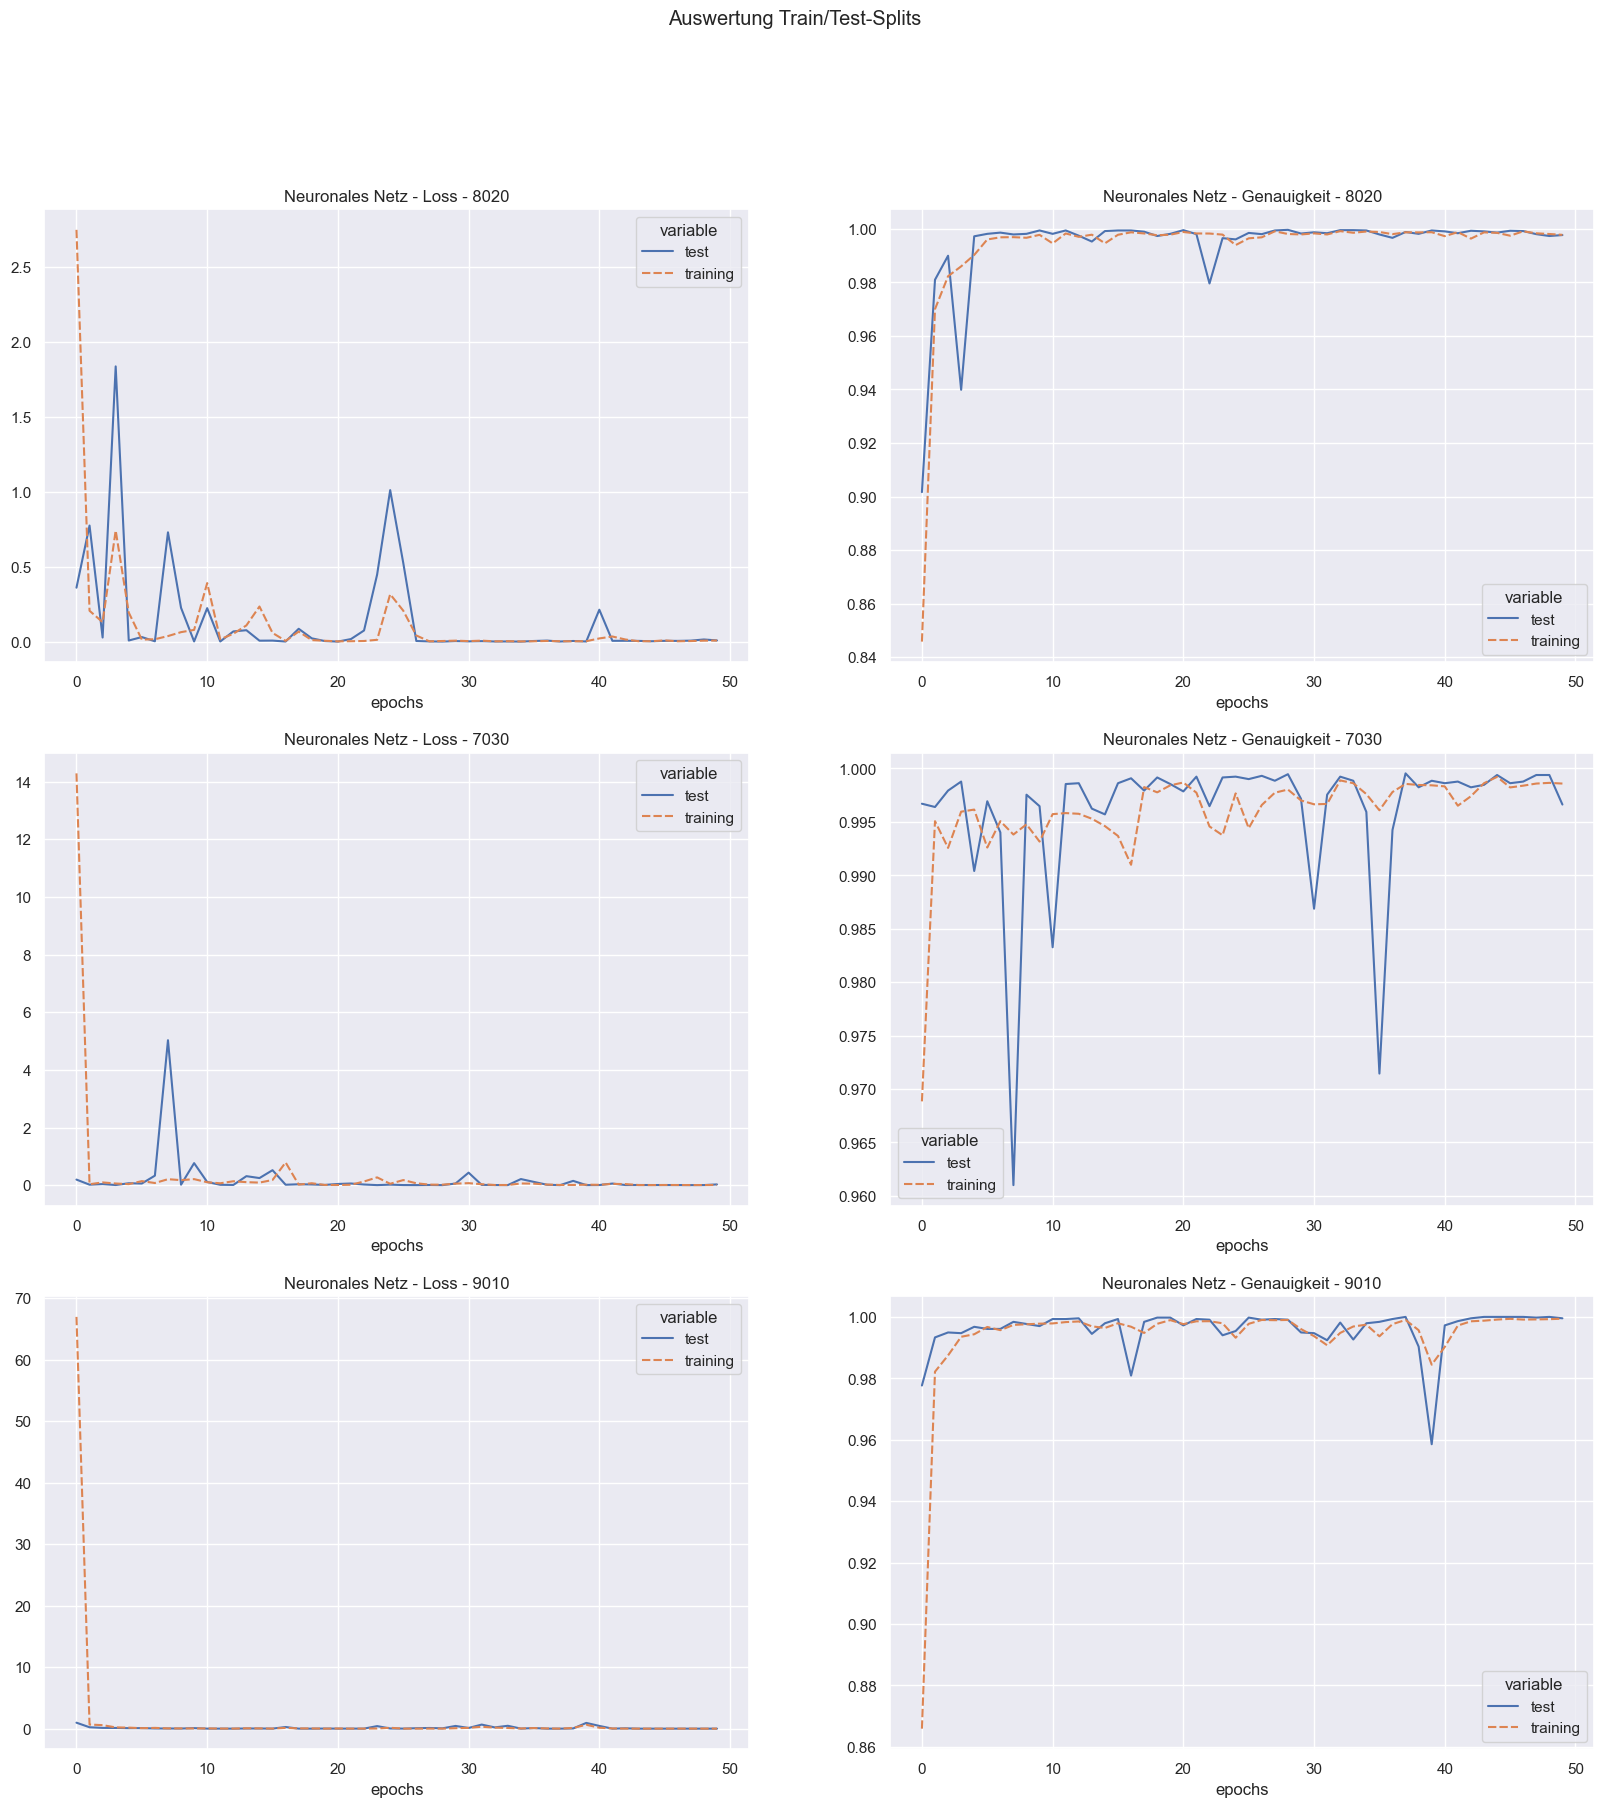

In [108]:
# Modellerstellung
nn_model_8020 = Sequential()

nn_model_8020.add(Dense(12, input_dim=X.shape[1], activation="relu", name="input"))
nn_model_8020.add(Dense(40, activation="relu", name="layer1"))
nn_model_8020.add(Dense(80, activation="relu", name="layer2"))
nn_model_8020.add(Dense(30, activation="relu", name="layer3"))
nn_model_8020.add(Dense(1, activation="sigmoid", name="result"))
nn_model_8020.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_8020 = nn_model_8020.fit(X_train1, y_train1, epochs=50, batch_size=100, validation_data=(X_test1, y_test1), verbose=0)

# Modellevaluierung
nn_result_train_8020 = nn_model_8020.evaluate(X_train1, y_train1)
nn_result_test_8020 = nn_model_8020.evaluate(X_test1, y_test1)

auswertung_8020 = pd.DataFrame.from_dict(hist_8020.history)

# Modellerstellung
nn_model_7030 = Sequential()

nn_model_7030.add(Dense(12, input_dim=X.shape[1], activation="relu", name="input"))
nn_model_7030.add(Dense(40, activation="relu", name="layer1"))
nn_model_7030.add(Dense(80, activation="relu", name="layer2"))
nn_model_7030.add(Dense(30, activation="relu", name="layer3"))
nn_model_7030.add(Dense(1, activation="sigmoid", name="result"))
nn_model_7030.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_7030 = nn_model_7030.fit(X_train2, y_train2, epochs=50, batch_size=100, validation_data=(X_test2, y_test2), verbose=0)

# Modellevaluierung
nn_result_train_7030 = nn_model_7030.evaluate(X_train2, y_train2)
nn_result_test_7030 = nn_model_7030.evaluate(X_test2, y_test2)

auswertung_7030 = pd.DataFrame.from_dict(hist_7030.history)

# Modellerstellung
nn_model_9010 = Sequential()

nn_model_9010.add(Dense(12, input_dim=X.shape[1], activation="relu", name="input"))
nn_model_9010.add(Dense(40, activation="relu", name="layer1"))
nn_model_9010.add(Dense(80, activation="relu", name="layer2"))
nn_model_9010.add(Dense(30, activation="relu", name="layer3"))
nn_model_9010.add(Dense(1, activation="sigmoid", name="result"))
nn_model_9010.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_9010 = nn_model_9010.fit(X_train3, y_train3, epochs=50, batch_size=1000, validation_data=(X_test3, y_test3), verbose=0)

# Modellevaluierung
nn_result_train_9010 = nn_model_9010.evaluate(X_train3, y_train3)
nn_result_test_9010 = nn_model_9010.evaluate(X_test3, y_test3)

auswertung_9010 = pd.DataFrame.from_dict(hist_9010.history)

# Plot erstellen
fig_nn, axes_nn = plt.subplots(3,2,figsize=(20,20), sharey=False)
fig_nn.suptitle("Auswertung Train/Test-Splits")

# Grafische Ausgabe
auswertung_8020["epochs"] = auswertung_8020.index
auswertung_8020_loss = auswertung_8020.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_8020_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_8020_accuracy = auswertung_8020.drop(["loss", "val_loss"], axis=1)
auswertung_8020_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_8020_loss = pd.melt(auswertung_8020_loss, ["epochs"])
auswertung_8020_accuracy = pd.melt(auswertung_8020_accuracy, ["epochs"])
auswertung_8020_loss = auswertung_8020_loss.pivot("epochs", "variable", "value")
auswertung_8020_accuracy = auswertung_8020_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn[0][0], data=auswertung_8020_loss)
axes_nn[0][0].set_title("Neuronales Netz - Loss - 8020")
scn.lineplot(ax=axes_nn[0][1], data=auswertung_8020_accuracy)
axes_nn[0][1].set_title("Neuronales Netz - Genauigkeit - 8020")

auswertung_7030["epochs"] = auswertung_7030.index
auswertung_7030_loss = auswertung_7030.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_7030_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_7030_accuracy = auswertung_7030.drop(["loss", "val_loss"], axis=1)
auswertung_7030_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_7030_loss = pd.melt(auswertung_7030_loss, ["epochs"])
auswertung_7030_accuracy = pd.melt(auswertung_7030_accuracy, ["epochs"])
auswertung_7030_loss = auswertung_7030_loss.pivot("epochs", "variable", "value")
auswertung_7030_accuracy = auswertung_7030_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn[1][0], data=auswertung_7030_loss)
axes_nn[1][0].set_title("Neuronales Netz - Loss - 7030")
scn.lineplot(ax=axes_nn[1][1], data=auswertung_7030_accuracy)
axes_nn[1][1].set_title("Neuronales Netz - Genauigkeit - 7030")

auswertung_9010["epochs"] = auswertung_9010.index
auswertung_9010_loss = auswertung_9010.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_9010_loss.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_9010_accuracy = auswertung_9010.drop(["loss", "val_loss"], axis=1)
auswertung_9010_accuracy.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_9010_loss = pd.melt(auswertung_9010_loss, ["epochs"])
auswertung_9010_accuracy = pd.melt(auswertung_9010_accuracy, ["epochs"])
auswertung_9010_loss = auswertung_9010_loss.pivot("epochs", "variable", "value")
auswertung_9010_accuracy = auswertung_9010_accuracy.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn[2][0], data=auswertung_9010_loss)
axes_nn[2][0].set_title("Neuronales Netz - Loss - 9010")
plt_nn = scn.lineplot(ax=axes_nn[2][1], data=auswertung_9010_accuracy)
axes_nn[2][1].set_title("Neuronales Netz - Genauigkeit - 9010")

fig_nn = plt_nn.get_figure()
fig_nn.savefig("NN_Acc")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
temp.loc[1] = pd.Series({"modell_cat":"Standard","ratio":"7030", "accuracy":  nn_result_test_7030[1], "train_accuracy": nn_result_train_7030[1]})
temp.loc[2] = pd.Series({"modell_cat":"Standard","ratio":"8020", "accuracy":  nn_result_test_8020[1], "train_accuracy": nn_result_train_8020[1]})
temp.loc[3] = pd.Series({"modell_cat":"Standard","ratio":"9010", "accuracy":  nn_result_test_9010[1], "train_accuracy": nn_result_train_9010[1]})
max_nn = pd.concat([max_nn, temp])


# NN - Splits - Scaler

136/136 [==============================] - 0s 816us/step - loss: 0.3866 - accuracy: 0.8293


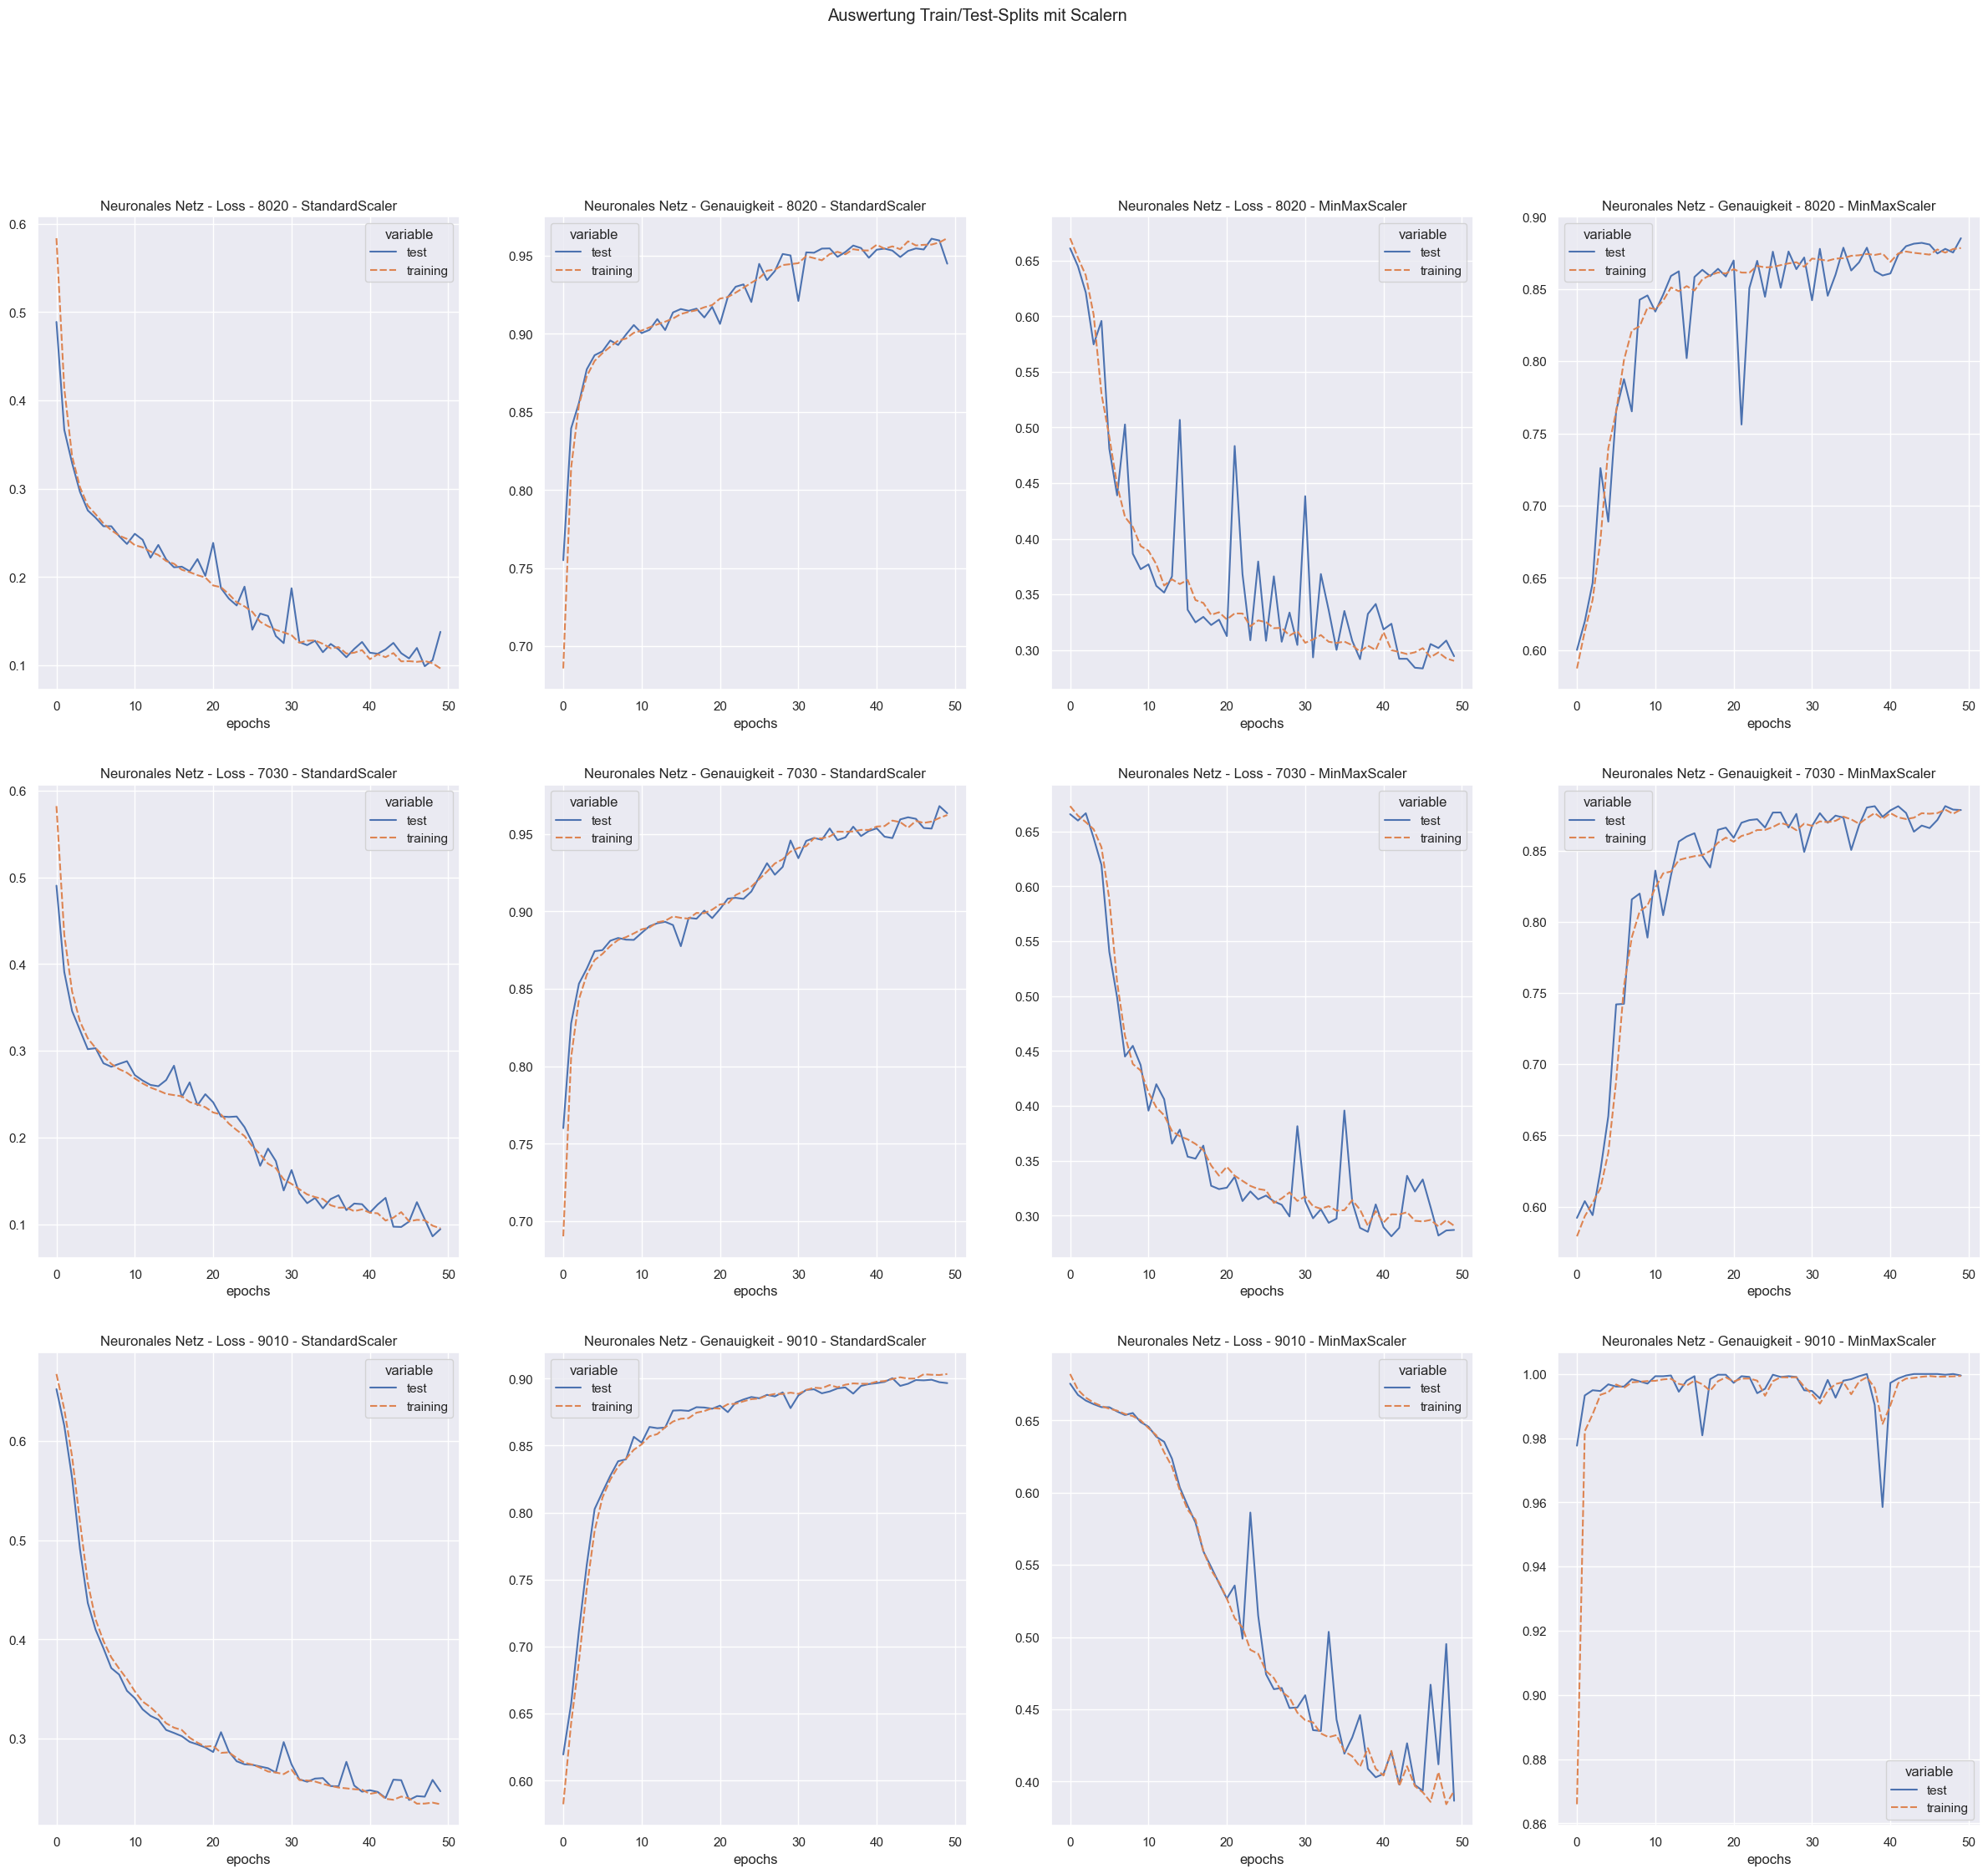

In [109]:
# Modellerstellung
nn_model_8020_ssc = Sequential()

nn_model_8020_ssc.add(Dense(12, input_dim=X.shape[1], activation="relu", name="input"))
nn_model_8020_ssc.add(Dense(40, activation="relu", name="layer1"))
nn_model_8020_ssc.add(Dense(80, activation="relu", name="layer2"))
nn_model_8020_ssc.add(Dense(30, activation="relu", name="layer3"))
nn_model_8020_ssc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_8020_ssc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_8020_ssc = nn_model_8020_ssc.fit(X_train1_SSc, y_train1, epochs=50, batch_size=100, validation_data=(X_test1_SSc, y_test1), verbose=0)

# Modellevaluierung
nn_result_train_8020_ssc = nn_model_8020_ssc.evaluate(X_train1_SSc, y_train1)
nn_result_test_8020_ssc = nn_model_8020_ssc.evaluate(X_test1_SSc, y_test1)

auswertung_8020_ssc = pd.DataFrame.from_dict(hist_8020_ssc.history)

# Modellerstellung
nn_model_7030_ssc = Sequential()

nn_model_7030_ssc.add(Dense(12, input_dim=X.shape[1], activation="relu", name="input"))
nn_model_7030_ssc.add(Dense(40, activation="relu", name="layer1"))
nn_model_7030_ssc.add(Dense(80, activation="relu", name="layer2"))
nn_model_7030_ssc.add(Dense(30, activation="relu", name="layer3"))
nn_model_7030_ssc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_7030_ssc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_7030_ssc = nn_model_7030_ssc.fit(X_train2_SSc, y_train2, epochs=50, batch_size=100, validation_data=(X_test2_SSc, y_test2), verbose=0)

# Modellevaluierung
nn_result_train_7030_ssc = nn_model_7030_ssc.evaluate(X_train2_SSc, y_train2)
nn_result_test_7030_ssc = nn_model_7030_ssc.evaluate(X_test2_SSc, y_test2)

auswertung_7030_ssc = pd.DataFrame.from_dict(hist_7030_ssc.history)

# Modellerstellung
nn_model_9010_ssc = Sequential()

nn_model_9010_ssc.add(Dense(12, input_dim=X.shape[1], activation="relu", name="input"))
nn_model_9010_ssc.add(Dense(40, activation="relu", name="layer1"))
nn_model_9010_ssc.add(Dense(80, activation="relu", name="layer2"))
nn_model_9010_ssc.add(Dense(30, activation="relu", name="layer3"))
nn_model_9010_ssc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_9010_ssc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_9010_ssc = nn_model_9010_ssc.fit(X_train3_SSc, y_train3, epochs=50, batch_size=1000, validation_data=(X_test3_SSc, y_test3), verbose=0)

# Modellevaluierung
nn_result_train_9010_ssc = nn_model_9010_ssc.evaluate(X_train3_SSc, y_train3)
nn_result_test_9010_ssc = nn_model_9010_ssc.evaluate(X_test3_SSc, y_test3)

auswertung_9010_ssc = pd.DataFrame.from_dict(hist_9010_ssc.history)

# Modellerstellung
nn_model_8020_msc = Sequential()

nn_model_8020_msc.add(Dense(12, input_dim=X.shape[1], activation="relu", name="input"))
nn_model_8020_msc.add(Dense(40, activation="relu", name="layer1"))
nn_model_8020_msc.add(Dense(80, activation="relu", name="layer2"))
nn_model_8020_msc.add(Dense(30, activation="relu", name="layer3"))
nn_model_8020_msc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_8020_msc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_8020_msc = nn_model_8020_msc.fit(X_train1_MSc, y_train1, epochs=50, batch_size=100, validation_data=(X_test1_MSc, y_test1), verbose=0)

# Modellevaluierung
nn_result_train_8020_msc = nn_model_8020_msc.evaluate(X_train1_MSc, y_train1)
nn_result_test_8020_msc = nn_model_8020_msc.evaluate(X_test1_MSc, y_test1)

auswertung_8020_msc = pd.DataFrame.from_dict(hist_8020_msc.history)

# Modellerstellung
nn_model_7030_msc = Sequential()

nn_model_7030_msc.add(Dense(12, input_dim=X.shape[1], activation="relu", name="input"))
nn_model_7030_msc.add(Dense(40, activation="relu", name="layer1"))
nn_model_7030_msc.add(Dense(80, activation="relu", name="layer2"))
nn_model_7030_msc.add(Dense(30, activation="relu", name="layer3"))
nn_model_7030_msc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_7030_msc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_7030_msc = nn_model_7030_msc.fit(X_train2_MSc, y_train2, epochs=50, batch_size=100, validation_data=(X_test2_MSc, y_test2), verbose=0)

# Modellevaluierung
nn_result_train_7030_msc = nn_model_7030_msc.evaluate(X_train2_MSc, y_train2)
nn_result_test_7030_msc = nn_model_7030_msc.evaluate(X_test2_MSc, y_test2)

auswertung_7030_msc = pd.DataFrame.from_dict(hist_7030_msc.history)

# Modellerstellung
nn_model_9010_msc = Sequential()

nn_model_9010_msc.add(Dense(12, input_dim=X.shape[1], activation="relu", name="input"))
nn_model_9010_msc.add(Dense(40, activation="relu", name="layer1"))
nn_model_9010_msc.add(Dense(80, activation="relu", name="layer2"))
nn_model_9010_msc.add(Dense(30, activation="relu", name="layer3"))
nn_model_9010_msc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_9010_msc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_9010_msc = nn_model_9010_msc.fit(X_train3_MSc, y_train3, epochs=50, batch_size=1000, validation_data=(X_test3_MSc, y_test3), verbose=0)

# Modellevaluierung
nn_result_train_9010_msc = nn_model_9010_msc.evaluate(X_train3_MSc, y_train3)
nn_result_test_9010_msc = nn_model_9010_msc.evaluate(X_test3_MSc, y_test3)

auswertung_9010_msc = pd.DataFrame.from_dict(hist_9010_msc.history)

# Plot erstellen
fig_nn_sc, axes_nn_sc = plt.subplots(3,4,figsize=(30,25), sharey=False)
fig_nn_sc.suptitle("Auswertung Train/Test-Splits mit Scalern")

# Grafische Ausgabe
auswertung_8020_ssc["epochs"] = auswertung_8020_ssc.index
auswertung_8020_loss_ssc = auswertung_8020_ssc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_8020_loss_ssc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_8020_accuracy_ssc = auswertung_8020_ssc.drop(["loss", "val_loss"], axis=1)
auswertung_8020_accuracy_ssc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_8020_loss_ssc = pd.melt(auswertung_8020_loss_ssc, ["epochs"])
auswertung_8020_accuracy_ssc = pd.melt(auswertung_8020_accuracy_ssc, ["epochs"])
auswertung_8020_loss_ssc = auswertung_8020_loss_ssc.pivot("epochs", "variable", "value")
auswertung_8020_accuracy_ssc = auswertung_8020_accuracy_ssc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_sc[0][0], data=auswertung_8020_loss_ssc)
axes_nn_sc[0][0].set_title("Neuronales Netz - Loss - 8020 - StandardScaler")
scn.lineplot(ax=axes_nn_sc[0][1], data=auswertung_8020_accuracy_ssc)
axes_nn_sc[0][1].set_title("Neuronales Netz - Genauigkeit - 8020 - StandardScaler")

auswertung_7030_ssc["epochs"] = auswertung_7030_ssc.index
auswertung_7030_loss_ssc = auswertung_7030_ssc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_7030_loss_ssc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_7030_accuracy_ssc = auswertung_7030_ssc.drop(["loss", "val_loss"], axis=1)
auswertung_7030_accuracy_ssc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_7030_loss_ssc = pd.melt(auswertung_7030_loss_ssc, ["epochs"])
auswertung_7030_accuracy_ssc = pd.melt(auswertung_7030_accuracy_ssc, ["epochs"])
auswertung_7030_loss_ssc = auswertung_7030_loss_ssc.pivot("epochs", "variable", "value")
auswertung_7030_accuracy_ssc = auswertung_7030_accuracy_ssc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_sc[1][0], data=auswertung_7030_loss_ssc)
axes_nn_sc[1][0].set_title("Neuronales Netz - Loss - 7030 - StandardScaler")
scn.lineplot(ax=axes_nn_sc[1][1], data=auswertung_7030_accuracy_ssc)
axes_nn_sc[1][1].set_title("Neuronales Netz - Genauigkeit - 7030 - StandardScaler")

auswertung_9010_ssc["epochs"] = auswertung_9010_ssc.index
auswertung_9010_loss_ssc = auswertung_9010_ssc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_9010_loss_ssc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_9010_accuracy_ssc = auswertung_9010_ssc.drop(["loss", "val_loss"], axis=1)
auswertung_9010_accuracy_ssc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_9010_loss_ssc = pd.melt(auswertung_9010_loss_ssc, ["epochs"])
auswertung_9010_accuracy_ssc = pd.melt(auswertung_9010_accuracy_ssc, ["epochs"])
auswertung_9010_loss_ssc = auswertung_9010_loss_ssc.pivot("epochs", "variable", "value")
auswertung_9010_accuracy_ssc = auswertung_9010_accuracy_ssc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_sc[2][0], data=auswertung_9010_loss_ssc)
axes_nn_sc[2][0].set_title("Neuronales Netz - Loss - 9010 - StandardScaler")
scn.lineplot(ax=axes_nn_sc[2][1], data=auswertung_9010_accuracy_ssc)
axes_nn_sc[2][1].set_title("Neuronales Netz - Genauigkeit - 9010 - StandardScaler")

auswertung_8020_msc["epochs"] = auswertung_8020_msc.index
auswertung_8020_loss_msc = auswertung_8020_msc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_8020_loss_msc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_8020_accuracy_msc = auswertung_8020_msc.drop(["loss", "val_loss"], axis=1)
auswertung_8020_accuracy_msc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_8020_loss_msc = pd.melt(auswertung_8020_loss_msc, ["epochs"])
auswertung_8020_accuracy_msc = pd.melt(auswertung_8020_accuracy_msc, ["epochs"])
auswertung_8020_loss_msc = auswertung_8020_loss_msc.pivot("epochs", "variable", "value")
auswertung_8020_accuracy_msc = auswertung_8020_accuracy_msc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_sc[0][2], data=auswertung_8020_loss_msc)
axes_nn_sc[0][2].set_title("Neuronales Netz - Loss - 8020 - MinMaxScaler")
scn.lineplot(ax=axes_nn_sc[0][3], data=auswertung_8020_accuracy_msc)
axes_nn_sc[0][3].set_title("Neuronales Netz - Genauigkeit - 8020 - MinMaxScaler")

auswertung_7030_msc["epochs"] = auswertung_7030_msc.index
auswertung_7030_loss_msc = auswertung_7030_msc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_7030_loss_msc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_7030_accuracy_msc = auswertung_7030_msc.drop(["loss", "val_loss"], axis=1)
auswertung_7030_accuracy_msc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_7030_loss_msc = pd.melt(auswertung_7030_loss_msc, ["epochs"])
auswertung_7030_accuracy_msc = pd.melt(auswertung_7030_accuracy_msc, ["epochs"])
auswertung_7030_loss_msc = auswertung_7030_loss_msc.pivot("epochs", "variable", "value")
auswertung_7030_accuracy_msc = auswertung_7030_accuracy_msc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_sc[1][2], data=auswertung_7030_loss_msc)
axes_nn_sc[1][2].set_title("Neuronales Netz - Loss - 7030 - MinMaxScaler")
scn.lineplot(ax=axes_nn_sc[1][3], data=auswertung_7030_accuracy_msc)
axes_nn_sc[1][3].set_title("Neuronales Netz - Genauigkeit - 7030 - MinMaxScaler")

auswertung_9010_msc["epochs"] = auswertung_9010_msc.index
auswertung_9010_loss_msc = auswertung_9010_msc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_9010_loss_msc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_9010_accuracy_msc = auswertung_9010_msc.drop(["loss", "val_loss"], axis=1)
auswertung_9010_accuracy_msc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_9010_loss_msc = pd.melt(auswertung_9010_loss_msc, ["epochs"])
auswertung_9010_accuracy_msc = pd.melt(auswertung_9010_accuracy_msc, ["epochs"])
auswertung_9010_loss_msc = auswertung_9010_loss_msc.pivot("epochs", "variable", "value")
auswertung_9010_accuracy_msc = auswertung_9010_accuracy_msc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_sc[2][2], data=auswertung_9010_loss_msc)
axes_nn_sc[2][2].set_title("Neuronales Netz - Loss - 9010 - MinMaxScaler")
plt_nn_sc = scn.lineplot(ax=axes_nn_sc[2][3], data=auswertung_9010_accuracy)
axes_nn_sc[2][3].set_title("Neuronales Netz - Genauigkeit - 9010 - MinMaxScaler")

fig_nn_sc = plt_nn_sc.get_figure()
fig_nn_sc.savefig("NN_Acc_Scaler")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
temp.loc[1] = pd.Series({"modell_cat":"StandardScaler","ratio":"7030", "accuracy":  nn_result_test_7030_ssc[1], "train_accuracy": nn_result_train_7030_ssc[1]})
temp.loc[2] = pd.Series({"modell_cat":"StandardScaler","ratio":"8020", "accuracy":  nn_result_test_8020_ssc[1], "train_accuracy": nn_result_train_8020_ssc[1]})
temp.loc[3] = pd.Series({"modell_cat":"StandardScaler","ratio":"9010", "accuracy":  nn_result_test_9010_ssc[1], "train_accuracy": nn_result_train_9010_ssc[1]})
temp.loc[4] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"7030", "accuracy":  nn_result_test_7030_msc[1], "train_accuracy": nn_result_train_7030_msc[1]})
temp.loc[5] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"8020", "accuracy":  nn_result_test_8020_msc[1], "train_accuracy": nn_result_train_8020_msc[1]})
temp.loc[6] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"9010", "accuracy":  nn_result_test_9010_msc[1], "train_accuracy": nn_result_train_9010_msc[1]})
max_nn = pd.concat([max_nn, temp])

# Ergebnis NN

In [110]:
# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_nn = max_nn.reset_index()
max_nn["accuracy"] = pd.to_numeric(max_nn["accuracy"])
max_nn["train_accuracy"] = pd.to_numeric(max_nn["train_accuracy"])
max_nn_max_id =  max_nn["accuracy"].idxmax()
max_nn_result = max_nn.iloc[max_nn_max_id]
display(max_nn_result)

# Bestes Ergebnis in DataFrame zur Endanalyse eintragen
temp = pd.DataFrame(columns=["modell_name", "category", "accuracy"])
temp.loc[1] = pd.Series({"modell_name": "NN-" + str(max_nn_result["modell_cat"]) + "-" + str(max_nn_result["ratio"]), "category": "test", "accuracy": max_nn_result["accuracy"]})
temp.loc[2] = pd.Series({"modell_name": "NN-" + str(max_nn_result["modell_cat"]) + "-" + str(max_nn_result["ratio"]), "category": "training", "accuracy": max_nn_result["train_accuracy"]})
max_acc = pd.concat([max_acc, temp])

index                    3
modell_cat        Standard
ratio                 9010
accuracy          0.999539
train_accuracy    0.998746
Name: 2, dtype: object

# NN - Splits - Reduziert

136/136 [==============================] - 0s 927us/step - loss: 2.4131 - accuracy: 0.4401


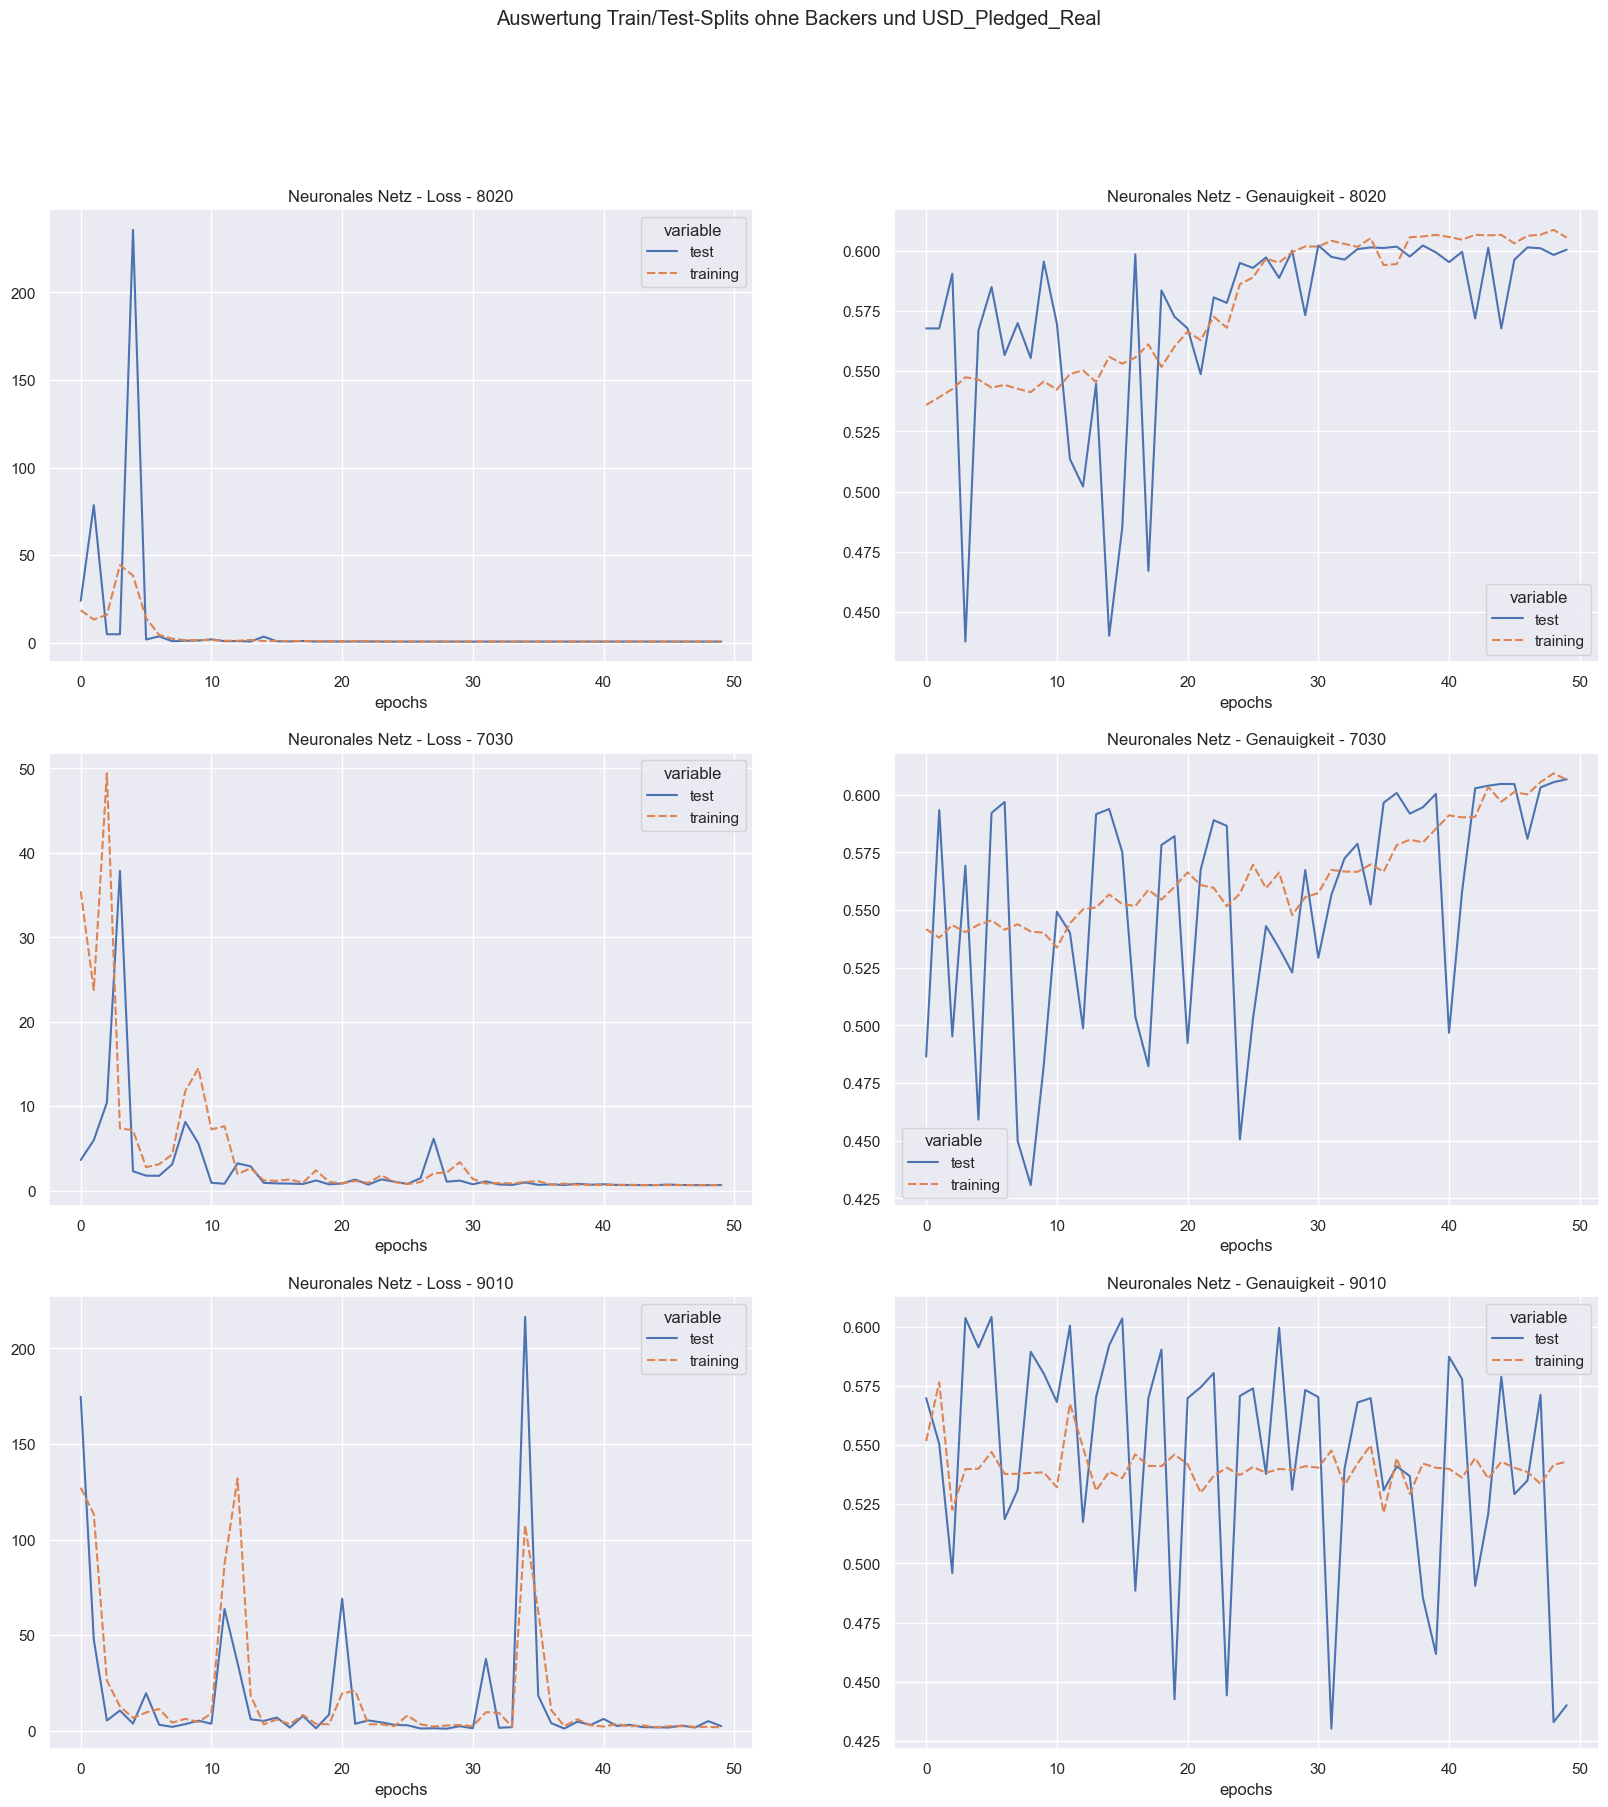

In [111]:
# Modellerstellung
nn_model_8020_red = Sequential()

nn_model_8020_red.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_8020_red.add(Dense(40, activation="relu", name="layer1"))
nn_model_8020_red.add(Dense(80, activation="relu", name="layer2"))
nn_model_8020_red.add(Dense(30, activation="relu", name="layer3"))
nn_model_8020_red.add(Dense(1, activation="sigmoid", name="result"))
nn_model_8020_red.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_8020_red = nn_model_8020_red.fit(X_train4, y_train4, epochs=50, batch_size=100, validation_data=(X_test4, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_8020_red = nn_model_8020_red.evaluate(X_train4, y_train4)
nn_result_test_8020_red = nn_model_8020_red.evaluate(X_test4, y_test4)

auswertung_8020_red = pd.DataFrame.from_dict(hist_8020_red.history)

# Modellerstellung
nn_model_7030_red = Sequential()

nn_model_7030_red.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_7030_red.add(Dense(40, activation="relu", name="layer1"))
nn_model_7030_red.add(Dense(80, activation="relu", name="layer2"))
nn_model_7030_red.add(Dense(30, activation="relu", name="layer3"))
nn_model_7030_red.add(Dense(1, activation="sigmoid", name="result"))
nn_model_7030_red.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_7030_red = nn_model_7030_red.fit(X_train5, y_train5, epochs=50, batch_size=100, validation_data=(X_test5, y_test5), verbose=0)

# Modellevaluierung
nn_result_train_7030_red = nn_model_7030_red.evaluate(X_train5, y_train5)
nn_result_test_7030_red = nn_model_7030_red.evaluate(X_test5, y_test5)

auswertung_7030_red = pd.DataFrame.from_dict(hist_7030_red.history)

# Modellerstellung
nn_model_9010_red = Sequential()

nn_model_9010_red.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_9010_red.add(Dense(40, activation="relu", name="layer1"))
nn_model_9010_red.add(Dense(80, activation="relu", name="layer2"))
nn_model_9010_red.add(Dense(30, activation="relu", name="layer3"))
nn_model_9010_red.add(Dense(1, activation="sigmoid", name="result"))
nn_model_9010_red.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_9010_red = nn_model_9010_red.fit(X_train6, y_train6, epochs=50, batch_size=1000, validation_data=(X_test6, y_test6), verbose=0)

# Modellevaluierung
nn_result_train_9010_red = nn_model_9010_red.evaluate(X_train6, y_train6)
nn_result_test_9010_red = nn_model_9010_red.evaluate(X_test6, y_test6)

auswertung_9010_red = pd.DataFrame.from_dict(hist_9010_red.history)

# Plot erstellen
fig_nn_red, axes_nn_red = plt.subplots(3,2,figsize=(20,20), sharey=False)
fig_nn_red.suptitle("Auswertung Train/Test-Splits ohne Backers und USD_Pledged_Real")

# Grafische Ausgabe
auswertung_8020_red["epochs"] = auswertung_8020_red.index
auswertung_8020_loss_red = auswertung_8020_red.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_8020_loss_red.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_8020_accuracy_red = auswertung_8020_red.drop(["loss", "val_loss"], axis=1)
auswertung_8020_accuracy_red.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_8020_loss_red = pd.melt(auswertung_8020_loss_red, ["epochs"])
auswertung_8020_accuracy_red = pd.melt(auswertung_8020_accuracy_red, ["epochs"])
auswertung_8020_loss_red = auswertung_8020_loss_red.pivot("epochs", "variable", "value")
auswertung_8020_accuracy_red = auswertung_8020_accuracy_red.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_red[0][0], data=auswertung_8020_loss_red)
axes_nn_red[0][0].set_title("Neuronales Netz - Loss - 8020")
scn.lineplot(ax=axes_nn_red[0][1], data=auswertung_8020_accuracy_red)
axes_nn_red[0][1].set_title("Neuronales Netz - Genauigkeit - 8020")

auswertung_7030_red["epochs"] = auswertung_7030_red.index
auswertung_7030_loss_red = auswertung_7030_red.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_7030_loss_red.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_7030_accuracy_red = auswertung_7030_red.drop(["loss", "val_loss"], axis=1)
auswertung_7030_accuracy_red.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_7030_loss_red = pd.melt(auswertung_7030_loss_red, ["epochs"])
auswertung_7030_accuracy_red = pd.melt(auswertung_7030_accuracy_red, ["epochs"])
auswertung_7030_loss_red = auswertung_7030_loss_red.pivot("epochs", "variable", "value")
auswertung_7030_accuracy_red = auswertung_7030_accuracy_red.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_red[1][0], data=auswertung_7030_loss_red)
axes_nn_red[1][0].set_title("Neuronales Netz - Loss - 7030")
scn.lineplot(ax=axes_nn_red[1][1], data=auswertung_7030_accuracy_red)
axes_nn_red[1][1].set_title("Neuronales Netz - Genauigkeit - 7030")

auswertung_9010_red["epochs"] = auswertung_9010_red.index
auswertung_9010_loss_red = auswertung_9010_red.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_9010_loss_red.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_9010_accuracy_red = auswertung_9010_red.drop(["loss", "val_loss"], axis=1)
auswertung_9010_accuracy_red.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_9010_loss_red = pd.melt(auswertung_9010_loss_red, ["epochs"])
auswertung_9010_accuracy_red = pd.melt(auswertung_9010_accuracy_red, ["epochs"])
auswertung_9010_loss_red = auswertung_9010_loss_red.pivot("epochs", "variable", "value")
auswertung_9010_accuracy_red = auswertung_9010_accuracy_red.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_red[2][0], data=auswertung_9010_loss_red)
axes_nn_red[2][0].set_title("Neuronales Netz - Loss - 9010")
plt_nn_red = scn.lineplot(ax=axes_nn_red[2][1], data=auswertung_9010_accuracy_red)
axes_nn_red[2][1].set_title("Neuronales Netz - Genauigkeit - 9010")

fig_nn_red = plt_nn_red.get_figure()
fig_nn_red.savefig("NN_Red_Acc")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
temp.loc[1] = pd.Series({"modell_cat":"Standard","ratio":"7030", "accuracy":  nn_result_test_7030_red[1], "train_accuracy": nn_result_train_7030_red[1]})
temp.loc[2] = pd.Series({"modell_cat":"Standard","ratio":"8020", "accuracy":  nn_result_test_8020_red[1], "train_accuracy": nn_result_train_8020_red[1]})
temp.loc[3] = pd.Series({"modell_cat":"Standard","ratio":"9010", "accuracy":  nn_result_test_9010_red[1], "train_accuracy": nn_result_train_9010_red[1]})
max_nn_red = pd.concat([max_nn_red, temp])

# NN - Splits - Reduziert - Scaler

136/136 [==============================] - 0s 932us/step - loss: 0.6522 - accuracy: 0.6175


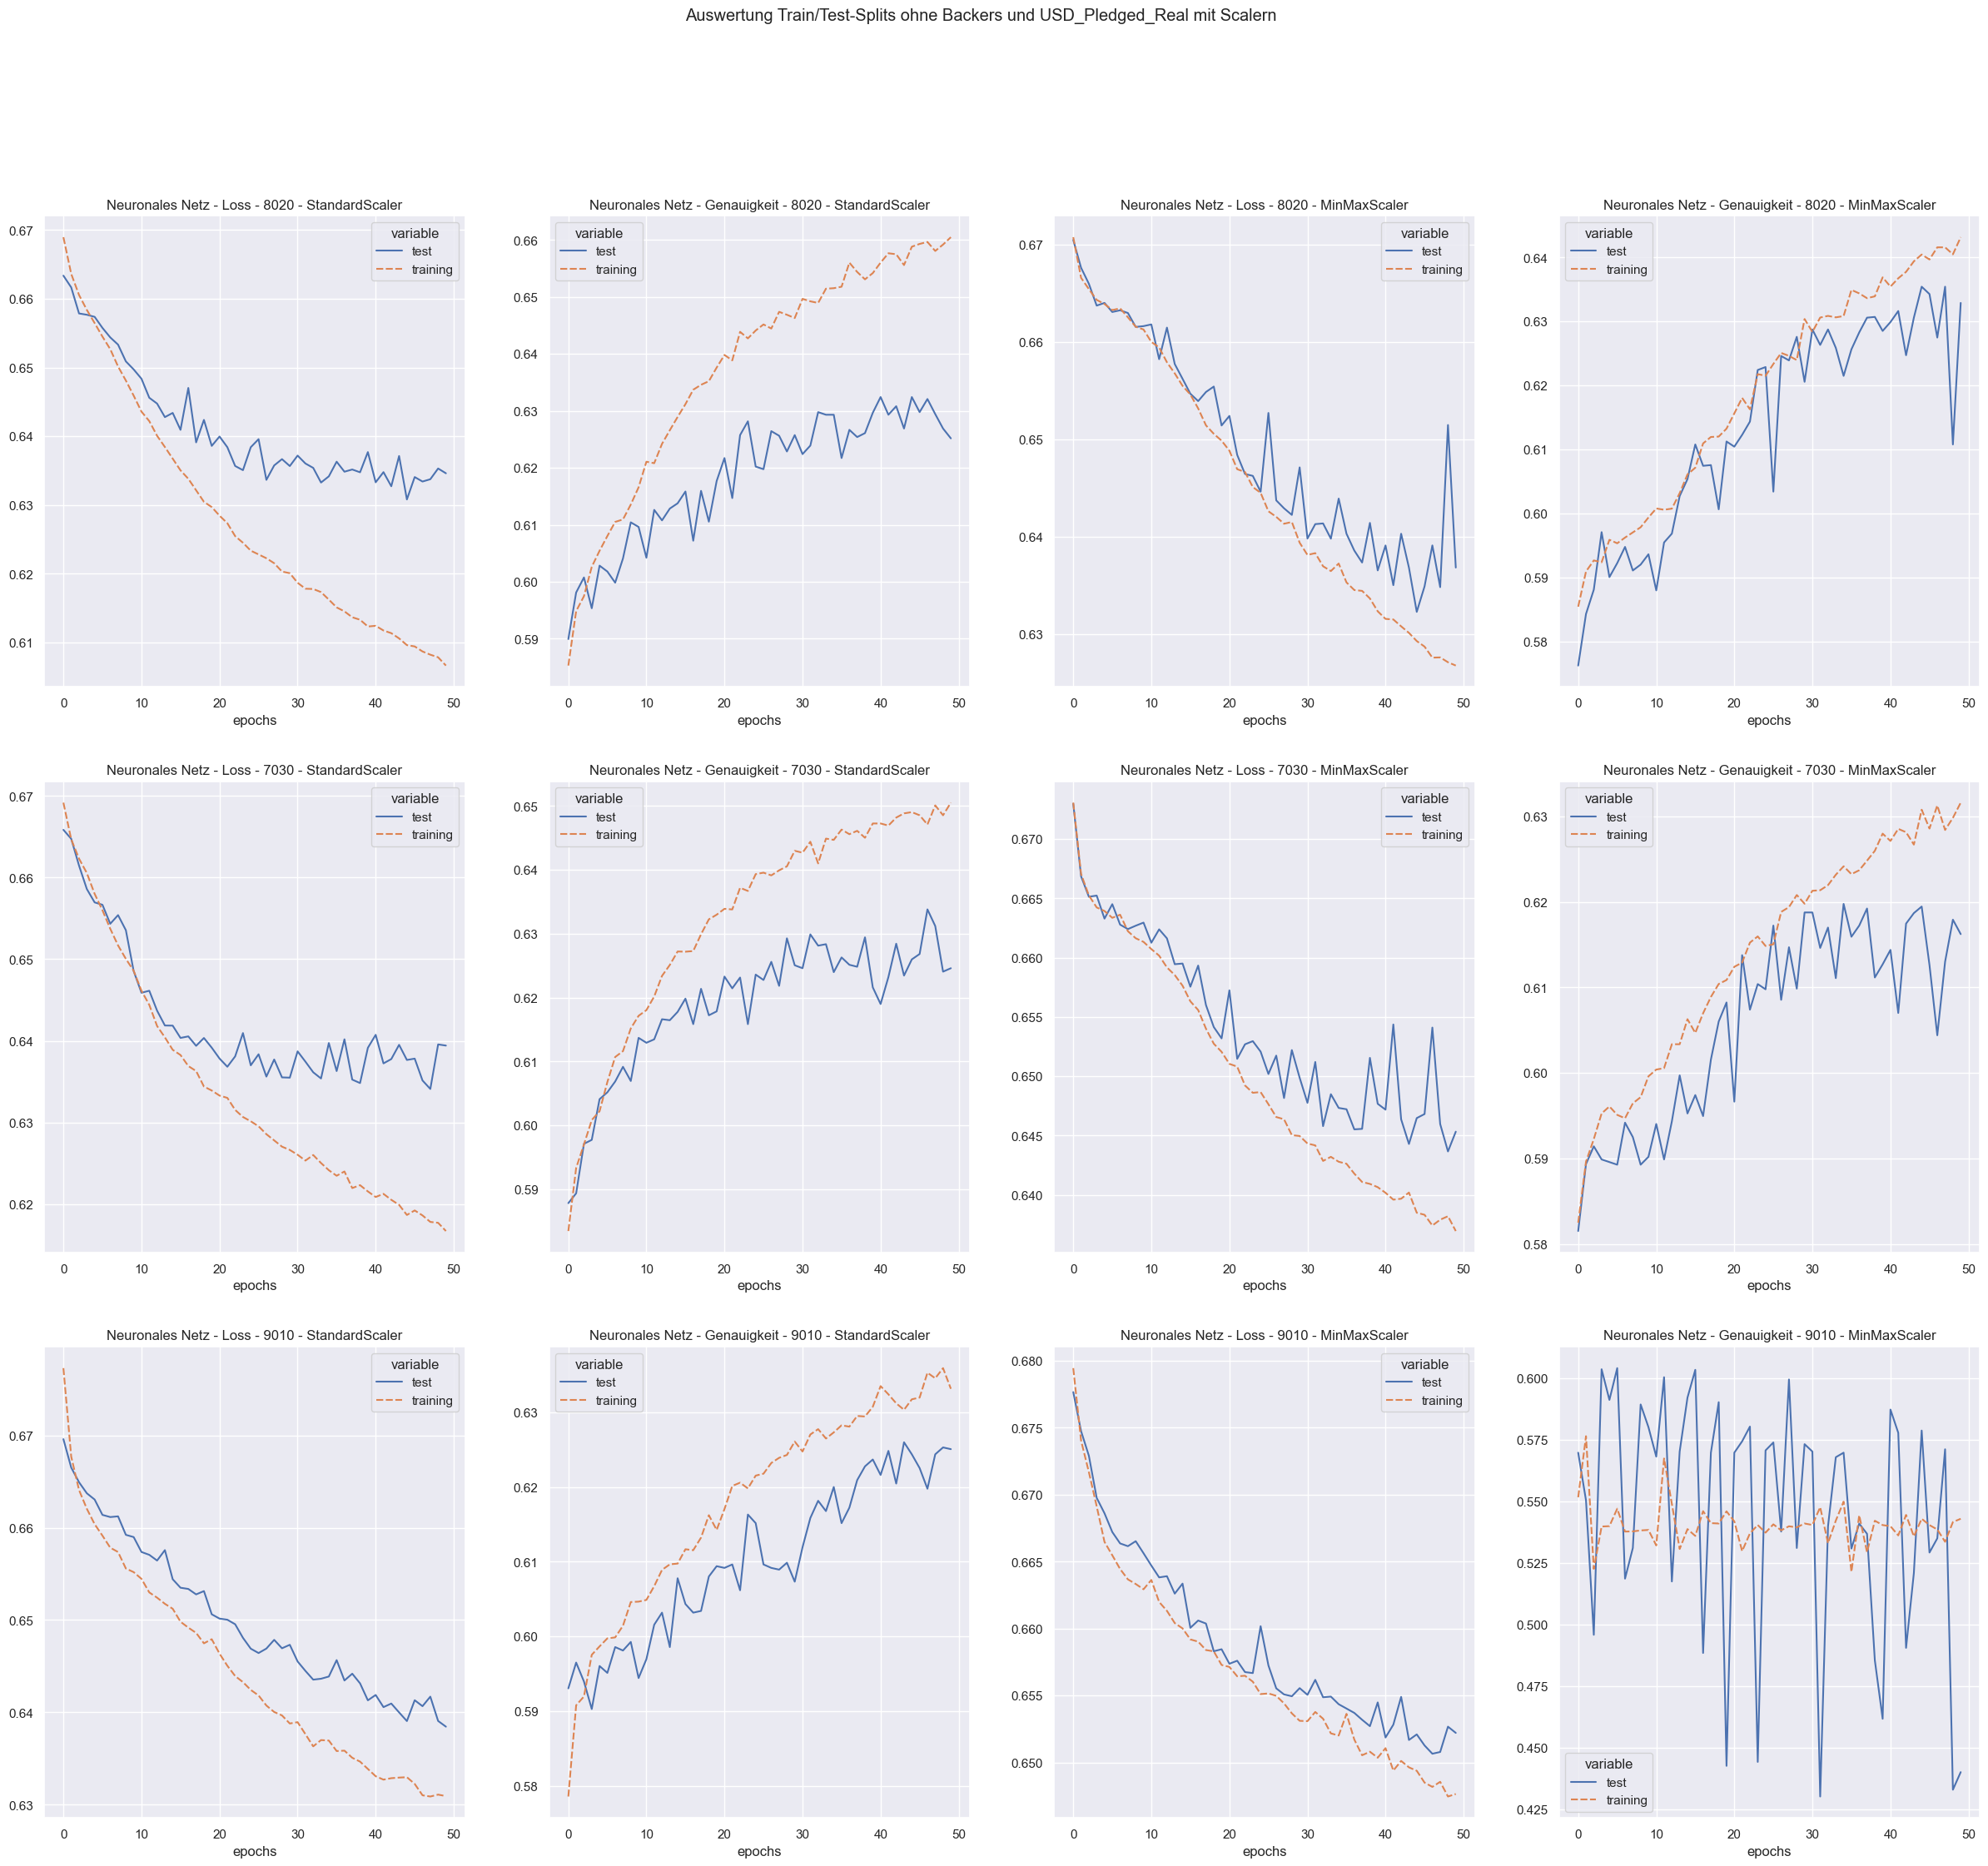

In [112]:
# Modellerstellung
nn_model_8020_red_ssc = Sequential()

nn_model_8020_red_ssc.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_8020_red_ssc.add(Dense(40, activation="relu", name="layer1"))
nn_model_8020_red_ssc.add(Dense(80, activation="relu", name="layer2"))
nn_model_8020_red_ssc.add(Dense(30, activation="relu", name="layer3"))
nn_model_8020_red_ssc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_8020_red_ssc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_8020_red_ssc = nn_model_8020_red_ssc.fit(X_train4_SSc, y_train4, epochs=50, batch_size=100, validation_data=(X_test4_SSc, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_8020_red_ssc = nn_model_8020_red_ssc.evaluate(X_train4_SSc, y_train4)
nn_result_test_8020_red_ssc = nn_model_8020_red_ssc.evaluate(X_test4_SSc, y_test4)

auswertung_8020_red_ssc = pd.DataFrame.from_dict(hist_8020_red_ssc.history)

# Modellertellung
nn_model_7030_red_ssc = Sequential()

nn_model_7030_red_ssc.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_7030_red_ssc.add(Dense(40, activation="relu", name="layer1"))
nn_model_7030_red_ssc.add(Dense(80, activation="relu", name="layer2"))
nn_model_7030_red_ssc.add(Dense(30, activation="relu", name="layer3"))
nn_model_7030_red_ssc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_7030_red_ssc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_7030_red_ssc = nn_model_7030_red_ssc.fit(X_train5_SSc, y_train5, epochs=50, batch_size=100, validation_data=(X_test5_SSc, y_test5), verbose=0)

# Modellevaluierung
nn_result_train_7030_red_ssc = nn_model_7030_red_ssc.evaluate(X_train5_SSc, y_train5)
nn_result_test_7030_red_ssc = nn_model_7030_red_ssc.evaluate(X_test5_SSc, y_test5)

auswertung_7030_red_ssc = pd.DataFrame.from_dict(hist_7030_red_ssc.history)

# Modellertellung
nn_model_9010_red_ssc = Sequential()

nn_model_9010_red_ssc.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_9010_red_ssc.add(Dense(40, activation="relu", name="layer1"))
nn_model_9010_red_ssc.add(Dense(80, activation="relu", name="layer2"))
nn_model_9010_red_ssc.add(Dense(30, activation="relu", name="layer3"))
nn_model_9010_red_ssc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_9010_red_ssc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_9010_red_ssc = nn_model_9010_red_ssc.fit(X_train6_SSc, y_train6, epochs=50, batch_size=1000, validation_data=(X_test6_SSc, y_test6), verbose=0)

# Modellevaluierung
nn_result_train_9010_red_ssc = nn_model_9010_red_ssc.evaluate(X_train6_SSc, y_train6)
nn_result_test_9010_red_ssc = nn_model_9010_red_ssc.evaluate(X_test6_SSc, y_test6)

auswertung_9010_red_ssc = pd.DataFrame.from_dict(hist_9010_red_ssc.history)

# Modellertellung
nn_model_8020_red_msc = Sequential()

nn_model_8020_red_msc.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_8020_red_msc.add(Dense(40, activation="relu", name="layer1"))
nn_model_8020_red_msc.add(Dense(80, activation="relu", name="layer2"))
nn_model_8020_red_msc.add(Dense(30, activation="relu", name="layer3"))
nn_model_8020_red_msc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_8020_red_msc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_8020_red_msc = nn_model_8020_red_msc.fit(X_train4_MSc, y_train4, epochs=50, batch_size=100, validation_data=(X_test4_MSc, y_test4), verbose=0)

# Modellevaluierung
nn_result_train_8020_red_msc = nn_model_8020_red_msc.evaluate(X_train4_MSc, y_train4)
nn_result_test_8020_red_msc = nn_model_8020_red_msc.evaluate(X_test4_MSc, y_test4)

auswertung_8020_red_msc = pd.DataFrame.from_dict(hist_8020_red_msc.history)

# Modellertellung
nn_model_7030_red_msc = Sequential()

nn_model_7030_red_msc.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_7030_red_msc.add(Dense(40, activation="relu", name="layer1"))
nn_model_7030_red_msc.add(Dense(80, activation="relu", name="layer2"))
nn_model_7030_red_msc.add(Dense(30, activation="relu", name="layer3"))
nn_model_7030_red_msc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_7030_red_msc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_7030_red_msc = nn_model_7030_red_msc.fit(X_train5_MSc, y_train5, epochs=50, batch_size=100, validation_data=(X_test5_MSc, y_test5), verbose=0)

# Modellevaluierung
nn_result_train_7030_red_msc = nn_model_7030_red_msc.evaluate(X_train5_MSc, y_train5)
nn_result_test_7030_red_msc = nn_model_7030_red_msc.evaluate(X_test5_MSc, y_test5)

auswertung_7030_red_msc = pd.DataFrame.from_dict(hist_7030_red_msc.history)

# Modellertellung
nn_model_9010_red_msc = Sequential()

nn_model_9010_red_msc.add(Dense(10, input_dim=X2.shape[1], activation="relu", name="input"))
nn_model_9010_red_msc.add(Dense(40, activation="relu", name="layer1"))
nn_model_9010_red_msc.add(Dense(80, activation="relu", name="layer2"))
nn_model_9010_red_msc.add(Dense(30, activation="relu", name="layer3"))
nn_model_9010_red_msc.add(Dense(1, activation="sigmoid", name="result"))
nn_model_9010_red_msc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_9010_red_msc = nn_model_9010_red_msc.fit(X_train6_MSc, y_train6, epochs=50, batch_size=1000, validation_data=(X_test6_MSc, y_test6), verbose=0)

# Modellevaluierung
nn_result_train_9010_red_msc = nn_model_9010_red_msc.evaluate(X_train6_MSc, y_train6)
nn_result_test_9010_red_msc = nn_model_9010_red_msc.evaluate(X_test6_MSc, y_test6)

auswertung_9010_red_msc = pd.DataFrame.from_dict(hist_9010_red_msc.history)

# Plot erstellen
fig_nn_red_sc, axes_nn_red_sc = plt.subplots(3,4,figsize=(30,25), sharey=False)
fig_nn_red_sc.suptitle("Auswertung Train/Test-Splits ohne Backers und USD_Pledged_Real mit Scalern")

# Grafische Ausgabe
auswertung_8020_red_ssc["epochs"] = auswertung_8020_red_ssc.index
auswertung_8020_loss_red_ssc = auswertung_8020_red_ssc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_8020_loss_red_ssc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_8020_accuracy_red_ssc = auswertung_8020_red_ssc.drop(["loss", "val_loss"], axis=1)
auswertung_8020_accuracy_red_ssc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_8020_loss_red_ssc = pd.melt(auswertung_8020_loss_red_ssc, ["epochs"])
auswertung_8020_accuracy_red_ssc = pd.melt(auswertung_8020_accuracy_red_ssc, ["epochs"])
auswertung_8020_loss_red_ssc = auswertung_8020_loss_red_ssc.pivot("epochs", "variable", "value")
auswertung_8020_accuracy_red_ssc = auswertung_8020_accuracy_red_ssc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_red_sc[0][0], data=auswertung_8020_loss_red_ssc)
axes_nn_red_sc[0][0].set_title("Neuronales Netz - Loss - 8020 - StandardScaler")
scn.lineplot(ax=axes_nn_red_sc[0][1], data=auswertung_8020_accuracy_red_ssc)
axes_nn_red_sc[0][1].set_title("Neuronales Netz - Genauigkeit - 8020 - StandardScaler")

auswertung_7030_red_ssc["epochs"] = auswertung_7030_red_ssc.index
auswertung_7030_loss_red_ssc = auswertung_7030_red_ssc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_7030_loss_red_ssc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_7030_accuracy_red_ssc = auswertung_7030_red_ssc.drop(["loss", "val_loss"], axis=1)
auswertung_7030_accuracy_red_ssc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_7030_loss_red_ssc = pd.melt(auswertung_7030_loss_red_ssc, ["epochs"])
auswertung_7030_accuracy_red_ssc = pd.melt(auswertung_7030_accuracy_red_ssc, ["epochs"])
auswertung_7030_loss_red_ssc = auswertung_7030_loss_red_ssc.pivot("epochs", "variable", "value")
auswertung_7030_accuracy_red_ssc = auswertung_7030_accuracy_red_ssc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_red_sc[1][0], data=auswertung_7030_loss_red_ssc)
axes_nn_red_sc[1][0].set_title("Neuronales Netz - Loss - 7030 - StandardScaler")
scn.lineplot(ax=axes_nn_red_sc[1][1], data=auswertung_7030_accuracy_red_ssc)
axes_nn_red_sc[1][1].set_title("Neuronales Netz - Genauigkeit - 7030 - StandardScaler")

auswertung_9010_red_ssc["epochs"] = auswertung_9010_red_ssc.index
auswertung_9010_loss_red_ssc = auswertung_9010_red_ssc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_9010_loss_red_ssc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_9010_accuracy_red_ssc = auswertung_9010_red_ssc.drop(["loss", "val_loss"], axis=1)
auswertung_9010_accuracy_red_ssc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_9010_loss_red_ssc = pd.melt(auswertung_9010_loss_red_ssc, ["epochs"])
auswertung_9010_accuracy_red_ssc = pd.melt(auswertung_9010_accuracy_red_ssc, ["epochs"])
auswertung_9010_loss_red_ssc = auswertung_9010_loss_red_ssc.pivot("epochs", "variable", "value")
auswertung_9010_accuracy_red_ssc = auswertung_9010_accuracy_red_ssc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_red_sc[2][0], data=auswertung_9010_loss_red_ssc)
axes_nn_red_sc[2][0].set_title("Neuronales Netz - Loss - 9010 - StandardScaler")
scn.lineplot(ax=axes_nn_red_sc[2][1], data=auswertung_9010_accuracy_red_ssc)
axes_nn_red_sc[2][1].set_title("Neuronales Netz - Genauigkeit - 9010 - StandardScaler")

auswertung_8020_red_msc["epochs"] = auswertung_8020_red_msc.index
auswertung_8020_loss_red_msc = auswertung_8020_red_msc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_8020_loss_red_msc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_8020_accuracy_red_msc = auswertung_8020_red_msc.drop(["loss", "val_loss"], axis=1)
auswertung_8020_accuracy_red_msc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_8020_loss_red_msc = pd.melt(auswertung_8020_loss_red_msc, ["epochs"])
auswertung_8020_accuracy_red_msc = pd.melt(auswertung_8020_accuracy_red_msc, ["epochs"])
auswertung_8020_loss_red_msc = auswertung_8020_loss_red_msc.pivot("epochs", "variable", "value")
auswertung_8020_accuracy_red_msc = auswertung_8020_accuracy_red_msc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_red_sc[0][2], data=auswertung_8020_loss_red_msc)
axes_nn_red_sc[0][2].set_title("Neuronales Netz - Loss - 8020 - MinMaxScaler")
scn.lineplot(ax=axes_nn_red_sc[0][3], data=auswertung_8020_accuracy_red_msc)
axes_nn_red_sc[0][3].set_title("Neuronales Netz - Genauigkeit - 8020 - MinMaxScaler")

auswertung_7030_red_msc["epochs"] = auswertung_7030_red_msc.index
auswertung_7030_loss_red_msc = auswertung_7030_red_msc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_7030_loss_red_msc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_7030_accuracy_red_msc = auswertung_7030_red_msc.drop(["loss", "val_loss"], axis=1)
auswertung_7030_accuracy_red_msc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_7030_loss_red_msc = pd.melt(auswertung_7030_loss_red_msc, ["epochs"])
auswertung_7030_accuracy_red_msc = pd.melt(auswertung_7030_accuracy_red_msc, ["epochs"])
auswertung_7030_loss_red_msc = auswertung_7030_loss_red_msc.pivot("epochs", "variable", "value")
auswertung_7030_accuracy_red_msc = auswertung_7030_accuracy_red_msc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_red_sc[1][2], data=auswertung_7030_loss_red_msc)
axes_nn_red_sc[1][2].set_title("Neuronales Netz - Loss - 7030 - MinMaxScaler")
scn.lineplot(ax=axes_nn_red_sc[1][3], data=auswertung_7030_accuracy_red_msc)
axes_nn_red_sc[1][3].set_title("Neuronales Netz - Genauigkeit - 7030 - MinMaxScaler")

auswertung_9010_red_msc["epochs"] = auswertung_9010_red_msc.index
auswertung_9010_loss_red_msc = auswertung_9010_red_msc.drop(["accuracy", "val_accuracy"], axis=1)
auswertung_9010_loss_red_msc.rename(columns = {"val_loss":"test", "loss":"training"}, inplace = True)
auswertung_9010_accuracy_red_msc = auswertung_9010_red_msc.drop(["loss", "val_loss"], axis=1)
auswertung_9010_accuracy_red_msc.rename(columns = {"val_accuracy":"test", "accuracy":"training"}, inplace = True)
auswertung_9010_loss_red_msc = pd.melt(auswertung_9010_loss_red_msc, ["epochs"])
auswertung_9010_accuracy_red_msc = pd.melt(auswertung_9010_accuracy_red_msc, ["epochs"])
auswertung_9010_loss_red_msc = auswertung_9010_loss_red_msc.pivot("epochs", "variable", "value")
auswertung_9010_accuracy_red_msc = auswertung_9010_accuracy_red_msc.pivot("epochs", "variable", "value")
scn.lineplot(ax= axes_nn_red_sc[2][2], data=auswertung_9010_loss_red_msc)
axes_nn_red_sc[2][2].set_title("Neuronales Netz - Loss - 9010 - MinMaxScaler")
plt_nn_red_sc = scn.lineplot(ax=axes_nn_red_sc[2][3], data=auswertung_9010_accuracy_red)
axes_nn_red_sc[2][3].set_title("Neuronales Netz - Genauigkeit - 9010 - MinMaxScaler")

fig_nn_red_sc = plt_nn_red_sc.get_figure()
fig_nn_red_sc.savefig("NN_Red_Acc_Scaler")

# Anhängen der Ergebnisse an DataFrame zur Zwischenanalyse
temp = pd.DataFrame(columns=["modell_cat", "ratio", "accuracy", "train_accuracy"])
temp.loc[1] = pd.Series({"modell_cat":"StandardScaler","ratio":"7030", "accuracy":  nn_result_test_7030_red_ssc[1], "train_accuracy": nn_result_train_7030_red_ssc[1]})
temp.loc[2] = pd.Series({"modell_cat":"StandardScaler","ratio":"8020", "accuracy":  nn_result_test_8020_red_ssc[1], "train_accuracy": nn_result_train_8020_red_ssc[1]})
temp.loc[3] = pd.Series({"modell_cat":"StandardScaler","ratio":"9010", "accuracy":  nn_result_test_9010_red_ssc[1], "train_accuracy": nn_result_train_9010_red_ssc[1]})
temp.loc[4] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"7030", "accuracy":  nn_result_test_7030_red_msc[1], "train_accuracy": nn_result_train_7030_red_msc[1]})
temp.loc[5] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"8020", "accuracy":  nn_result_test_8020_red_msc[1], "train_accuracy": nn_result_train_8020_red_msc[1]})
temp.loc[6] = pd.Series({"modell_cat":"MinMaxScaler","ratio":"9010", "accuracy":  nn_result_test_9010_red_msc[1], "train_accuracy": nn_result_train_9010_red_msc[1]})
max_nn_red = pd.concat([max_nn_red, temp])

# Ergebnis NN - Reduziert

In [113]:
# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_nn_red = max_nn_red.reset_index()
max_nn_red["accuracy"] = pd.to_numeric(max_nn_red["accuracy"])
max_nn_red["train_accuracy"] = pd.to_numeric(max_nn_red["train_accuracy"])
max_nn_max_id_red =  max_nn_red["accuracy"].idxmax()
max_nn_result_red = max_nn_red.iloc[max_nn_max_id_red]
display(max_nn_result_red)

# Bestes Ergebnis in DataFrame zur Endanalyse eintragen
temp = pd.DataFrame(columns=["modell_name", "category", "accuracy"])
temp.loc[1] = pd.Series({"modell_name": "NN-" + str(max_nn_result_red["modell_cat"]) + "-" + str(max_nn_result_red["ratio"]), "category": "test", "accuracy": max_nn_result_red["accuracy"]})
temp.loc[2] = pd.Series({"modell_name": "NN-" + str(max_nn_result_red["modell_cat"]) + "-" + str(max_nn_result_red["ratio"]), "category": "training", "accuracy": max_nn_result_red["train_accuracy"]})
max_acc_red = pd.concat([max_acc_red, temp])

index                        5
modell_cat        MinMaxScaler
ratio                     8020
accuracy              0.632888
train_accuracy        0.644681
Name: 7, dtype: object

# Finales Ergebnis

'Bestes Modell (alle Daten):'

'NN-Standard-9010'

'Genauigkeit der Testdaten: 0.9995393753051758'

'Genauigkeit der Trainingsdaten: 0.9987460374832153\n'

'Bestes Modell ohne Backers und USD_Pledged_Real:'

'NB-Categorical-Standard-9010'

'Genauigkeit der Testdaten: 0.6759557807461999'

'Genauigkeit der Trainingsdaten: 0.720935588709471'

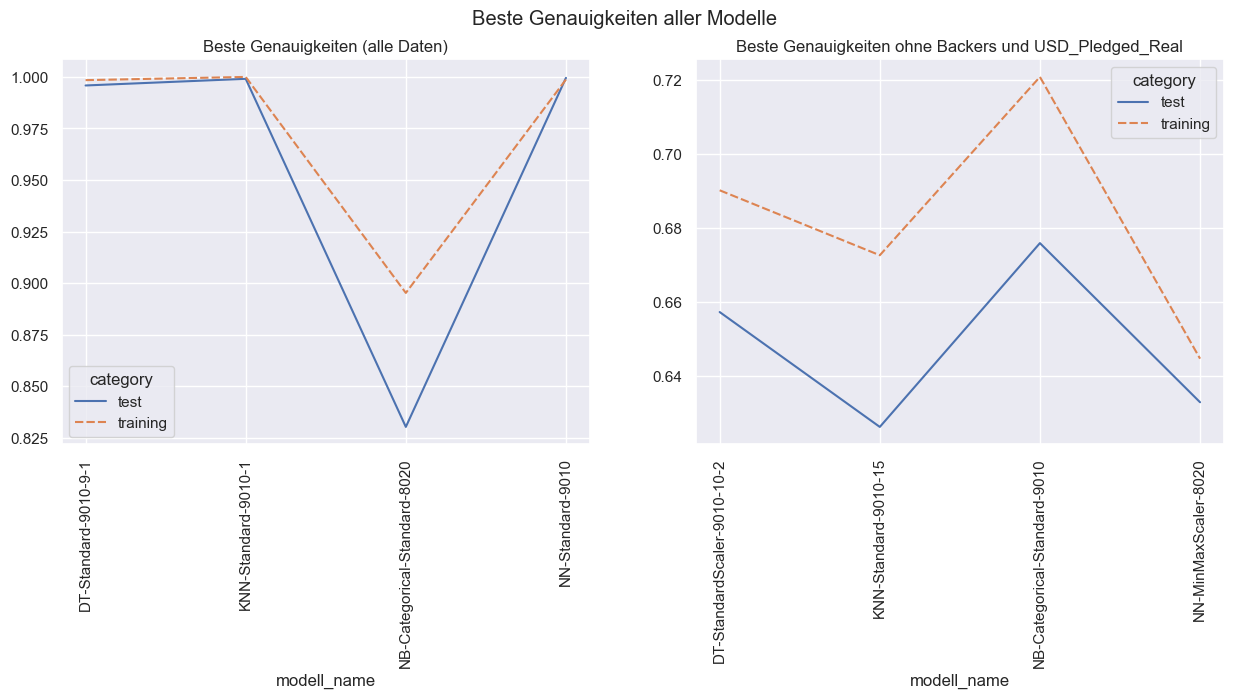

In [114]:
# Plot erzeugen
fig_max_acc, axes_max_acc = plt.subplots(1,2,figsize=(15,5), sharey=False)
fig_max_acc.suptitle("Beste Genauigkeiten aller Modelle")

max_acc = max_acc.reset_index()
max_acc_red = max_acc_red.reset_index()

# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_acc["accuracy"] = pd.to_numeric(max_acc["accuracy"])
max_acc_pivot = max_acc.pivot("modell_name", "category", "accuracy")
scn.lineplot(ax = axes_max_acc[0], data=max_acc_pivot)
axes_max_acc[0].set_title("Beste Genauigkeiten (alle Daten)")

# DataFrame aufbereiten (Datentypen anpassen) und Ergebnis mit höchstem Test-Genauigkeitswert ausgeben
max_acc_red["accuracy"] = pd.to_numeric(max_acc_red["accuracy"])
max_acc_red_pivot = max_acc_red.pivot("modell_name", "category", "accuracy")
scn.lineplot(ax = axes_max_acc[1], data=max_acc_red_pivot)
axes_max_acc[1].set_title("Beste Genauigkeiten ohne Backers und USD_Pledged_Real")

# Plot anpassen
plt.sca(axes_max_acc[0])
plt.xticks(rotation = 90)
plt.sca(axes_max_acc[1])
plt.xticks(rotation = 90)

fig_max_acc
fig_max_acc.savefig("FinalResult")

# Bestes Modell mit Daten ausgeben (alle Daten)
temp = max_acc
temp = temp.loc[temp["category"] == "test"]
temp_max_id = temp["accuracy"].idxmax()
temp_max_id_train = temp_max_id + 1
temp_result = max_acc.iloc[temp_max_id]
temp_result_train = max_acc.iloc[temp_max_id_train]
display("Bestes Modell (alle Daten):")
display(str(temp_result["modell_name"]))
display("Genauigkeit der Testdaten: " + str(temp_result["accuracy"]))
display("Genauigkeit der Trainingsdaten: " + str(temp_result_train["accuracy"]) + "\n")

# Bestes Modell mit Daten ausgeben ohne Backers und USD_Pledged_Real
temp = max_acc_red
temp = temp.loc[temp["category"] == "test"]
temp_max_id = temp["accuracy"].idxmax()
temp_max_id_train = temp_max_id + 1
temp_result = max_acc_red.iloc[temp_max_id]
temp_result_train = max_acc_red.iloc[temp_max_id_train]
display("Bestes Modell ohne Backers und USD_Pledged_Real:")
display(str(temp_result["modell_name"]))
display("Genauigkeit der Testdaten: " + str(temp_result["accuracy"]))
display("Genauigkeit der Trainingsdaten: " + str(temp_result_train["accuracy"]))